# Template 07: SHAP Analysis

**Purpose:** Generate residual + SHAP range plots for top features

**Inputs:**
- results/06_shap_train.parquet
- results/06_shap_test.parquet
- results/05_predictions_train.parquet
- results/05_predictions_test.parquet
- data/04_train.parquet
- data/04_test.parquet

**Outputs:**
- plots/{dataset}_{feature}_residual.png
- plots/{dataset}_{feature}_shap_range.png
- results/07_analysis_summary.yaml

In [1]:
config_path = "config/car_coll/v1"

In [2]:
# Parameters
config_path = "config/car_coll/v1"


In [3]:
import pandas as pd
import numpy as np
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import yaml
import os
import sys
from pathlib import Path
from datetime import datetime

sys.path.insert(0, str(Path.cwd() / 'lib'))
from utils import setup_notebook_environment
from shap_utils import compute_shap_aggregate, create_residual_plot, create_shap_range_plot

print("########################################")
print("# STAGE 07: SHAP ANALYSIS")
print("########################################")

project_root = setup_notebook_environment()

########################################
# STAGE 07: SHAP ANALYSIS
########################################


In [4]:
with open(f"{config_path}/config.yaml") as f:
    cfg = yaml.safe_load(f)
output_base = cfg["paths"]["output_base"]
shap_cfg = cfg.get("shap_analysis", {})
top_n = shap_cfg.get("top_n_features", 40)
datasets = shap_cfg.get("datasets", ["train", "test"])
resid_cfg = shap_cfg.get("residual_plot", {})
shap_range_cfg = shap_cfg.get("shap_range_plot", {})
print(f"\nConfig: top_n={top_n}")


Config: top_n=40


In [5]:
plots_dir = f"{output_base}/plots"
os.makedirs(plots_dir, exist_ok=True)
print(f"Plots: {plots_dir}")

Plots: output/car_coll/v1/plots


In [6]:
print("\nLoading...")
shap_train = pd.read_parquet(f"{output_base}/results/06_shap_train.parquet")
shap_test = pd.read_parquet(f"{output_base}/results/06_shap_test.parquet")
preds_train = pd.read_parquet(f"{output_base}/results/05_predictions_train.parquet")
preds_test = pd.read_parquet(f"{output_base}/results/05_predictions_test.parquet")
df_train = pd.read_parquet(f"{output_base}/data/04_train.parquet")
df_test = pd.read_parquet(f"{output_base}/data/04_test.parquet")
print(f"SHAP: {shap_train.shape}, {shap_test.shape}")
print(f"Preds: {preds_train.shape}, {preds_test.shape}")


Loading...


SHAP: (10000, 91), (3750266, 91)
Preds: (3757142, 3), (3750266, 3)


In [7]:
# Merge train data with predictions
data_tr = df_train.loc[shap_train.index].copy()
data_tr['actual'] = preds_train.loc[shap_train.index, 'actual']
data_tr['pred'] = preds_train.loc[shap_train.index, 'pred']
data_tr['weight'] = preds_train.loc[shap_train.index, 'exposure']

fc_tr = shap_train.copy()
fc_tr['weight'] = data_tr['weight']
out_tr = data_tr
print(f"Train: {out_tr.shape}")

Train: (10000, 125)


In [8]:
# Merge test data with predictions
data_te = df_test.loc[shap_test.index].copy()
data_te['actual'] = preds_test.loc[shap_test.index, 'actual']
data_te['pred'] = preds_test.loc[shap_test.index, 'pred']
data_te['weight'] = preds_test.loc[shap_test.index, 'exposure']

fc_te = shap_test.copy()
fc_te['weight'] = data_te['weight']
out_te = data_te
print(f"Test: {out_te.shape}")

Test: (3750266, 125)


In [9]:
print("\nSHAP aggregates...")
shagg, shagg_num, shagg2 = compute_shap_aggregate(fc_tr, weight_col="weight")
print(f"Features: {len(shagg2)}")
print(shagg2.head(10))


SHAP aggregates...
Features: 87
                               field   total_shap
41                     vc_camera_raw  1553.825321
8              multi_pol_unknown_cal  1386.756893
7                        married_ind   672.345204
89               cef_lien_holder_ind   644.590789
87           cef_first_poten_dam_ind   520.855768
18               vc_seating_rows_raw   482.398070
48  vc_electronic_braking_system_raw   471.557153
9                  multi_pol_yes_cal   447.186868
70                 vc_rear_wiper_raw   318.662070
74     vc_speed_sensitive_volume_raw   256.893316


In [10]:
features = shagg2["field"].head(top_n).tolist()
print(f"\nPlotting {len(features)} features")


Plotting 40 features


In [11]:
summary = {"timestamp": datetime.now().isoformat(), "plots": 0}
plots_by_feature = {}

In [12]:
print("="*60)
print("GENERATING PLOTS")
print("="*60)
for i, f in enumerate(features, 1):
    print(f"[{i}/{len(features)}] {f}")
    plots_by_feature[f] = []
    if f not in out_tr.columns or f not in out_te.columns:
        print(f"  WARNING: Feature {f} not found, skipping")
        continue
    if "train" in datasets:
        try:
            fig, _ = create_residual_plot(out_tr, f, "weight", dataset_label="Train", **resid_cfg)
            path = f"{plots_dir}/train_{f}_residual.png"
            fig.savefig(path, dpi=100, bbox_inches="tight")
            plt.close(fig)
            plots_by_feature[f].append(path)
            summary["plots"] += 1
        except Exception as e:
            print(f"  ERROR (Train Residual): {e}")
        try:
            fig, _ = create_shap_range_plot(fc_tr, data_tr, f, "weight", dataset_label="Train", **shap_range_cfg)
            path = f"{plots_dir}/train_{f}_shap_range.png"
            fig.savefig(path, dpi=100, bbox_inches="tight")
            plt.close(fig)
            plots_by_feature[f].append(path)
            summary["plots"] += 1
        except Exception as e:
            print(f"  ERROR (Train SHAP): {e}")
    if "test" in datasets:
        try:
            fig, _ = create_residual_plot(out_te, f, "weight", dataset_label="Test", **resid_cfg)
            path = f"{plots_dir}/test_{f}_residual.png"
            fig.savefig(path, dpi=100, bbox_inches="tight")
            plt.close(fig)
            plots_by_feature[f].append(path)
            summary["plots"] += 1
        except Exception as e:
            print(f"  ERROR (Test Residual): {e}")
        try:
            fig, _ = create_shap_range_plot(fc_te, data_te, f, "weight", dataset_label="Test", **shap_range_cfg)
            path = f"{plots_dir}/test_{f}_shap_range.png"
            fig.savefig(path, dpi=100, bbox_inches="tight")
            plt.close(fig)
            plots_by_feature[f].append(path)
            summary["plots"] += 1
        except Exception as e:
            print(f"  ERROR (Test SHAP): {e}")
print(f"\n[OK] Generated summary")

GENERATING PLOTS
[1/40] vc_camera_raw

vc_camera_raw Summary:
 vc_camera_raw      weight   act_rate  pred_rate
             0 1727.252983 174.343850 260.039481
             3  479.282731 237.233969 427.464155
             5 2452.482611 555.351108 560.682569


/Users/Mach/dev/aps/code/26Dmodelv1/lib/shap_utils.py:155: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  c['SHAP'].fillna(lowest_contrib, inplace=True)
/Users/Mach/dev/aps/code/26Dmodelv1/lib/shap_utils.py:155: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace 


vc_camera_raw Summary:
 vc_camera_raw        weight   act_rate  pred_rate
             0 622227.245804 322.250468 264.268724
             3 183808.579362 519.278953 426.895721
             5 924792.775627 637.613625 568.849530


/Users/Mach/dev/aps/code/26Dmodelv1/lib/shap_utils.py:155: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  c['SHAP'].fillna(lowest_contrib, inplace=True)
/Users/Mach/dev/aps/code/26Dmodelv1/lib/shap_utils.py:155: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace 

[2/40] multi_pol_unknown_cal

multi_pol_unknown_cal Summary:
 multi_pol_unknown_cal      weight   act_rate  pred_rate
                     0 3644.406176 355.550625 342.969455
                     1 1014.612149 474.128089 767.952871


...

[40/40] vc_doors_raw

vc_doors_raw Summary:
 vc_doors_raw      weight   act_rate  pred_rate
          2.0  464.186331 410.816209 392.178145
          3.0   29.550655 113.052316 339.837143
          4.0 3697.294041 384.172322 445.676718
          5.0  467.987297 347.002877 404.306514


/Users/Mach/dev/aps/code/26Dmodelv1/lib/shap_utils.py:155: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  c['SHAP'].fillna(lowest_contrib, inplace=True)
/Users/Mach/dev/aps/code/26Dmodelv1/lib/shap_utils.py:155: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace 


vc_doors_raw Summary:
 vc_doors_raw       weight   act_rate  pred_rate
          2.0 1.628571e+05 499.905081 402.720651
          3.0 9.264770e+03 538.670761 397.753101
          4.0 1.390263e+06 515.699077 452.410441
          5.0 1.678089e+05 487.066125 419.995460
          6.0 6.352196e+02 828.834394 394.997328


/Users/Mach/dev/aps/code/26Dmodelv1/lib/shap_utils.py:155: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  c['SHAP'].fillna(lowest_contrib, inplace=True)
/Users/Mach/dev/aps/code/26Dmodelv1/lib/shap_utils.py:155: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace 


[OK] Generated summary



DISPLAYING ALL PLOTS

FEATURE: vc_camera_raw


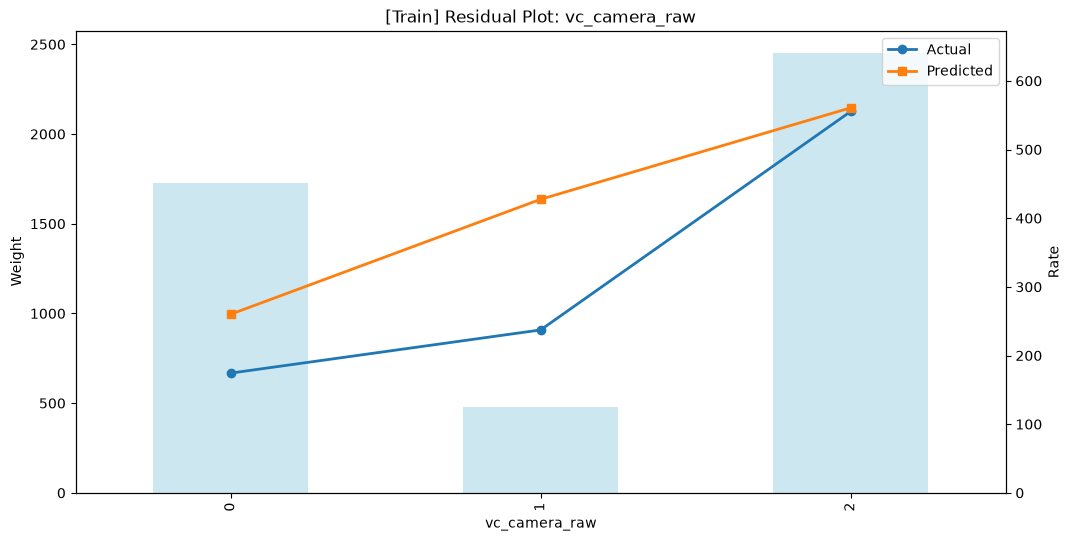

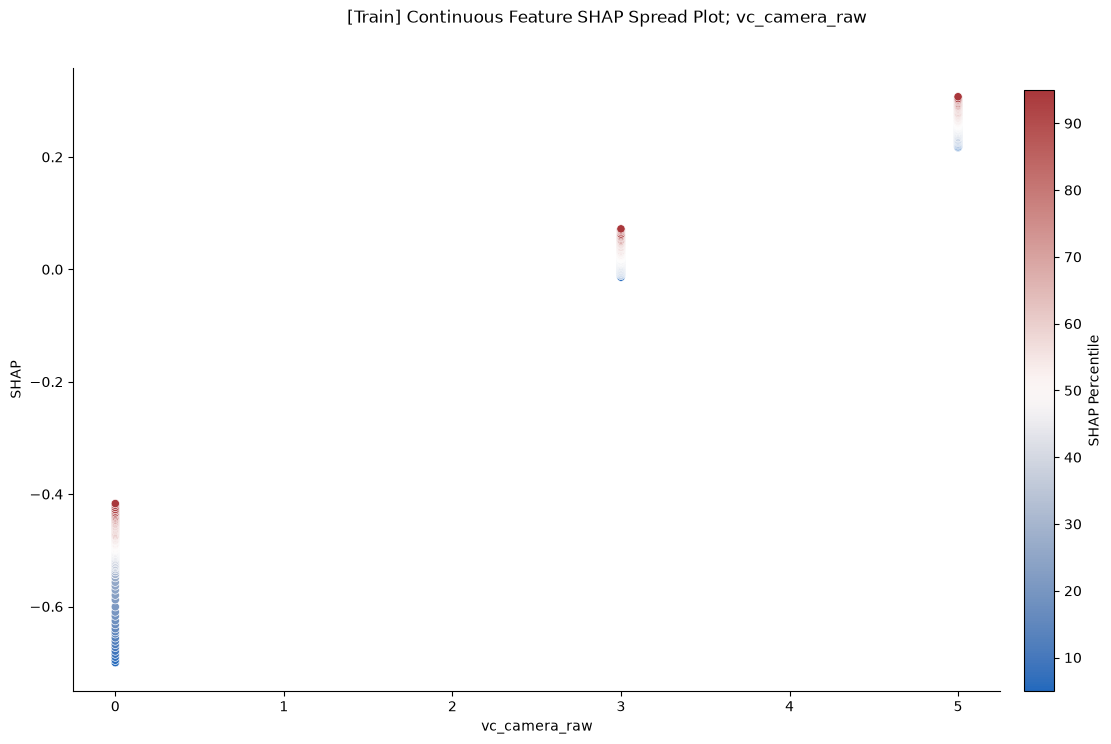

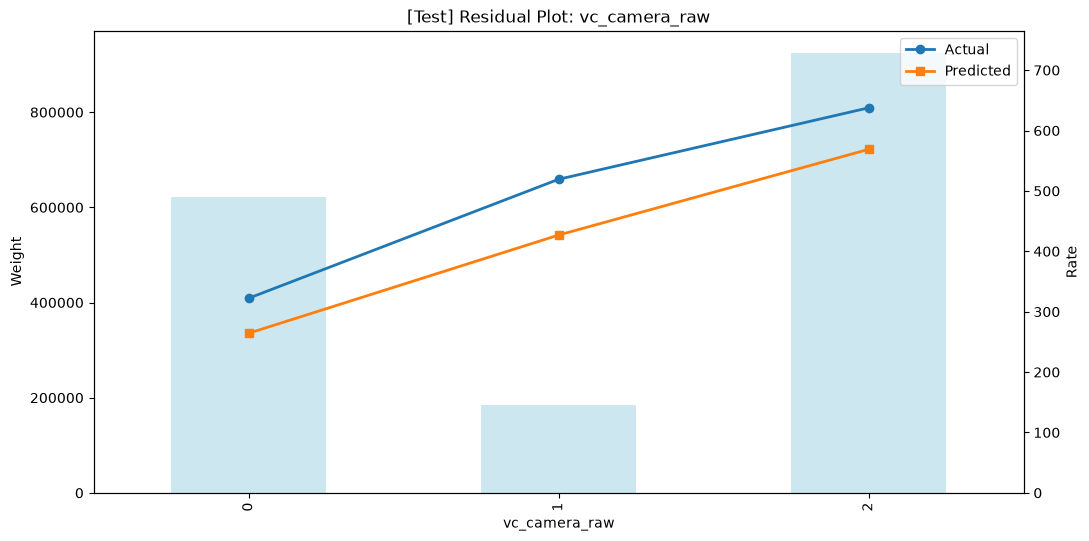

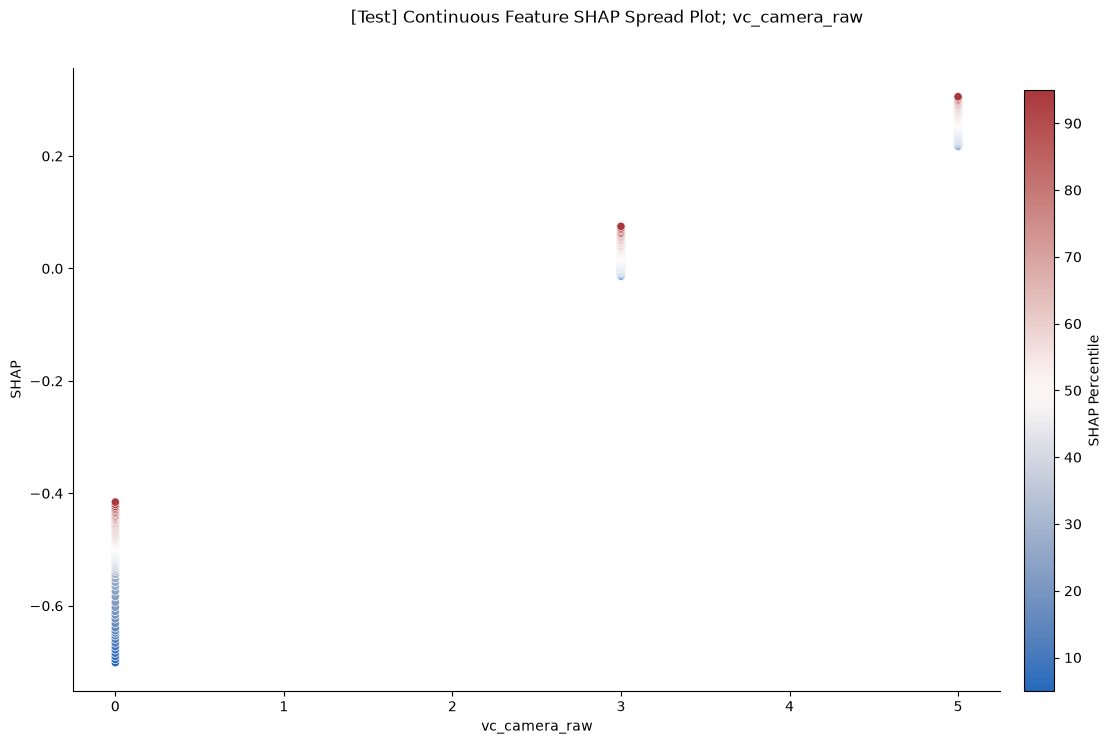


FEATURE: multi_pol_unknown_cal


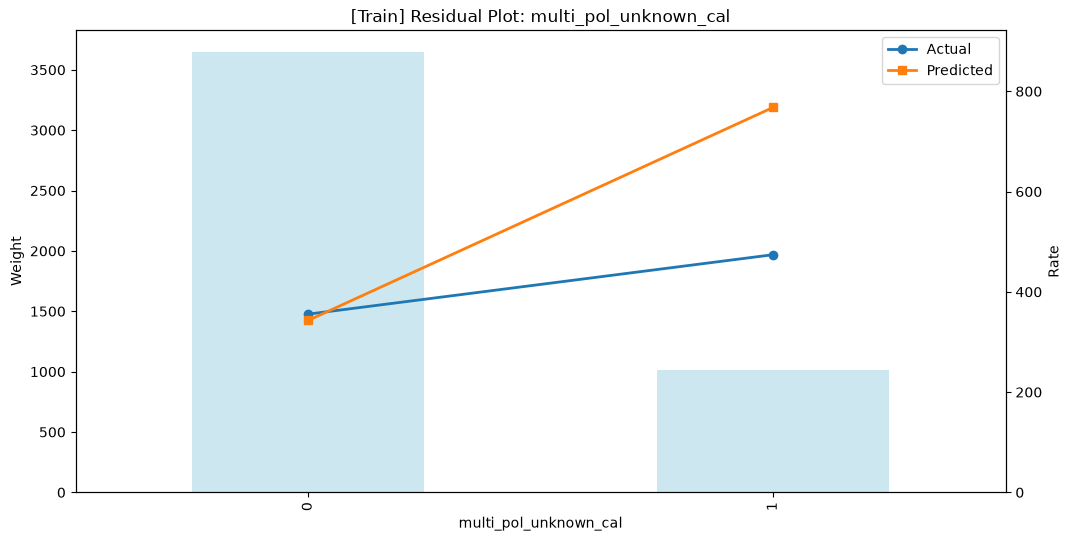

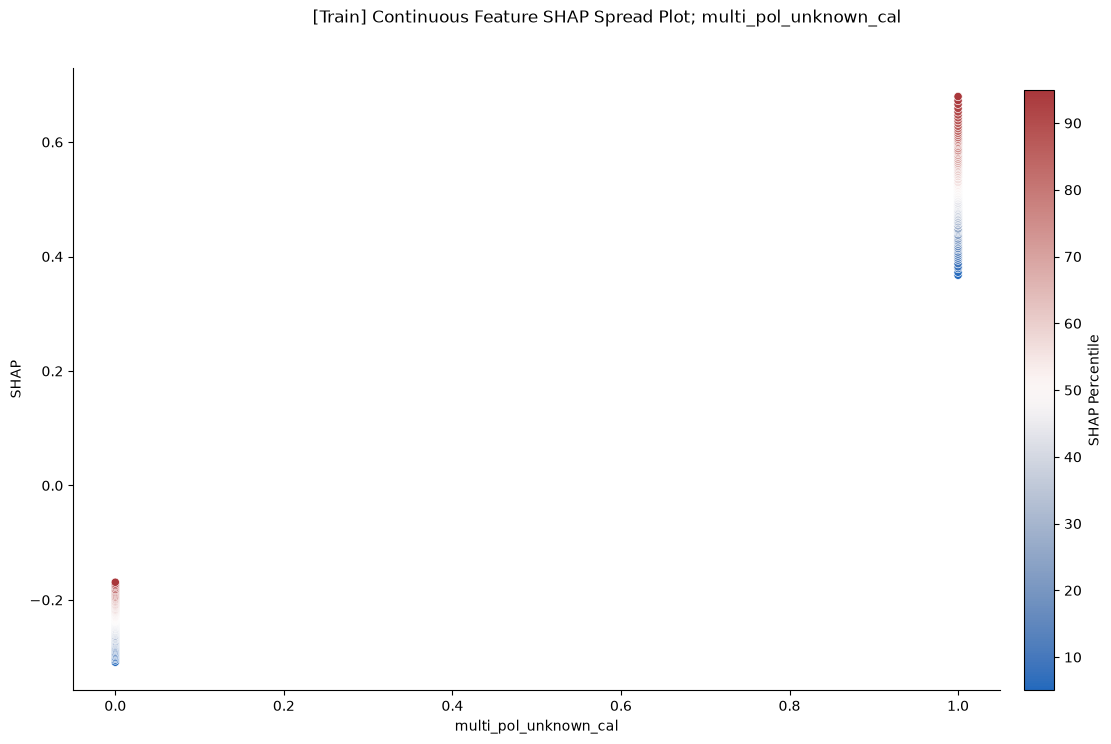

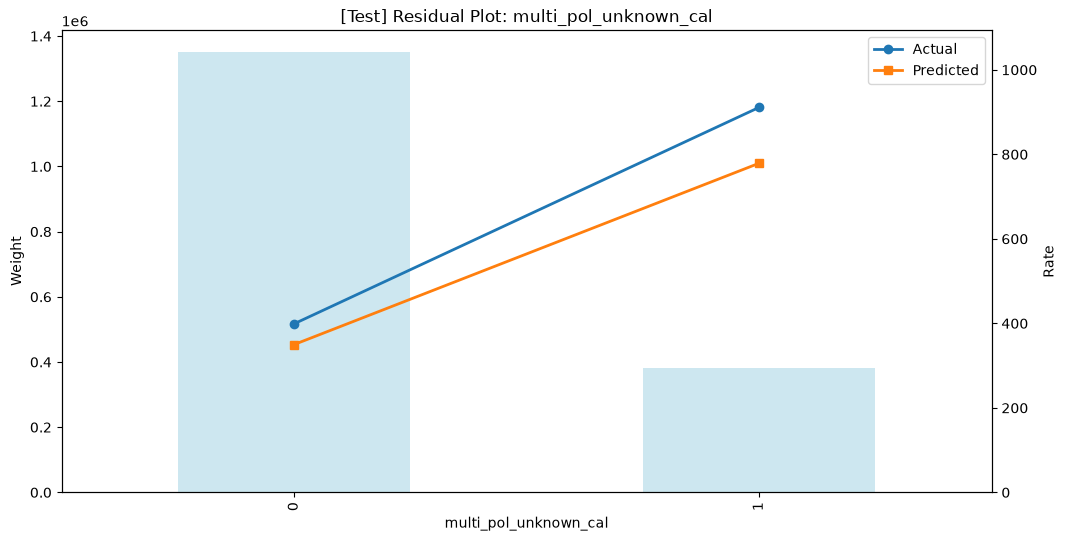

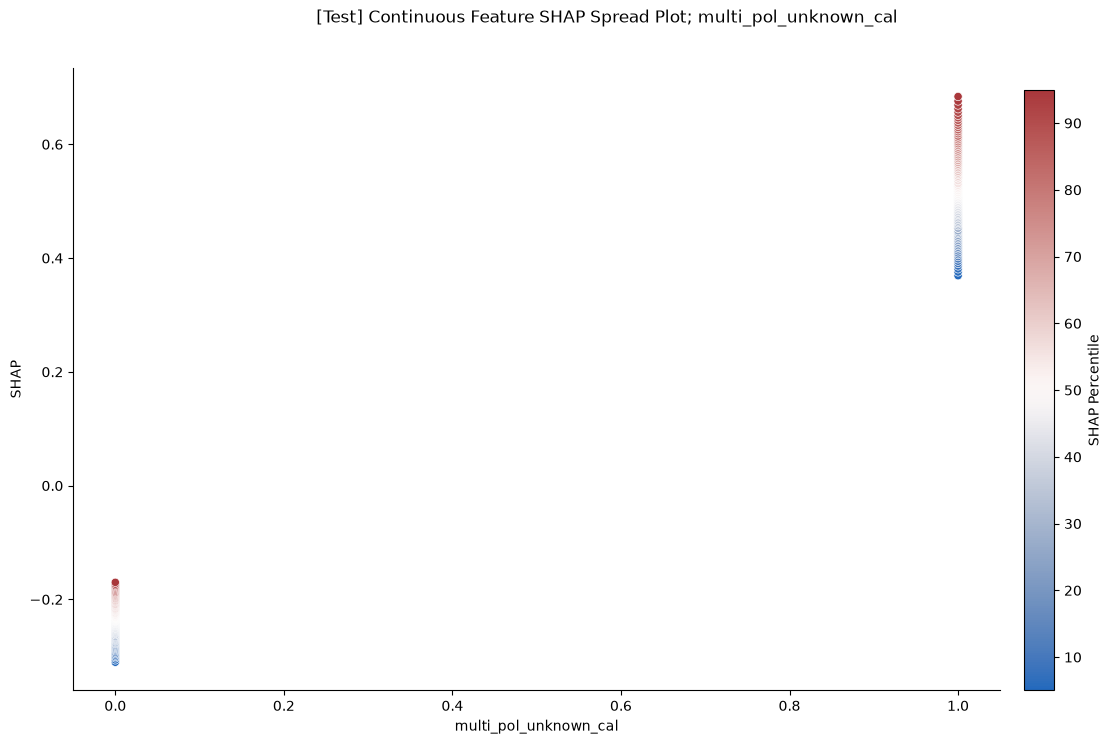


FEATURE: married_ind


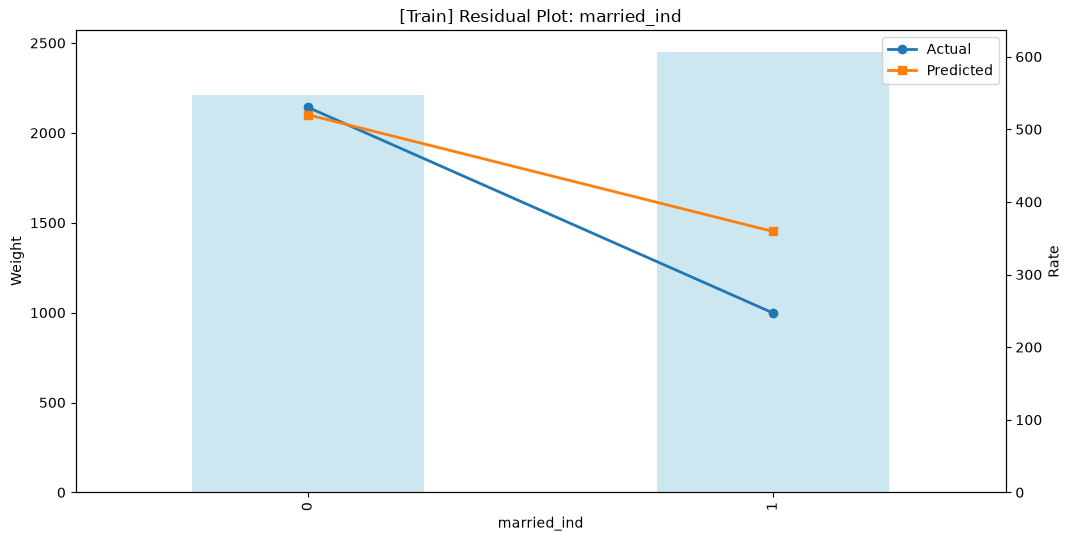

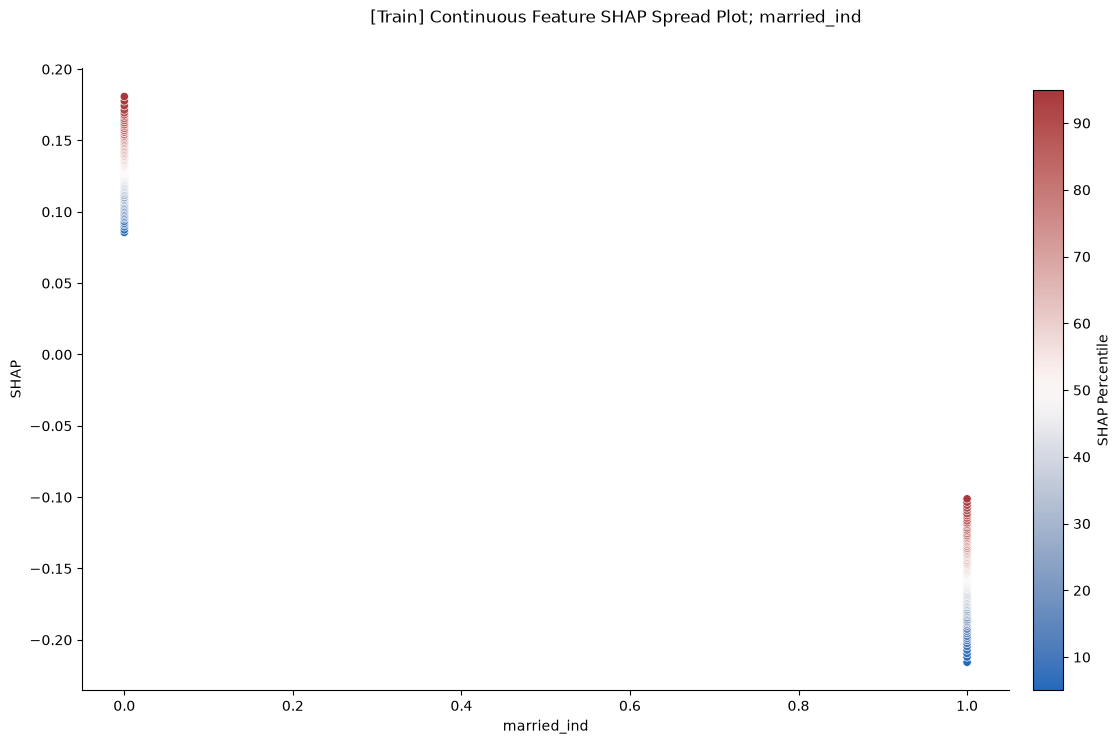

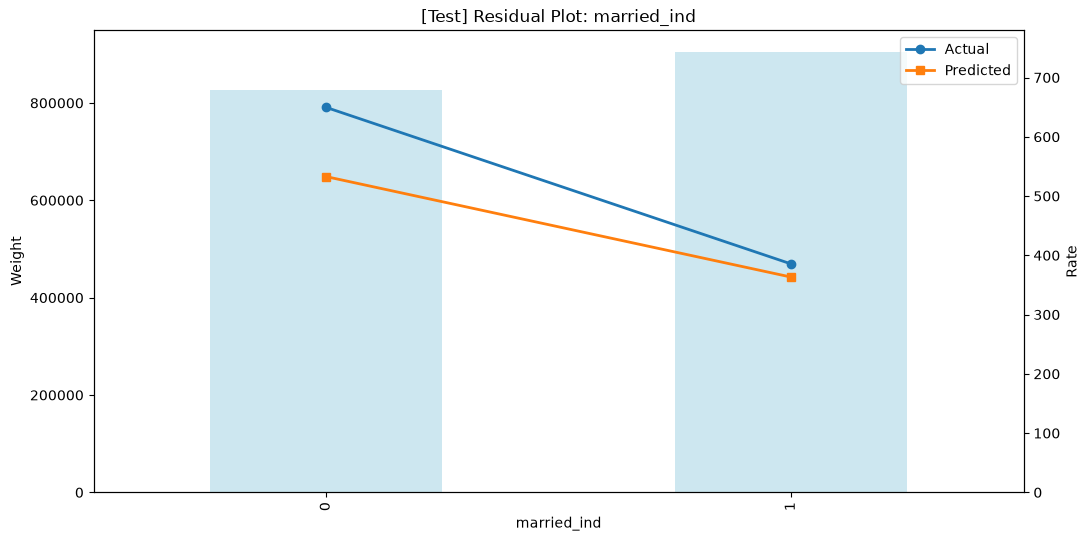

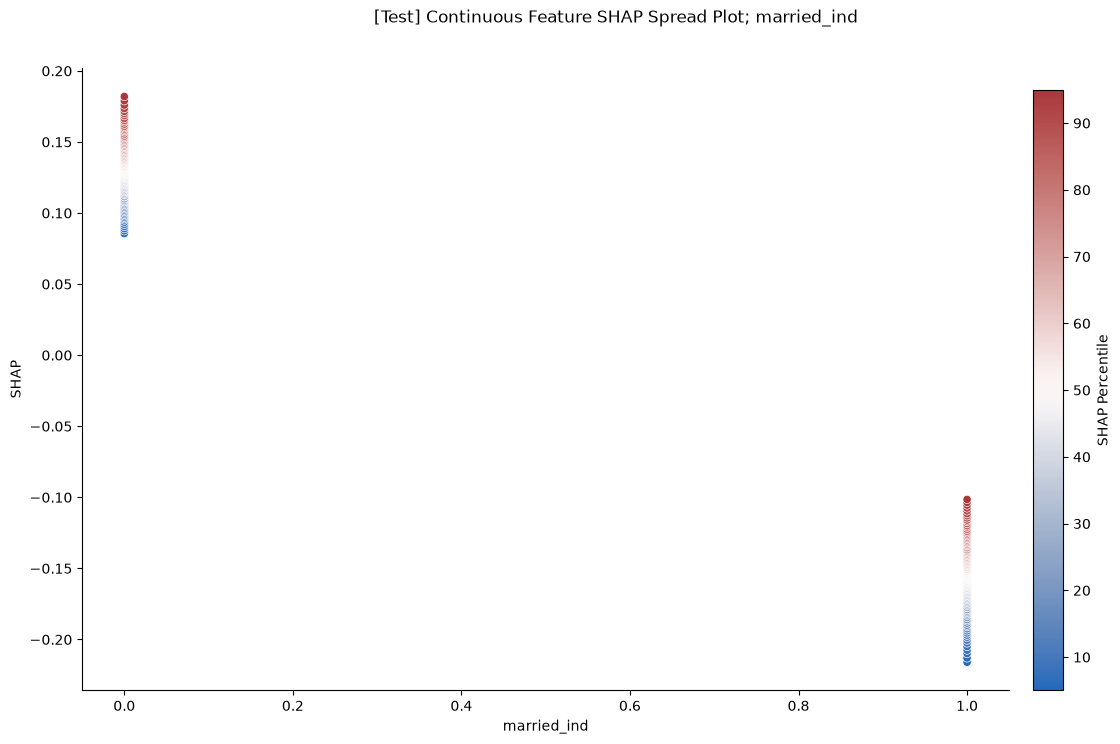


FEATURE: cef_lien_holder_ind


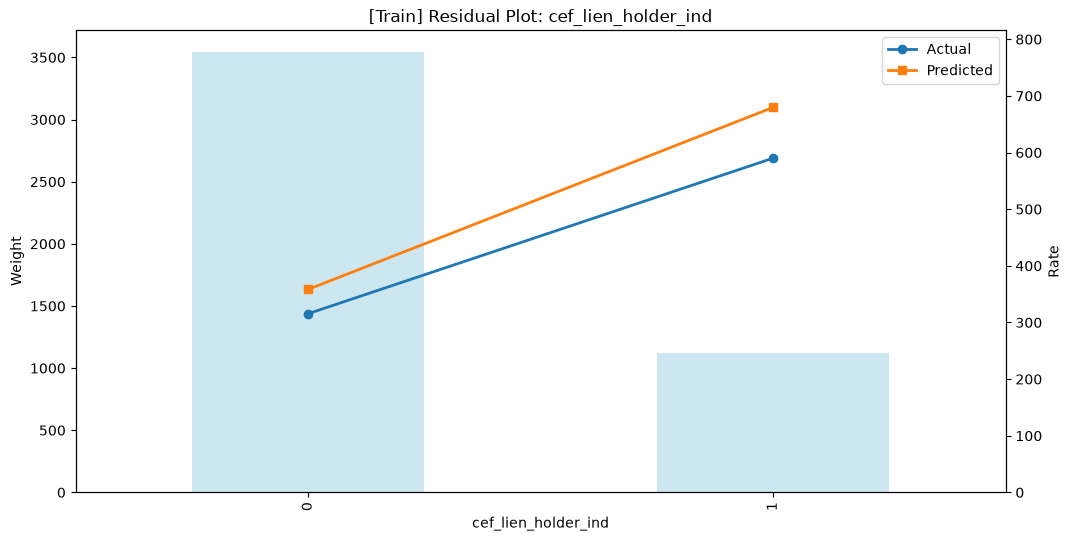

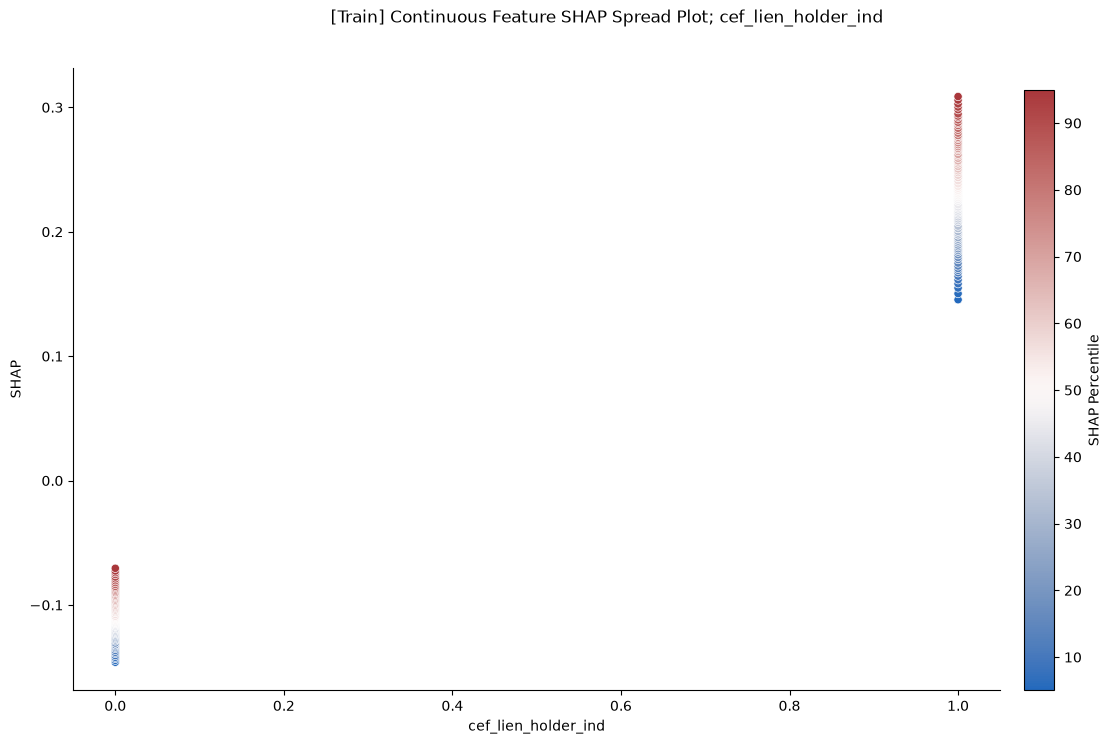

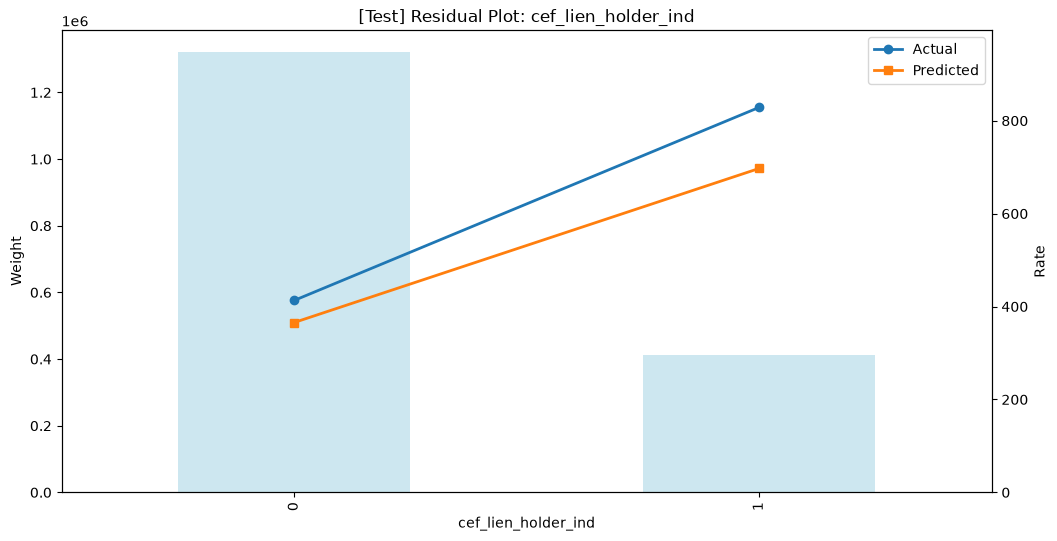

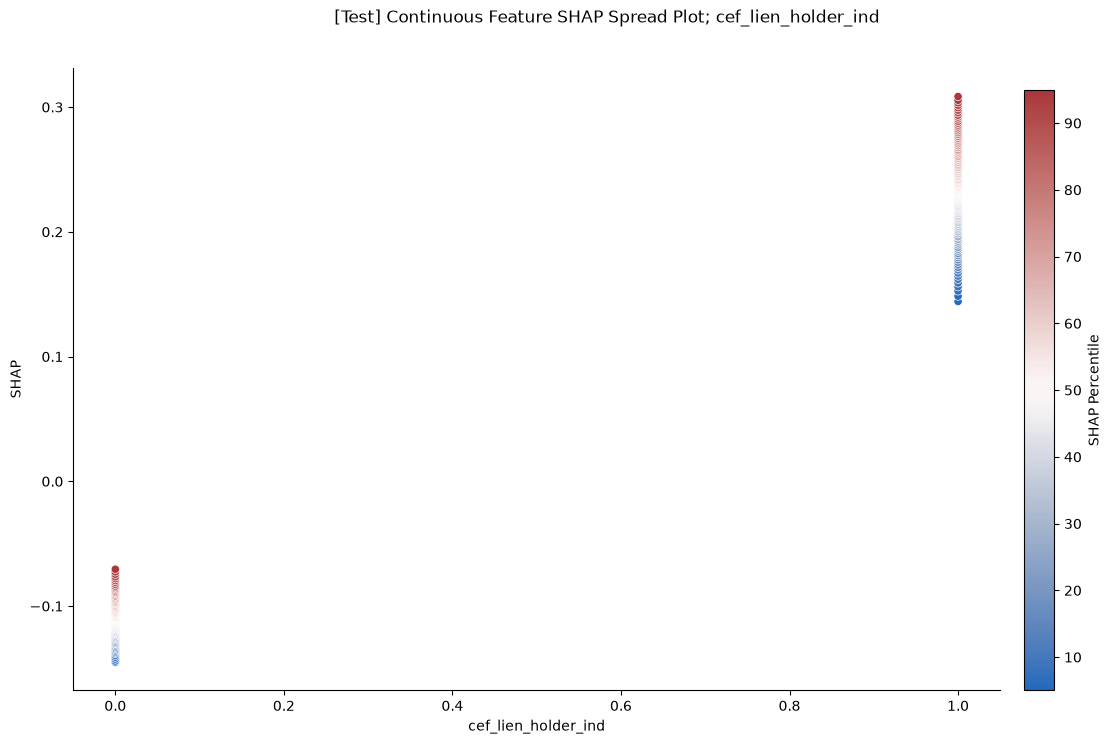


FEATURE: cef_first_poten_dam_ind


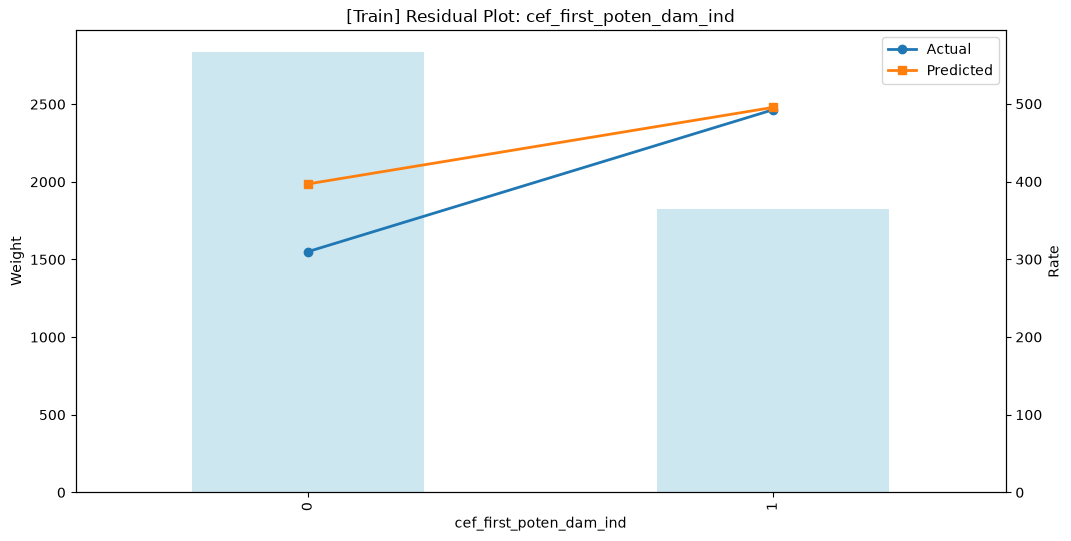

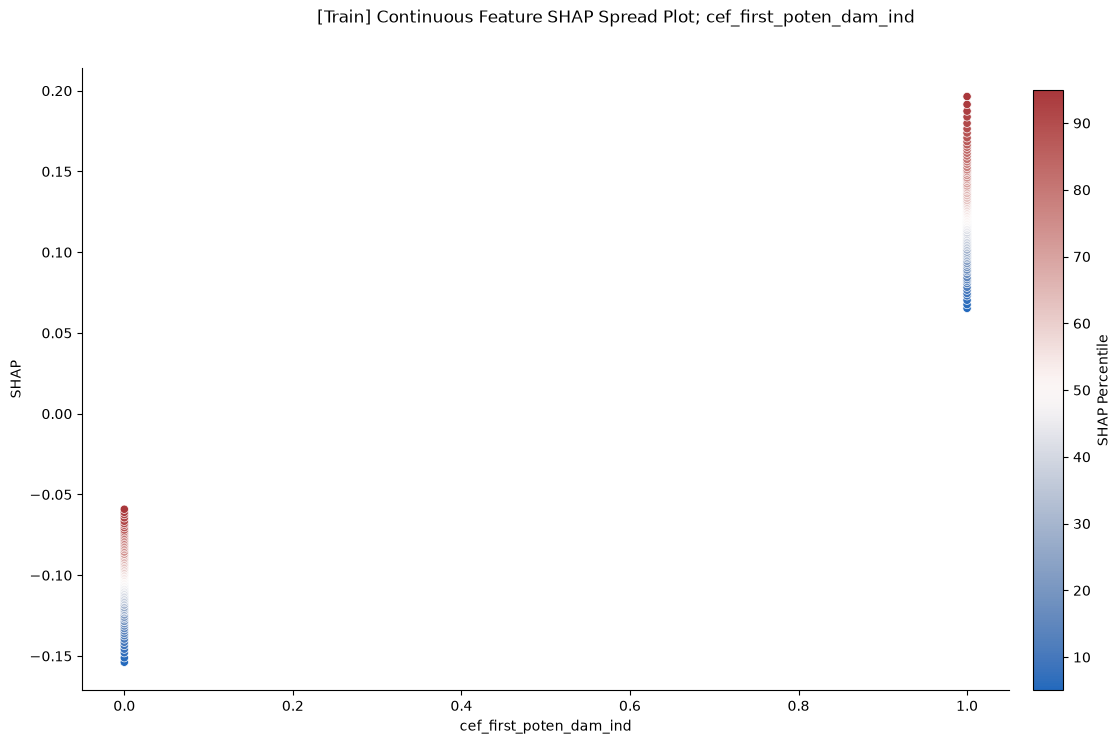

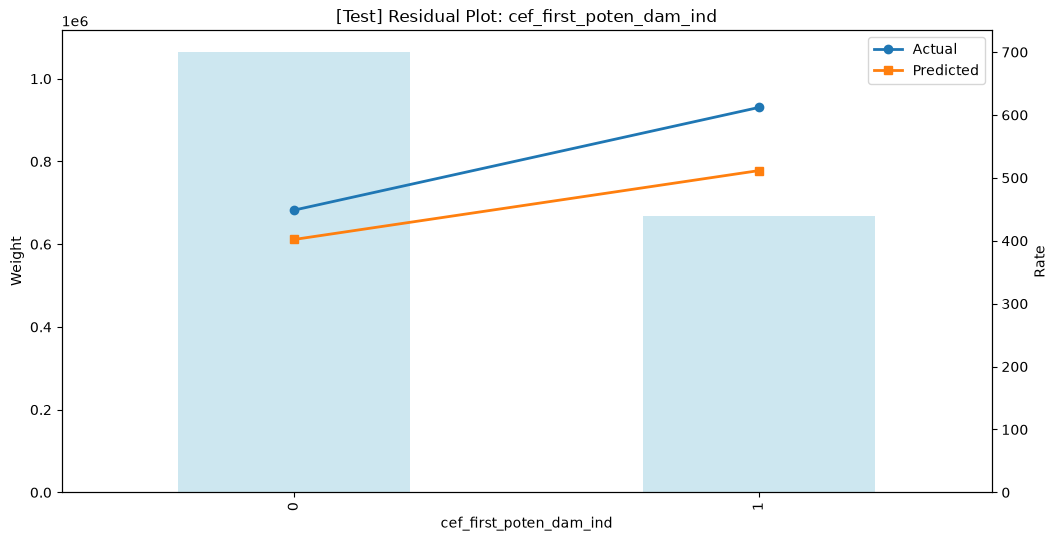

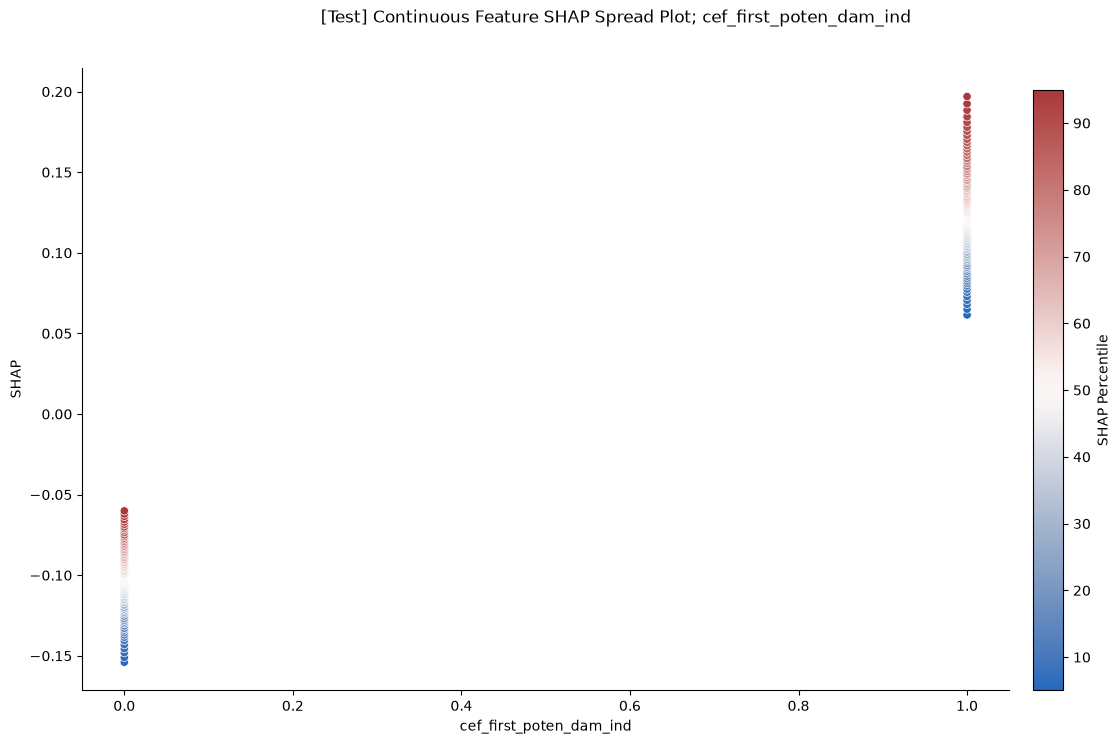


FEATURE: vc_seating_rows_raw


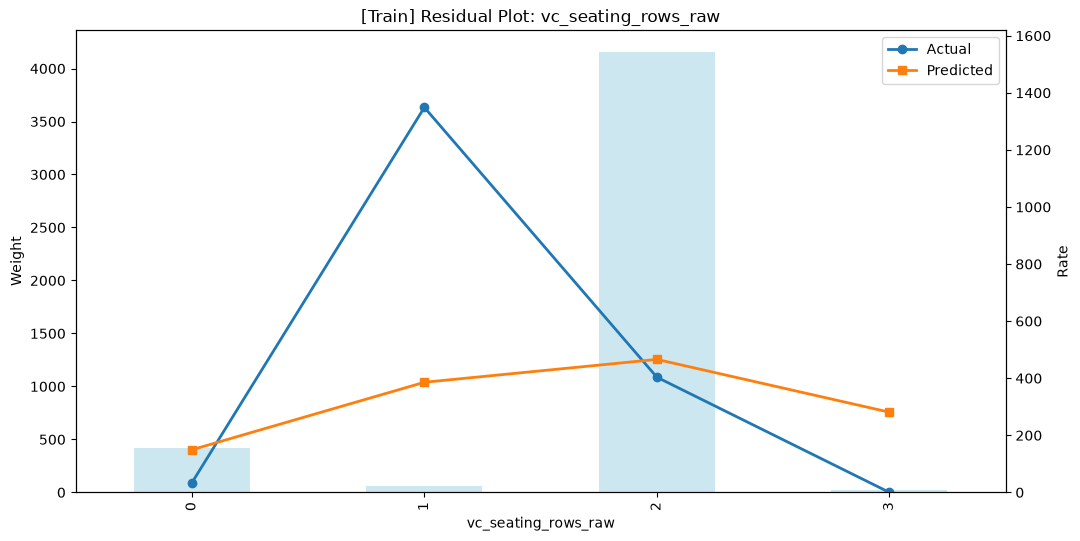

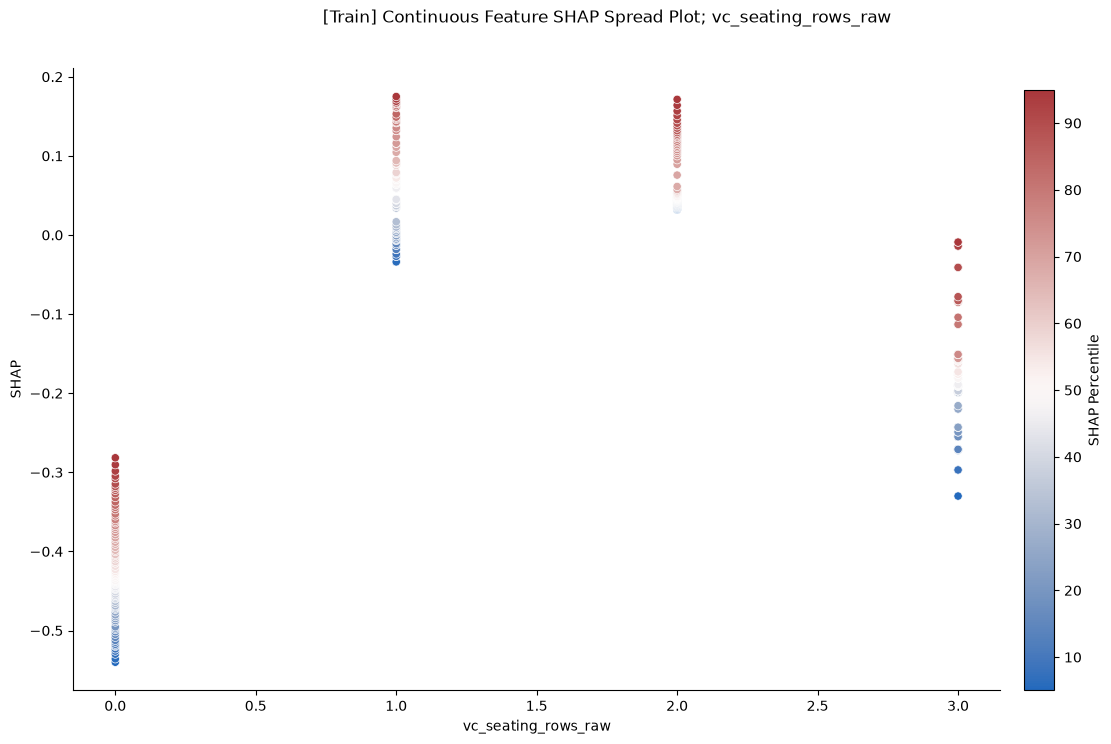

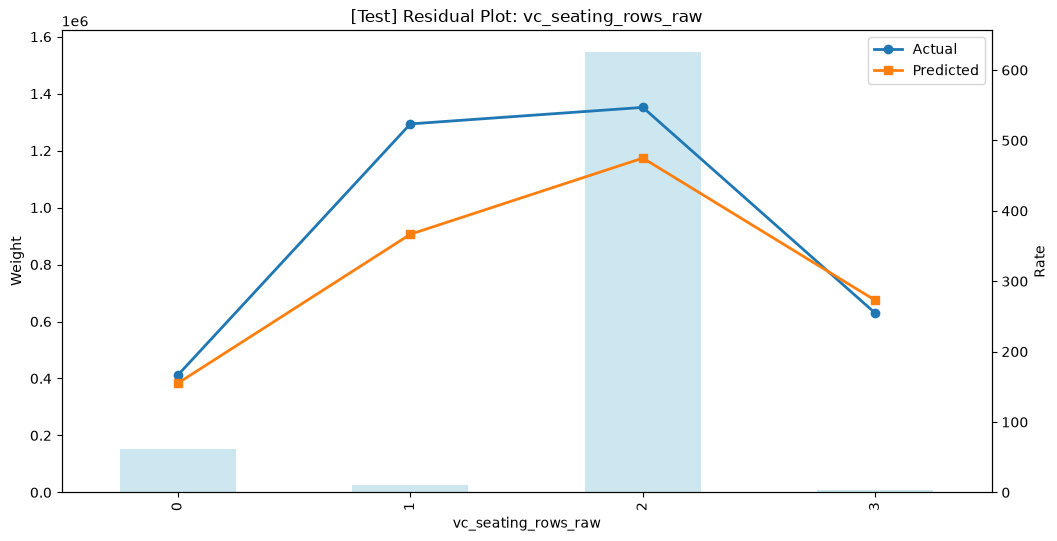

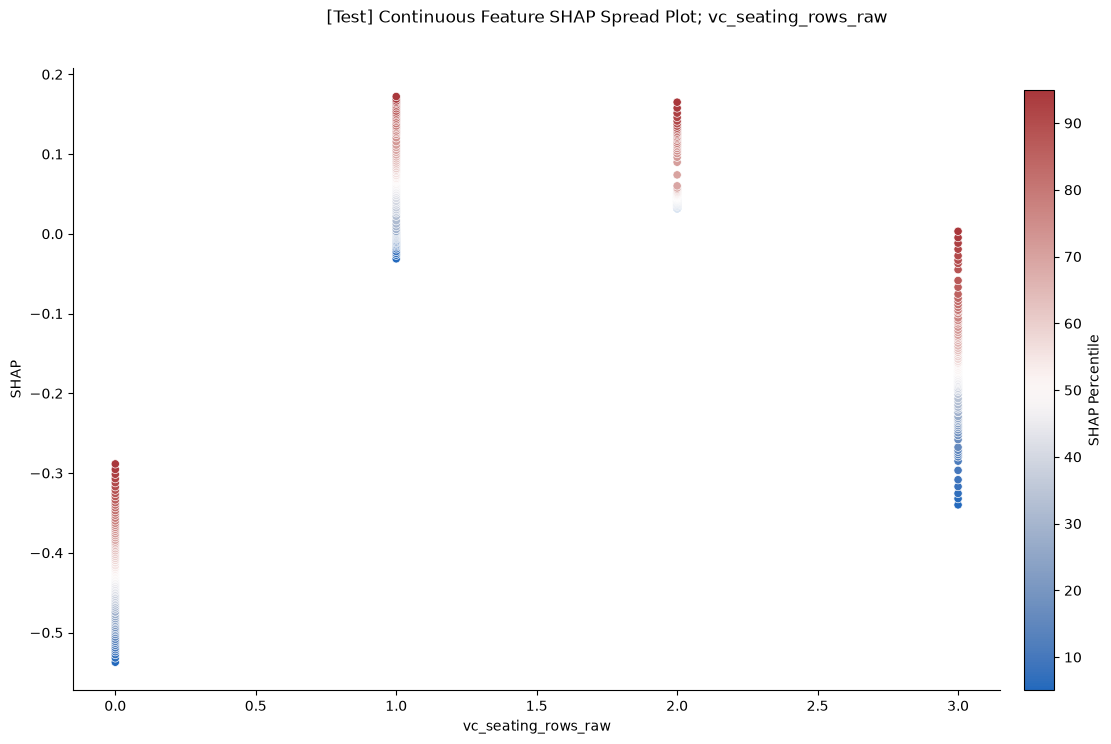


FEATURE: vc_electronic_braking_system_raw


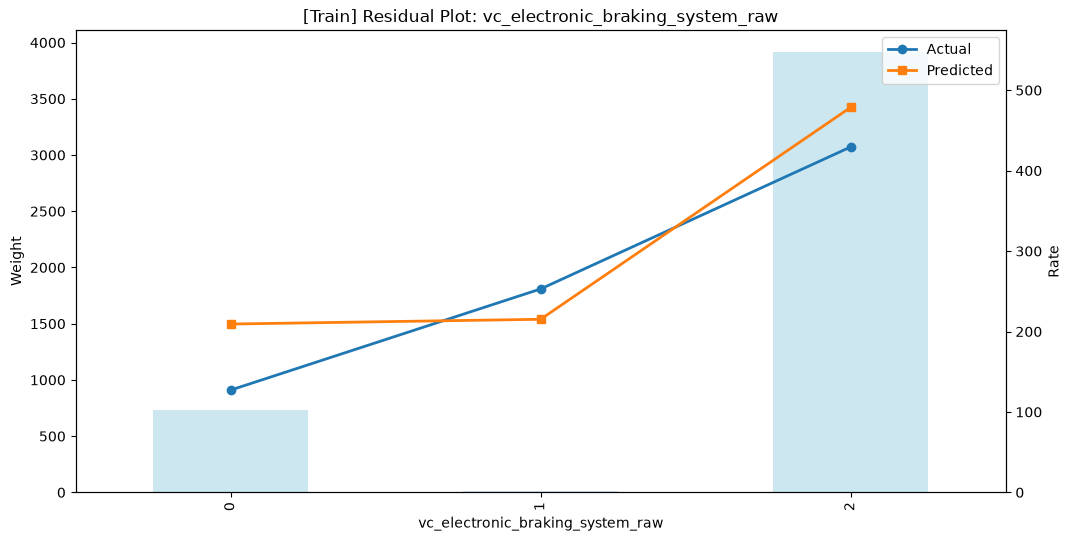

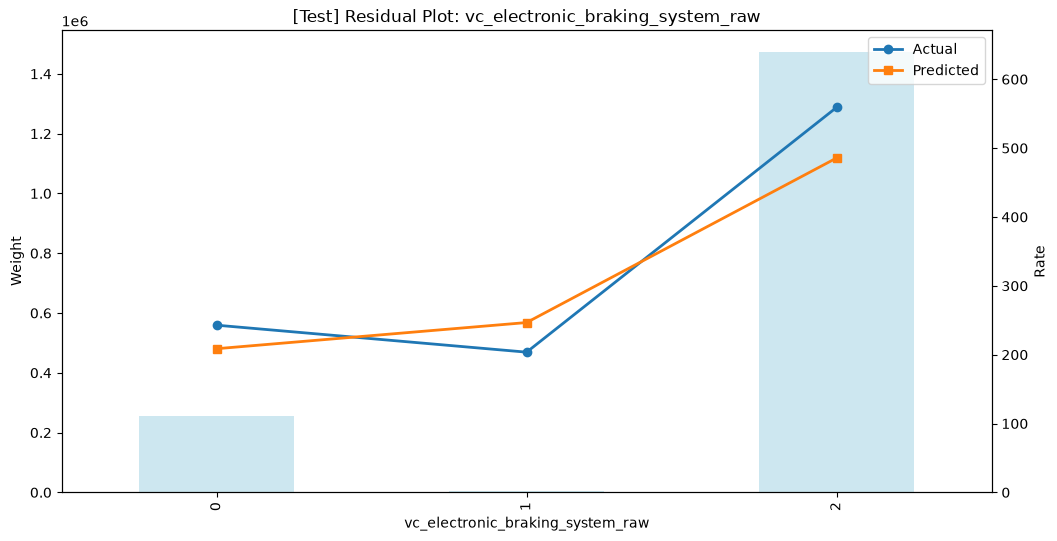

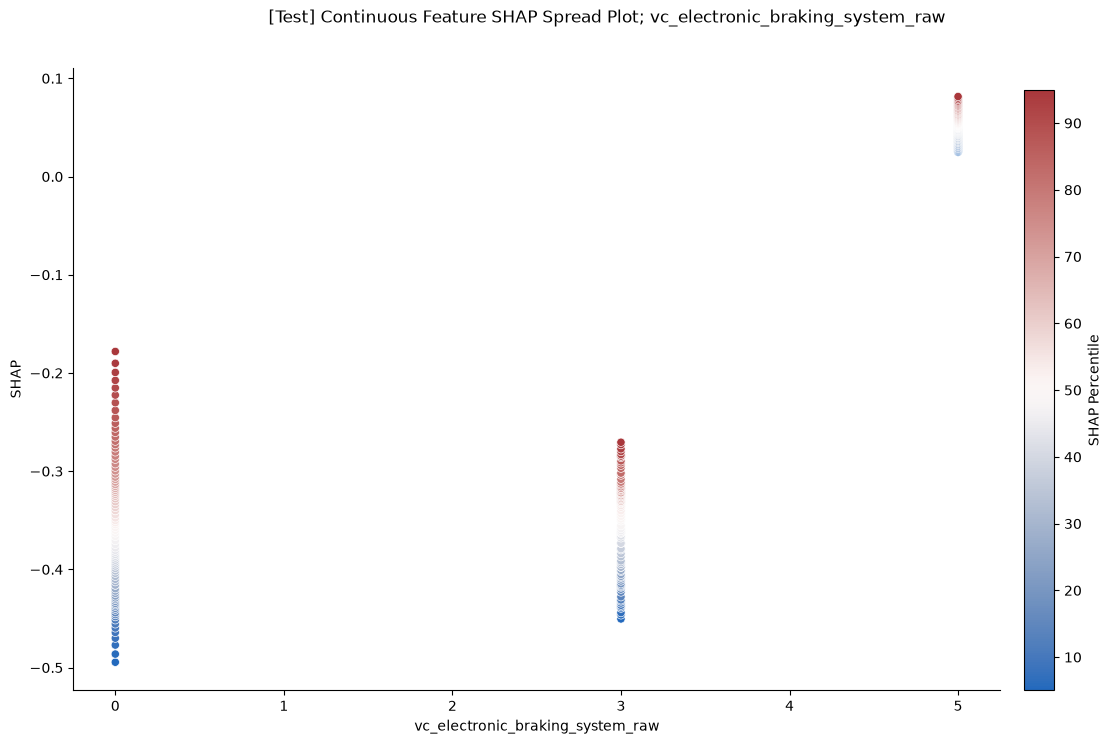


FEATURE: multi_pol_yes_cal


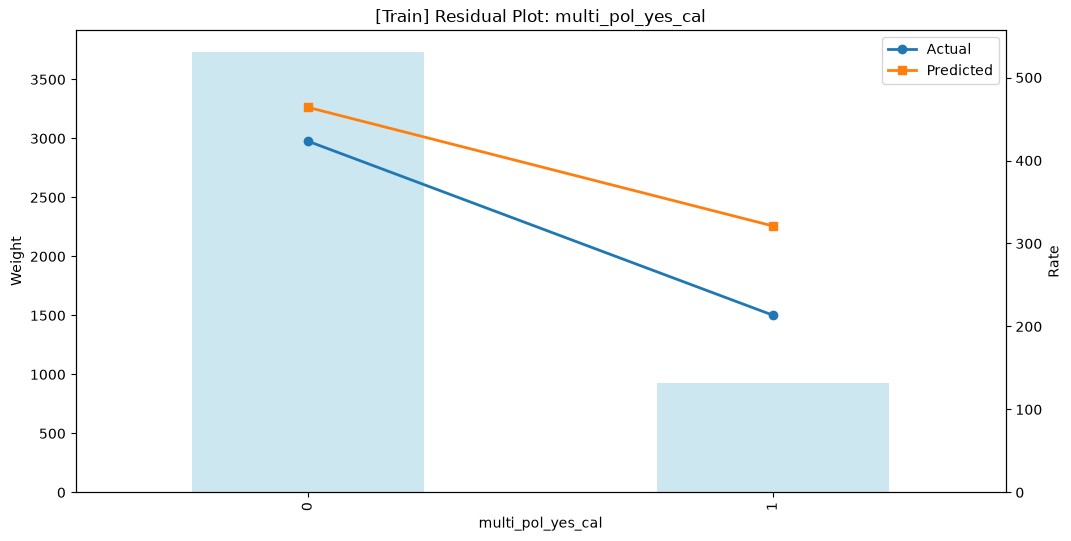

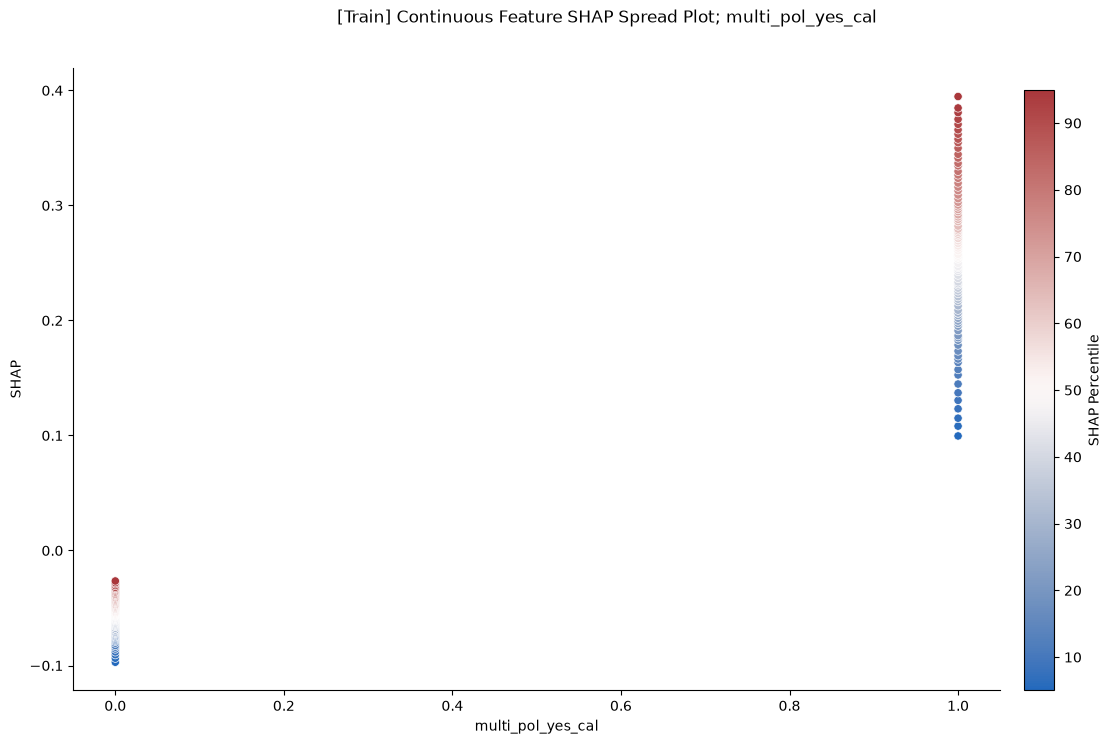

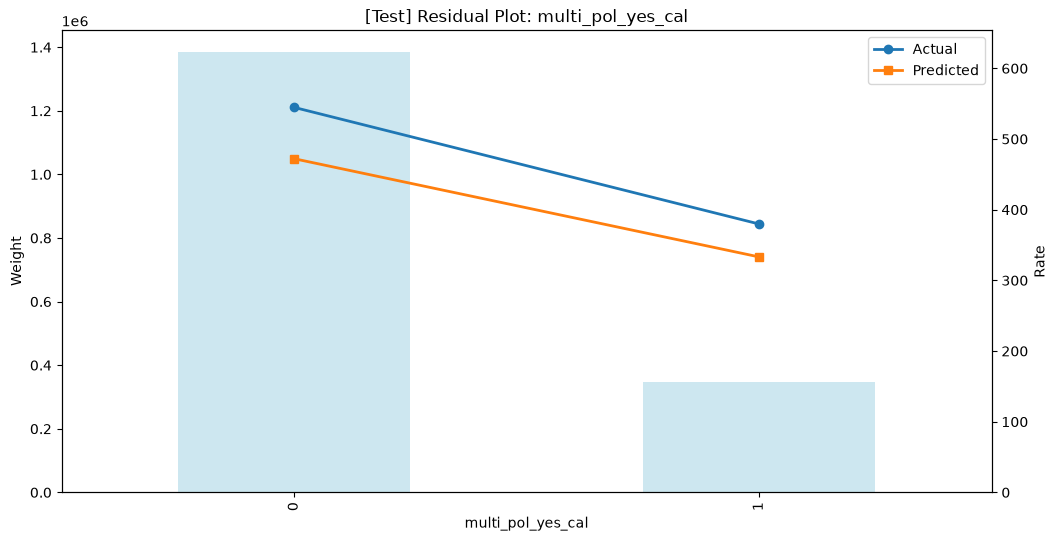

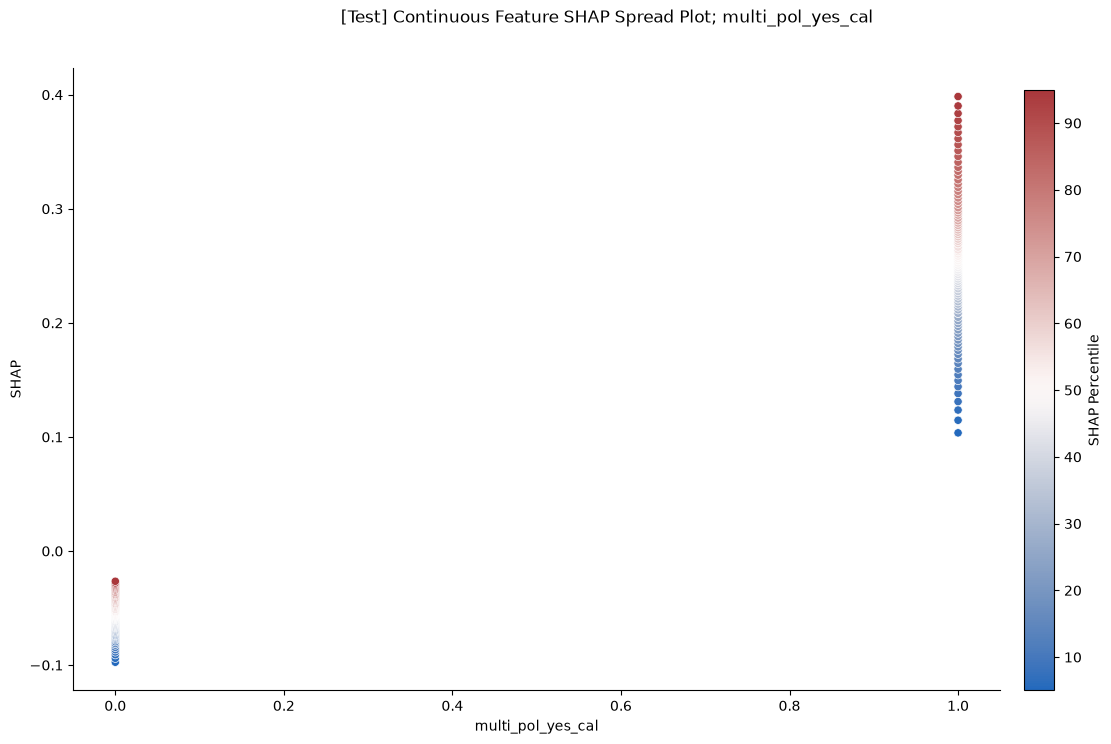


FEATURE: vc_rear_wiper_raw


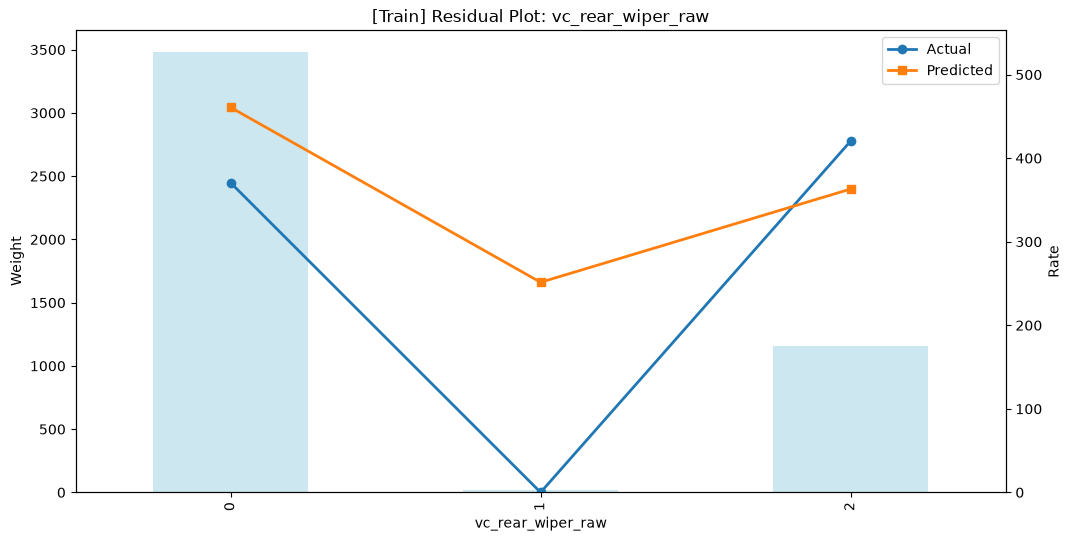

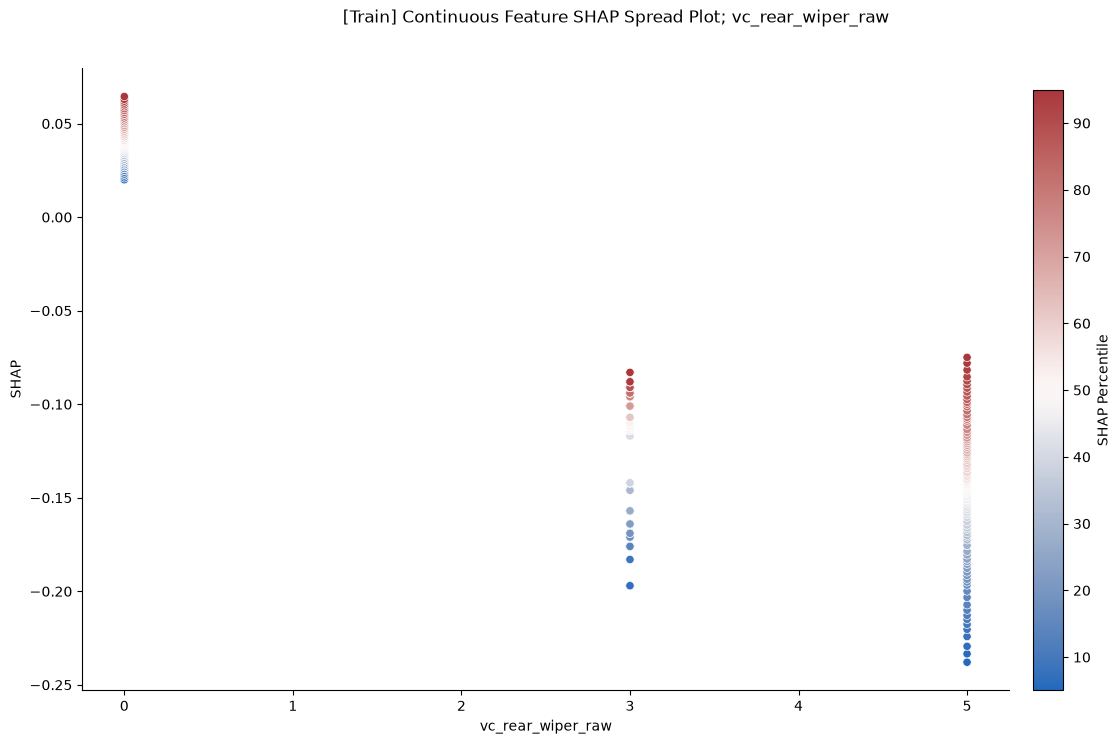

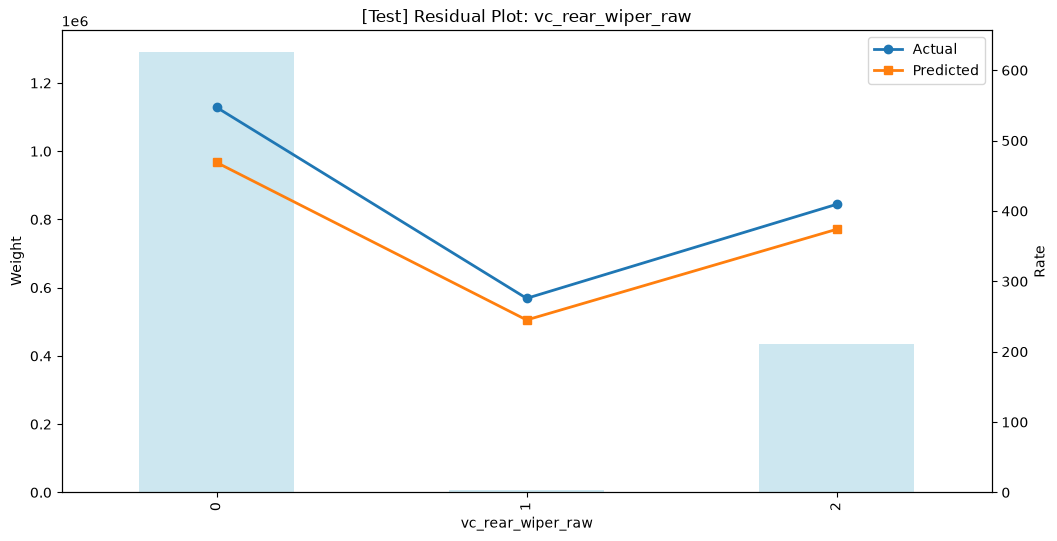

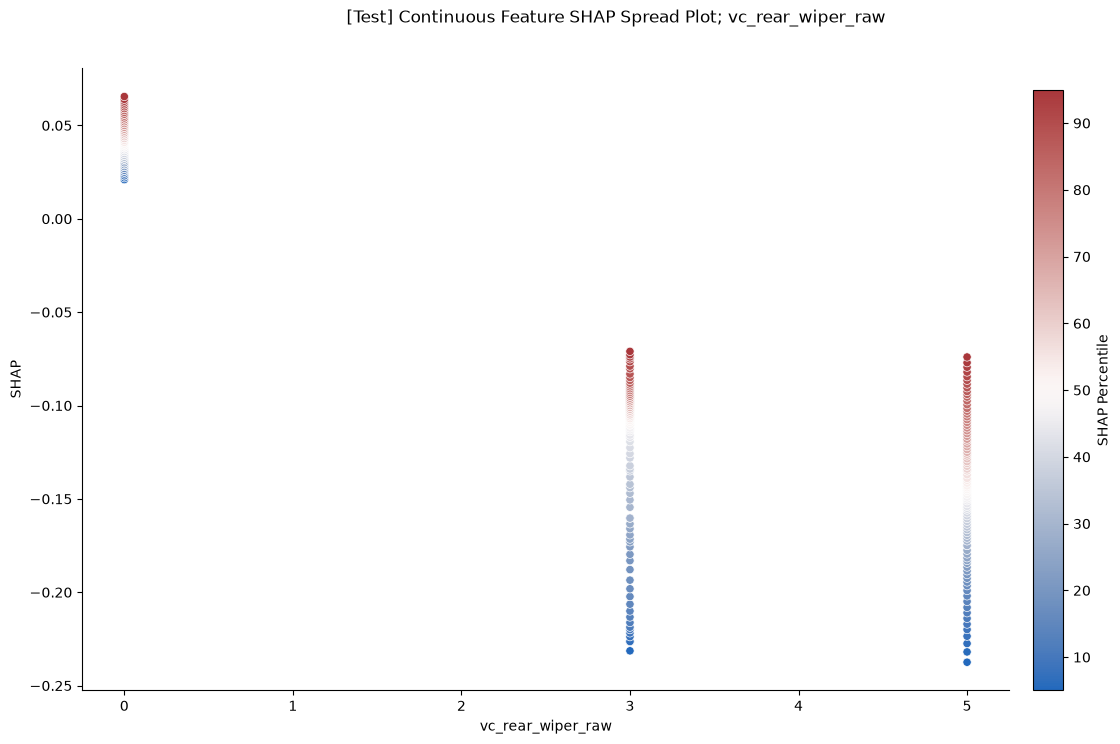


FEATURE: vc_speed_sensitive_volume_raw


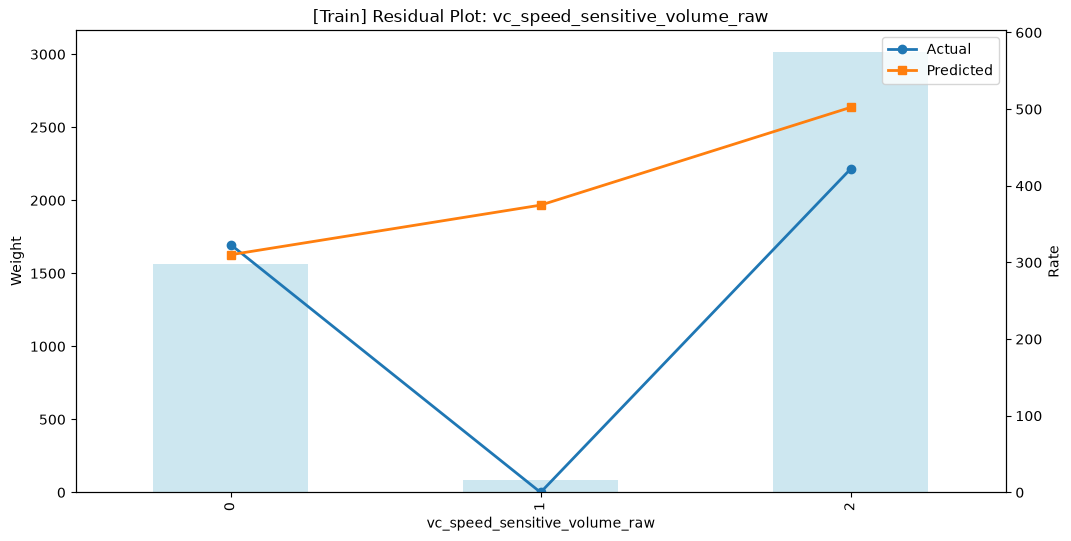

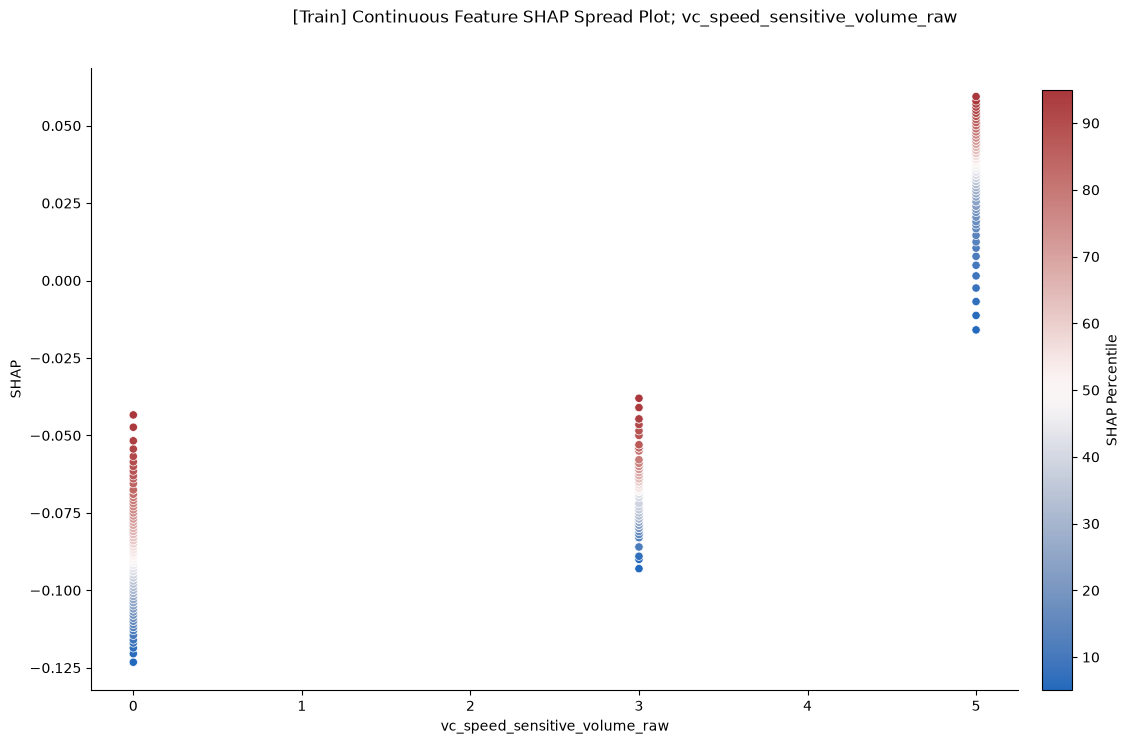

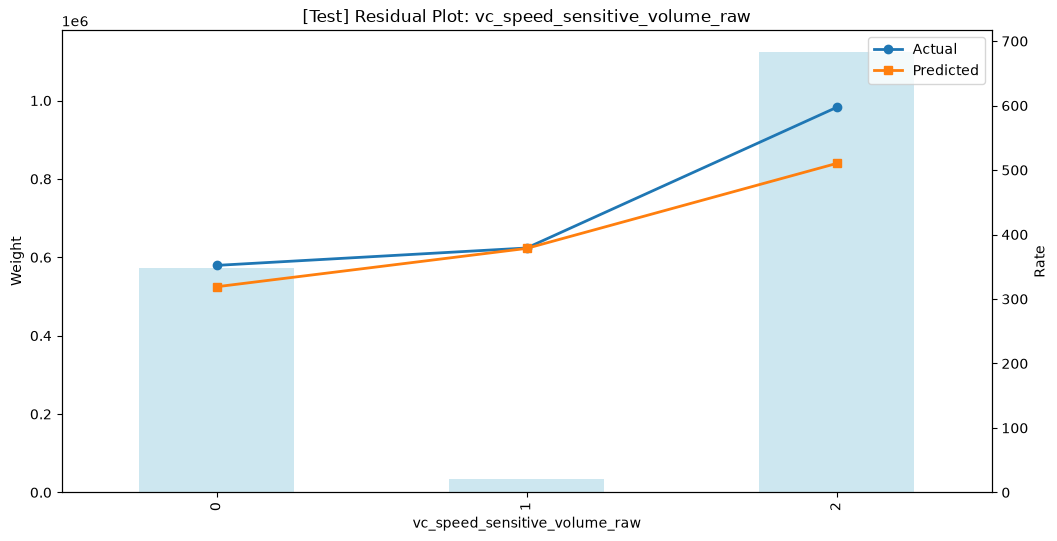

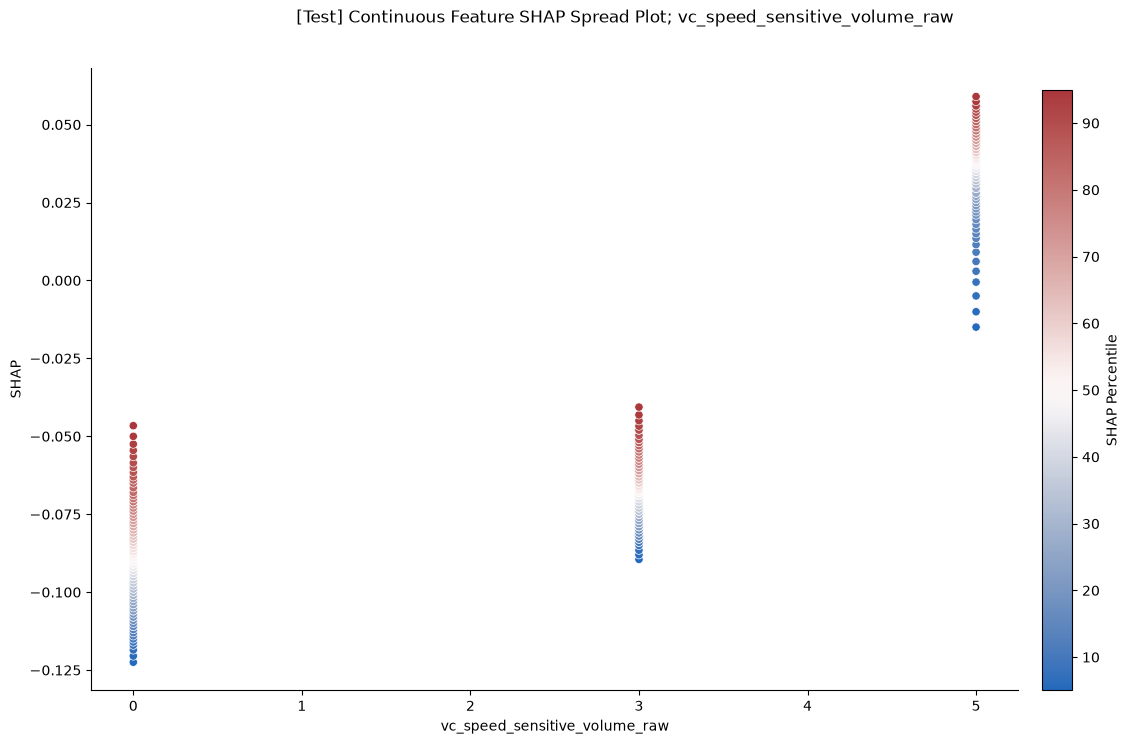


FEATURE: vc_satellite_radio_raw


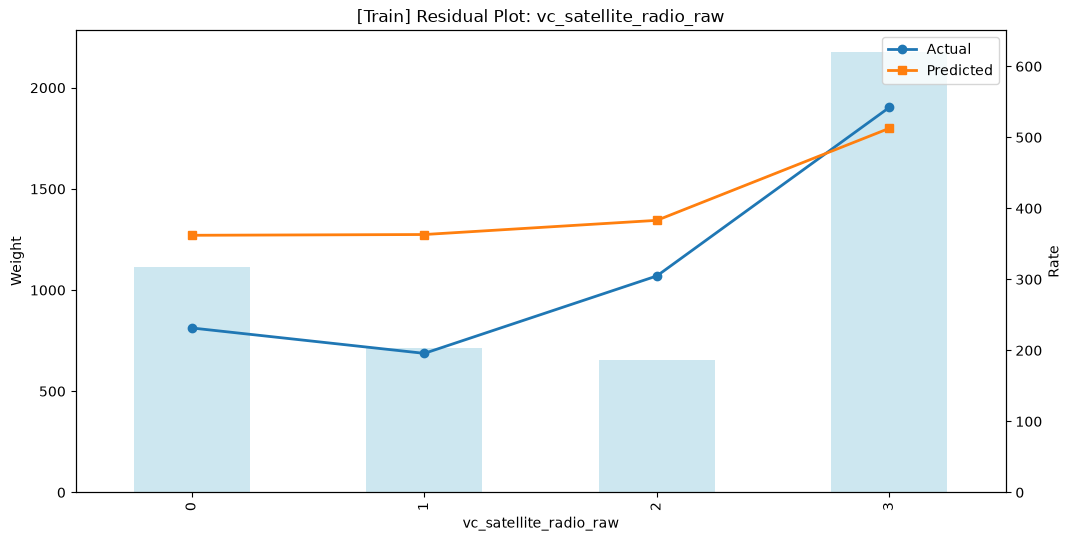

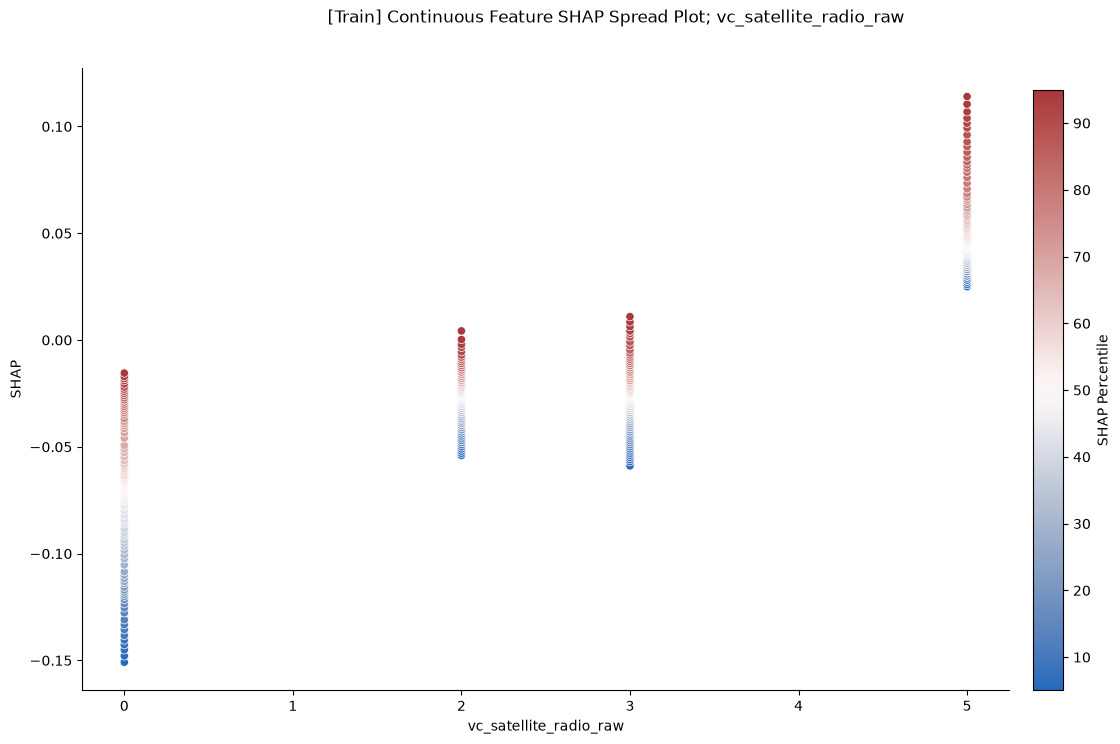

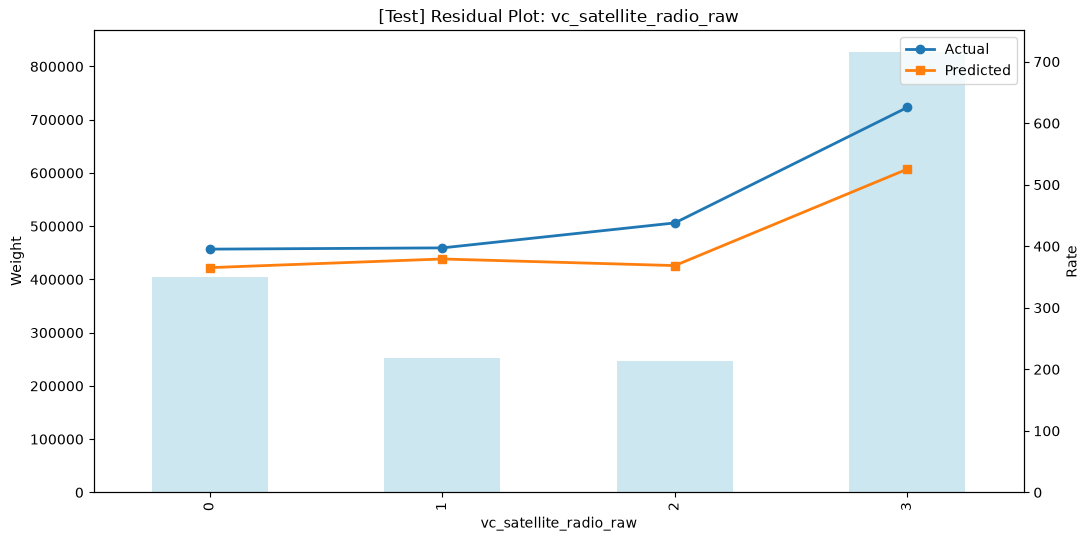

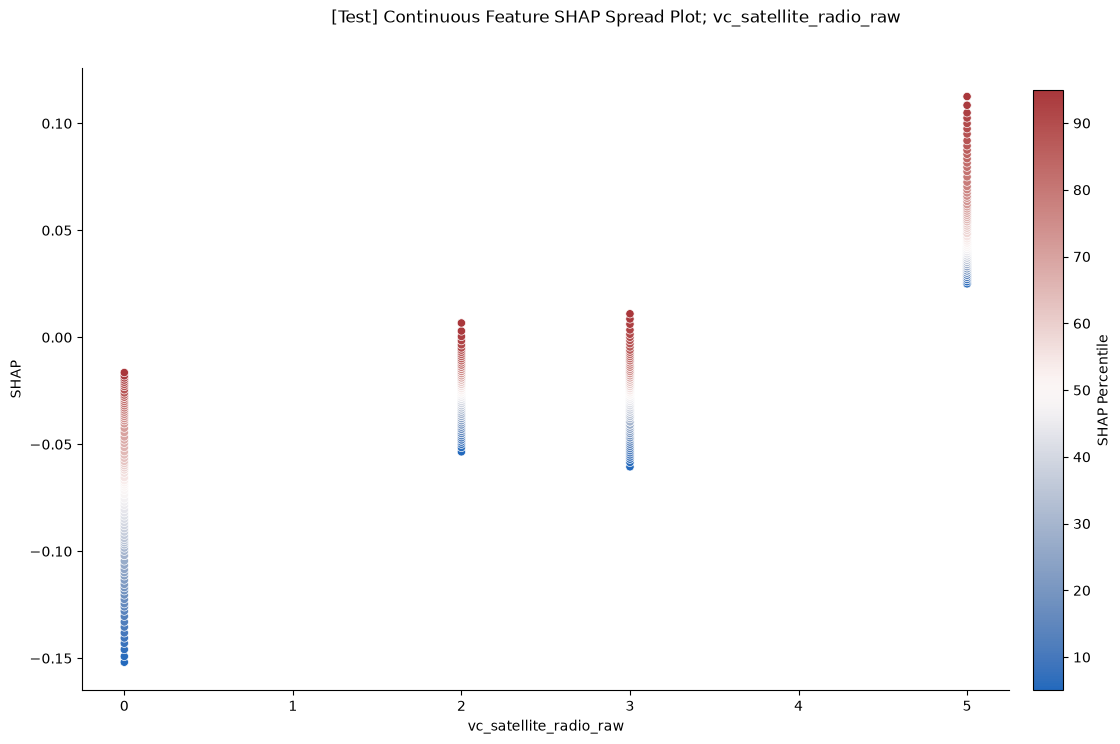


FEATURE: vc_headlights_auto_on_off_raw


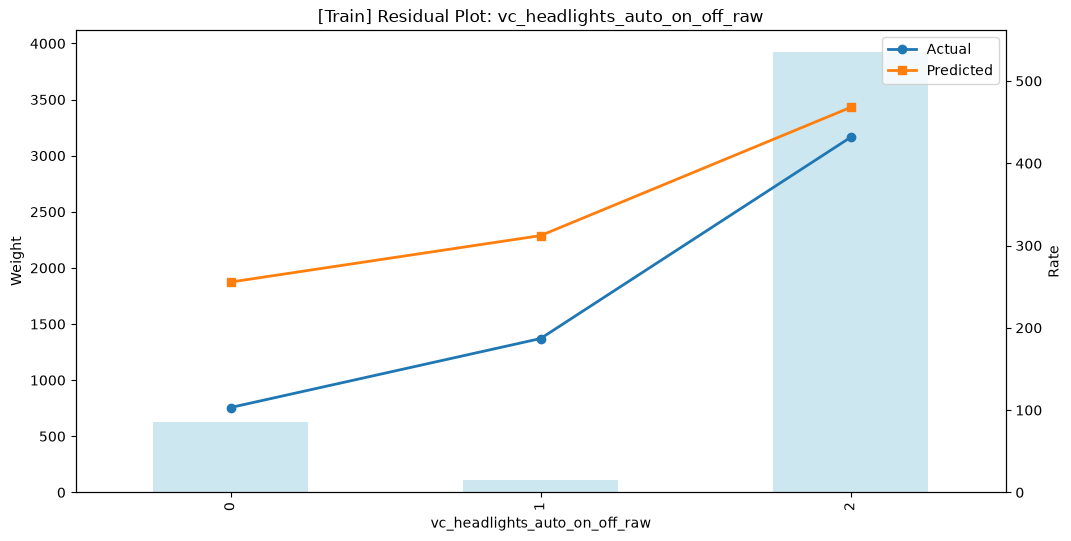

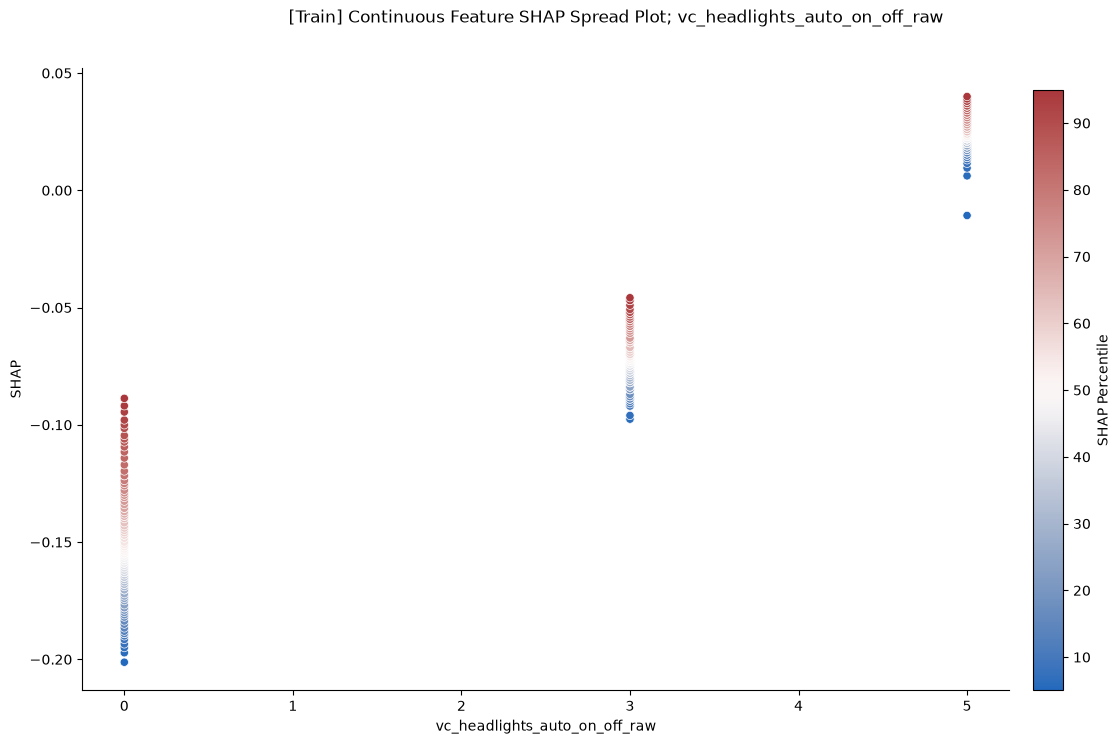

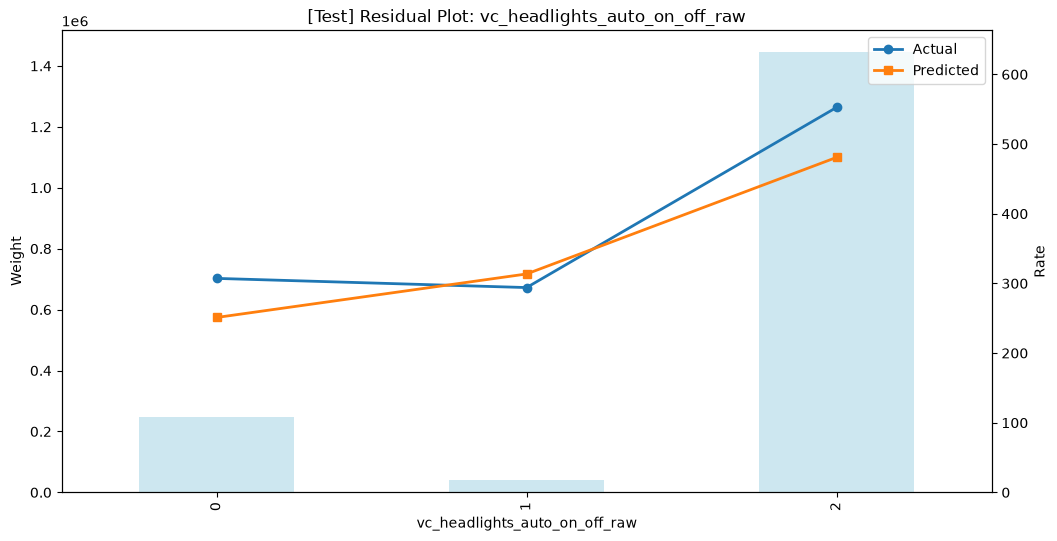

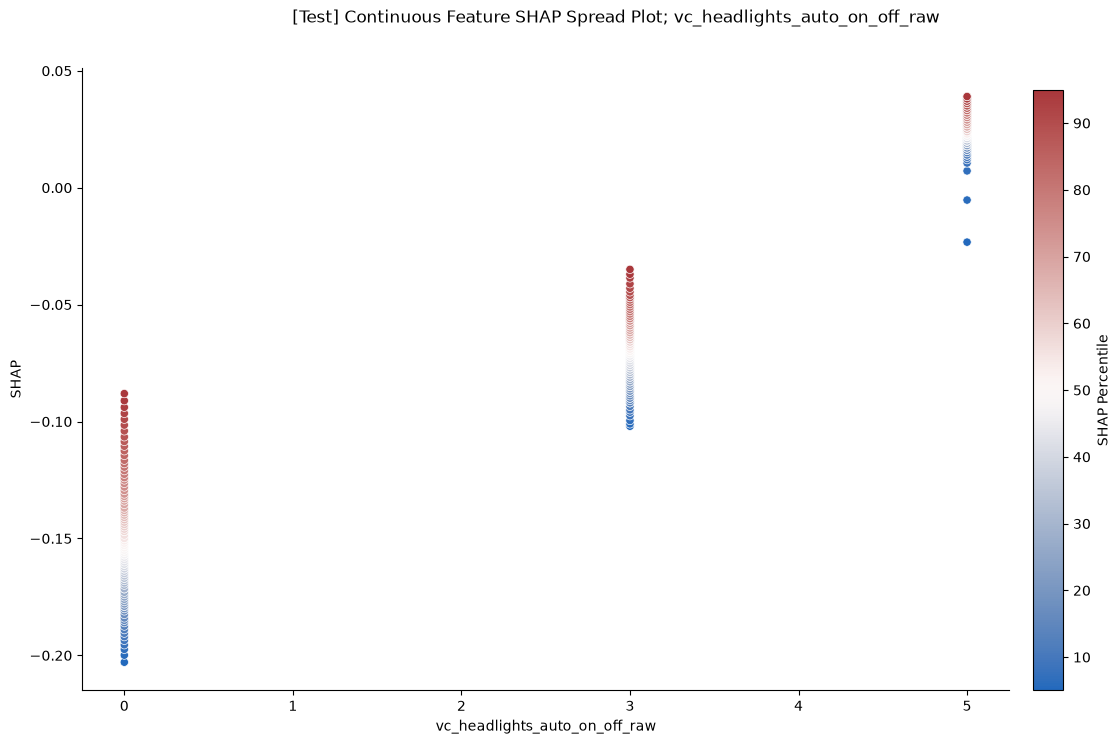


FEATURE: vc_hill_ascent_assist_raw


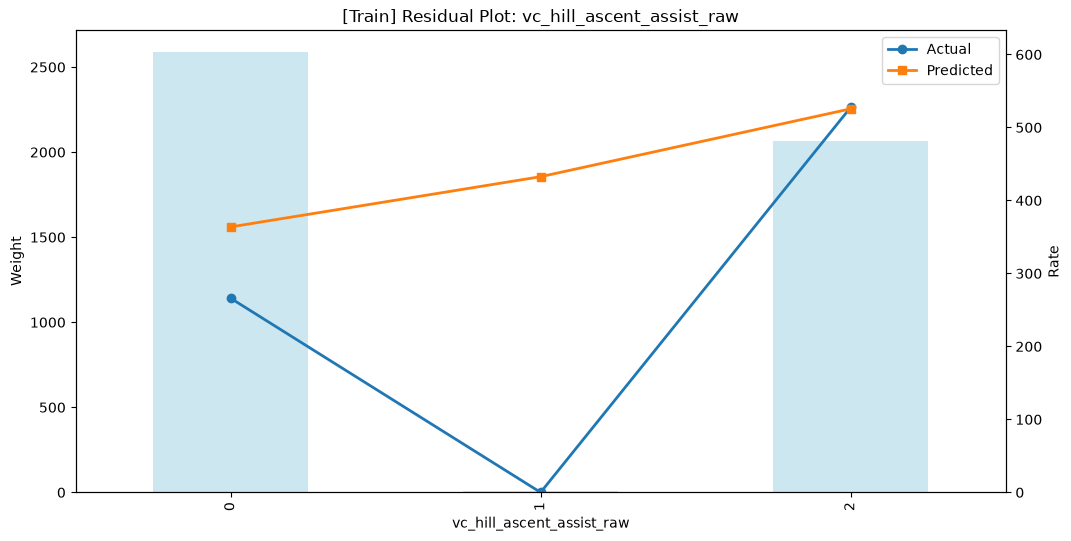

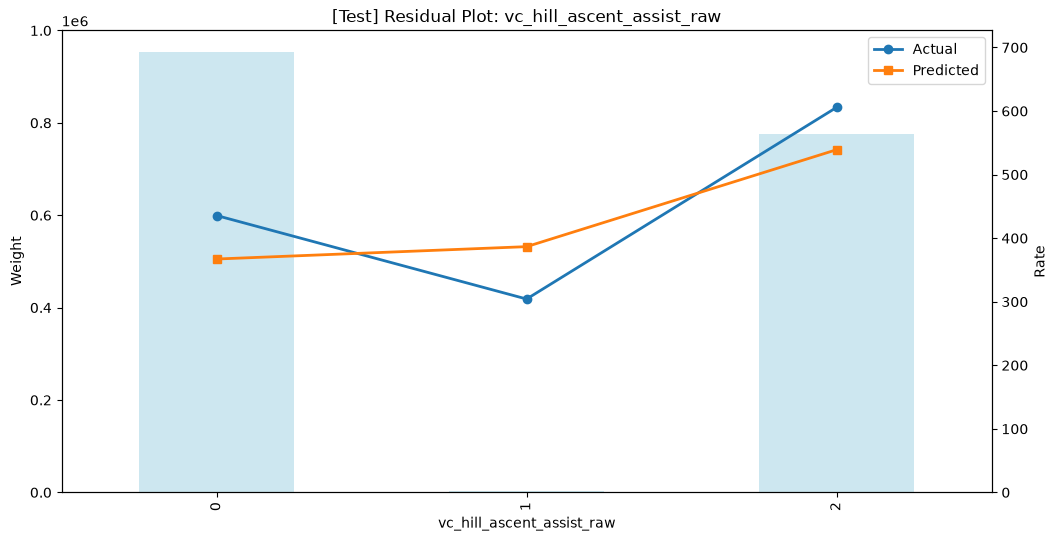

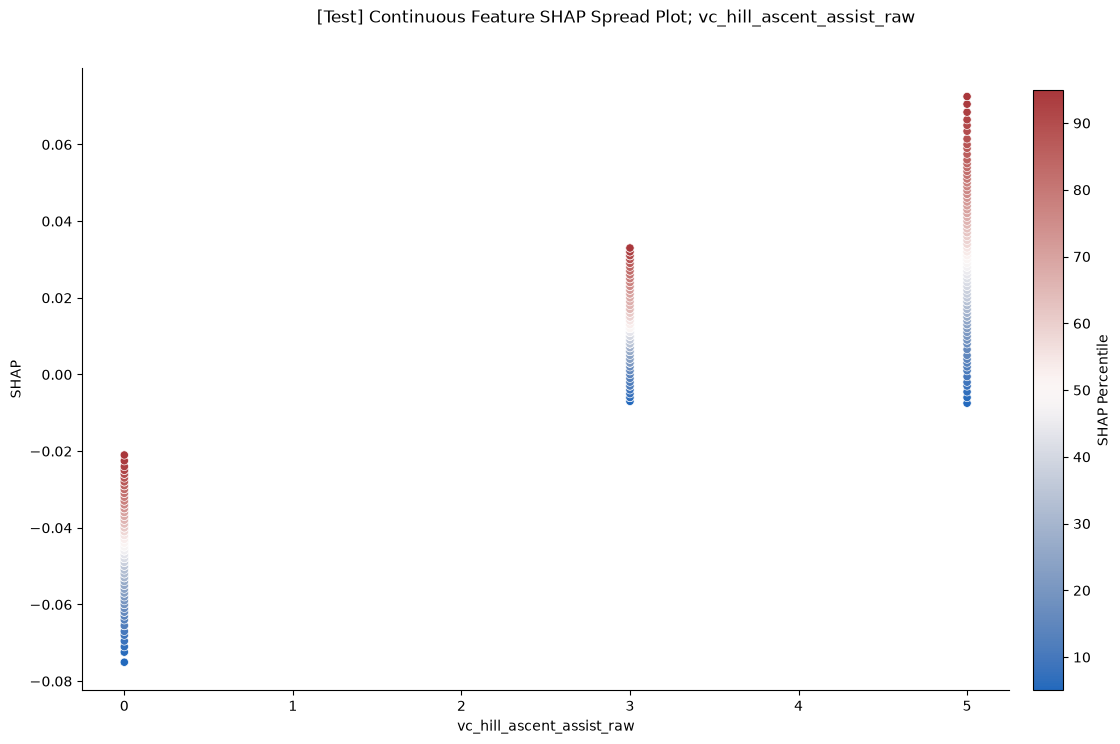


FEATURE: gender_male_ind


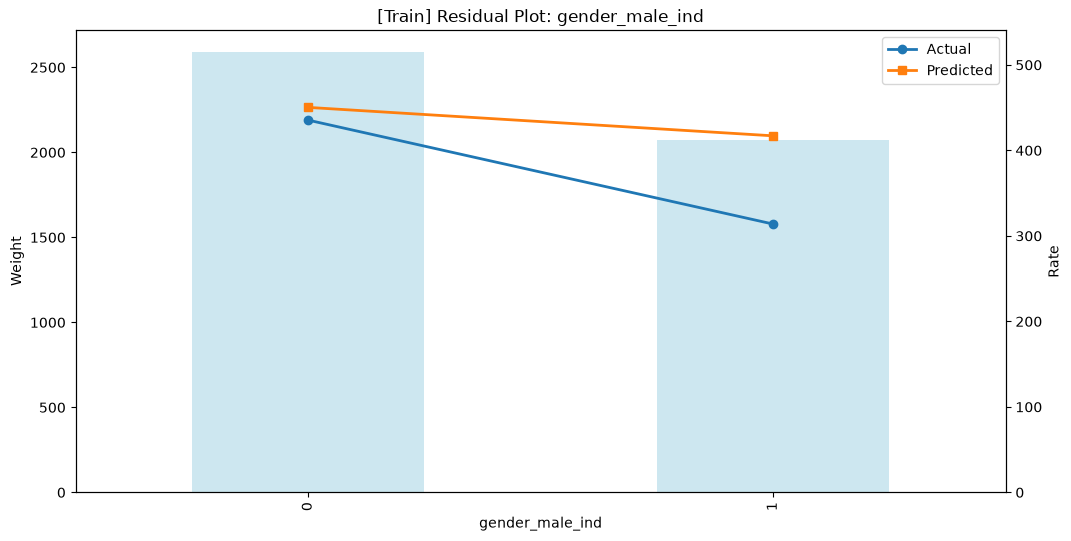

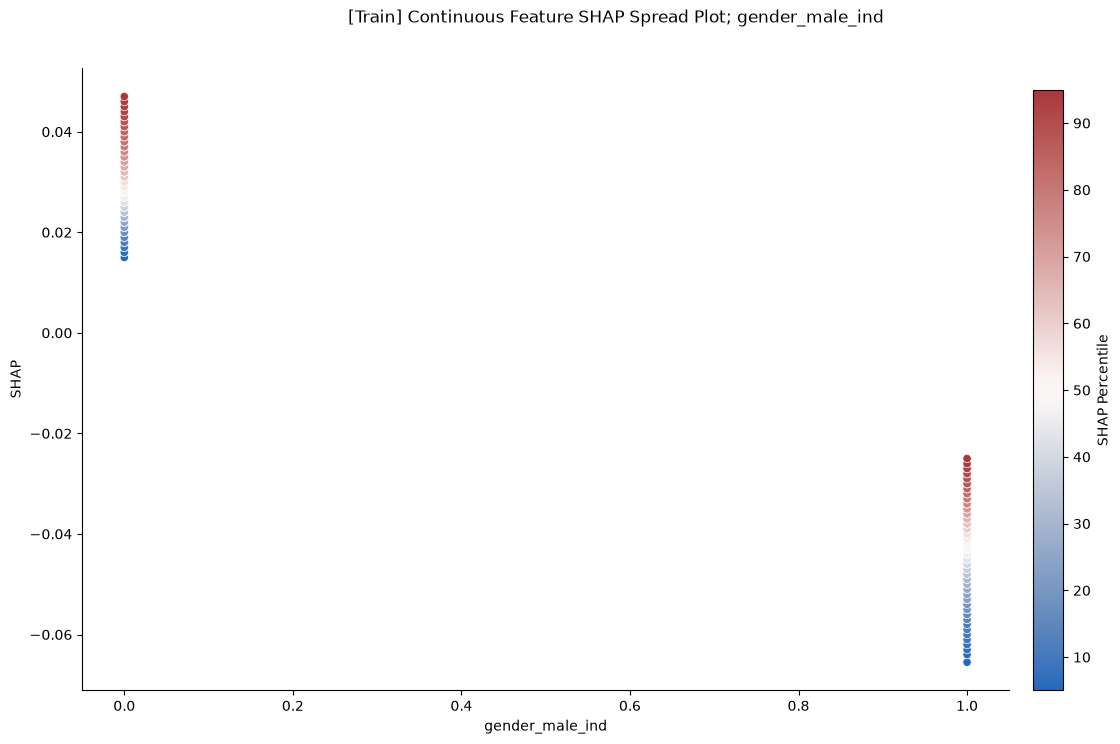

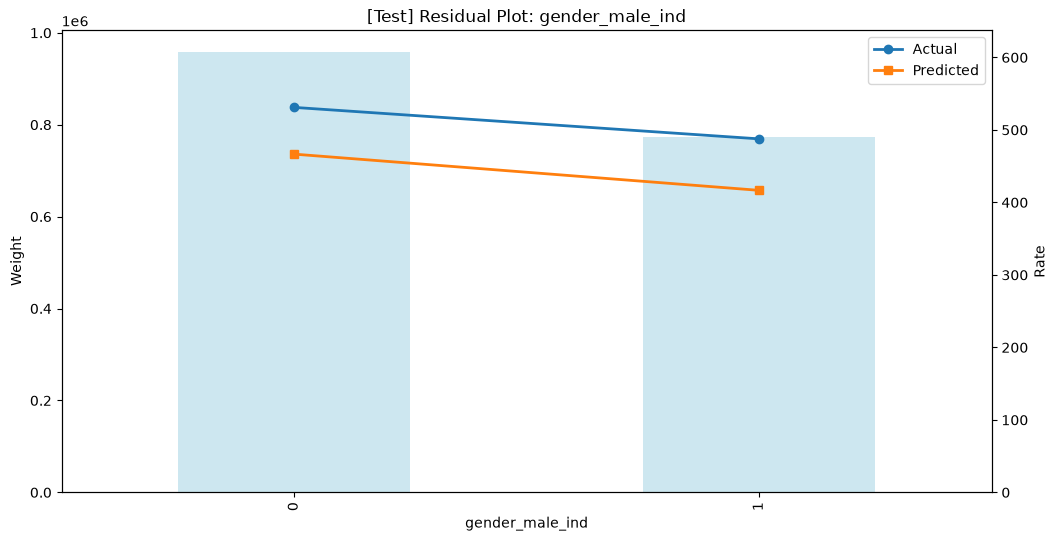

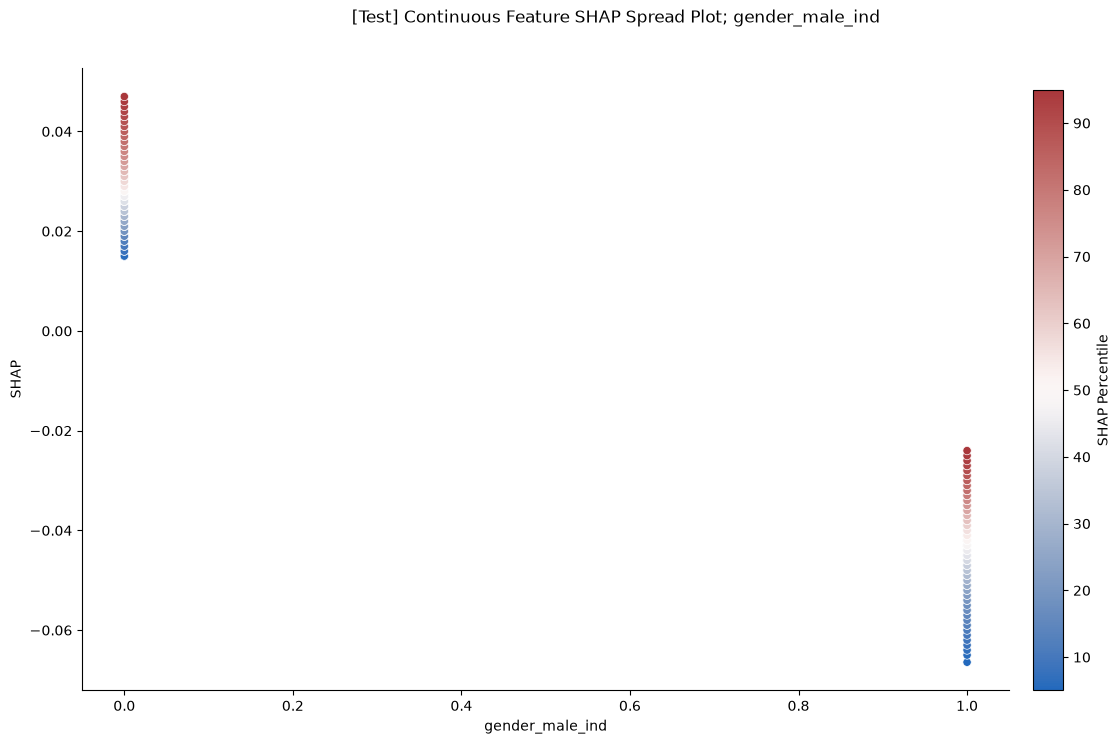


FEATURE: vc_premium_audio_raw


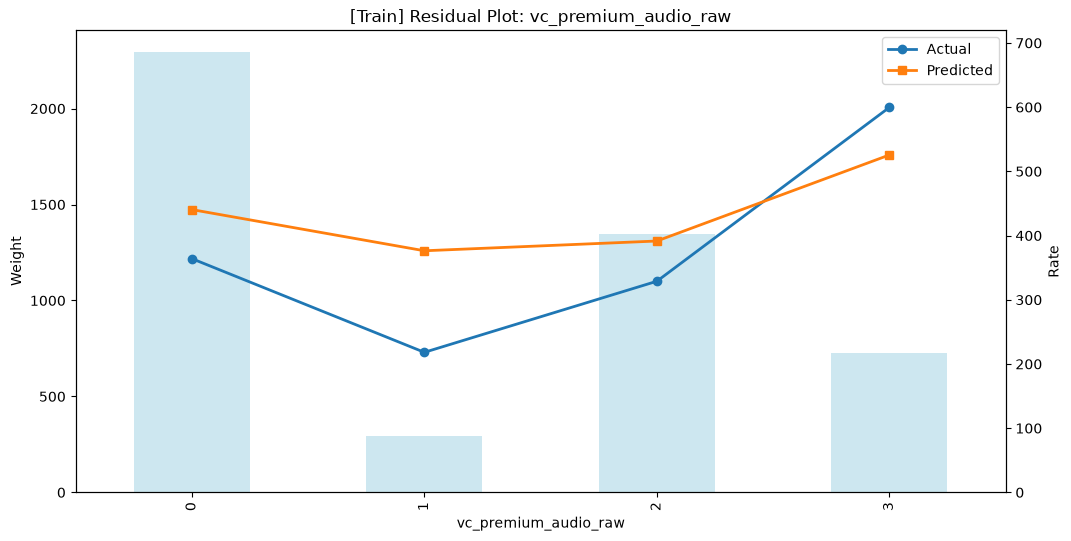

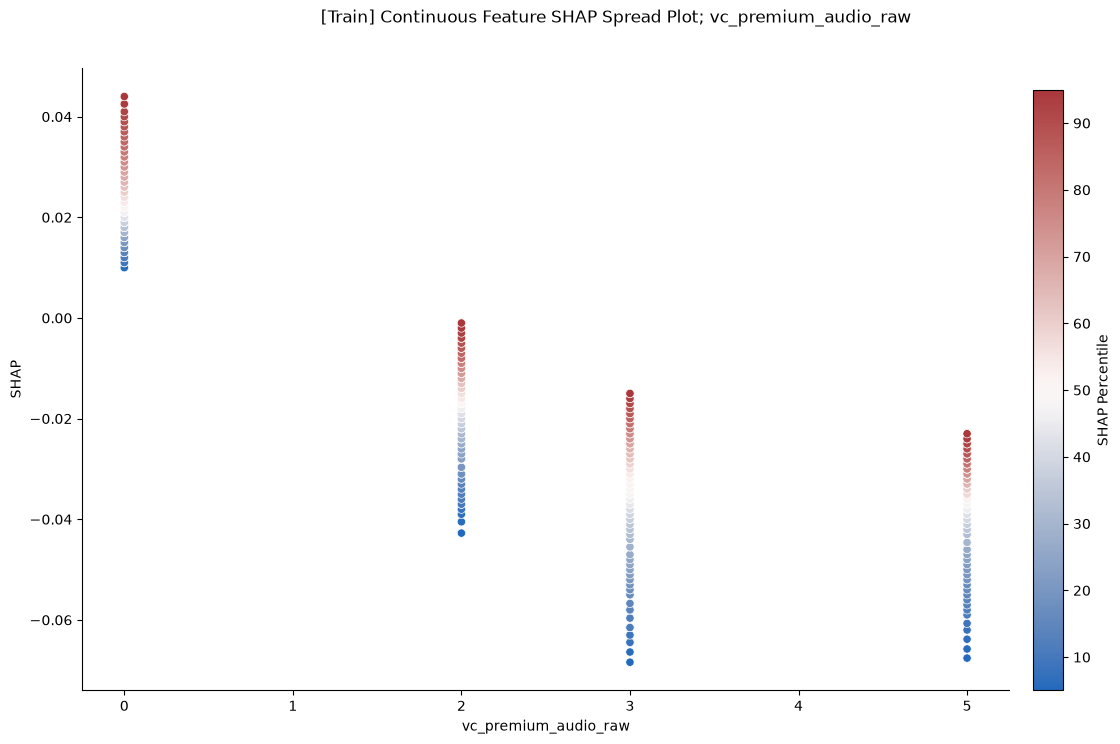

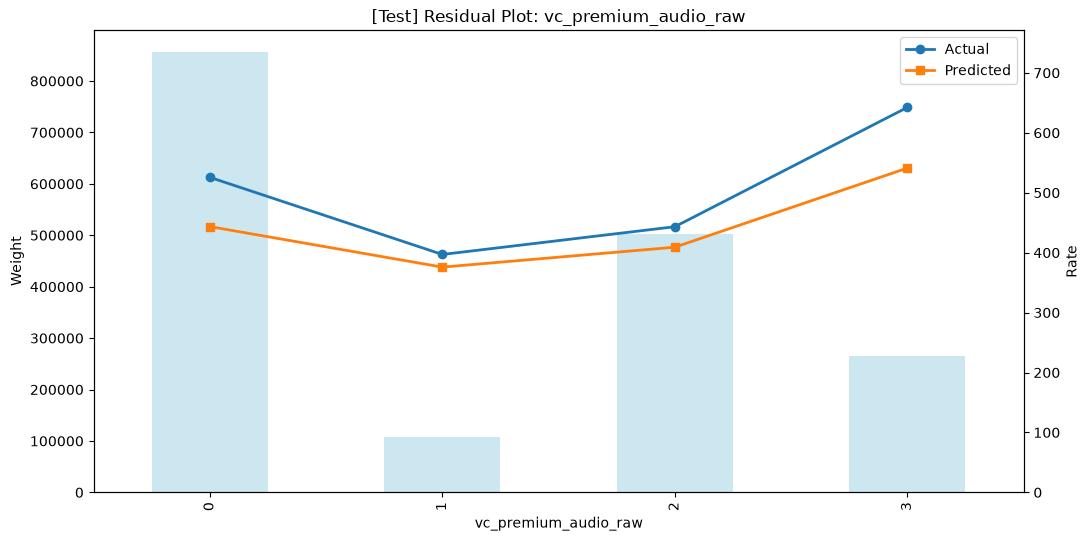

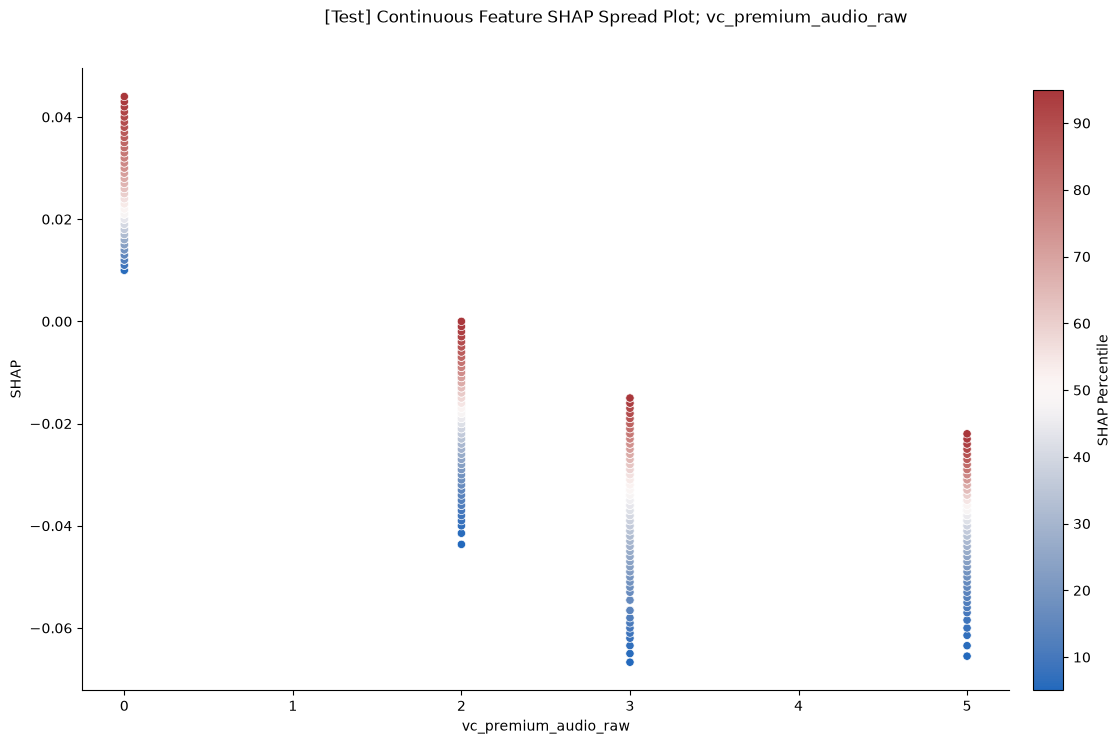


FEATURE: vc_taillights_led_raw


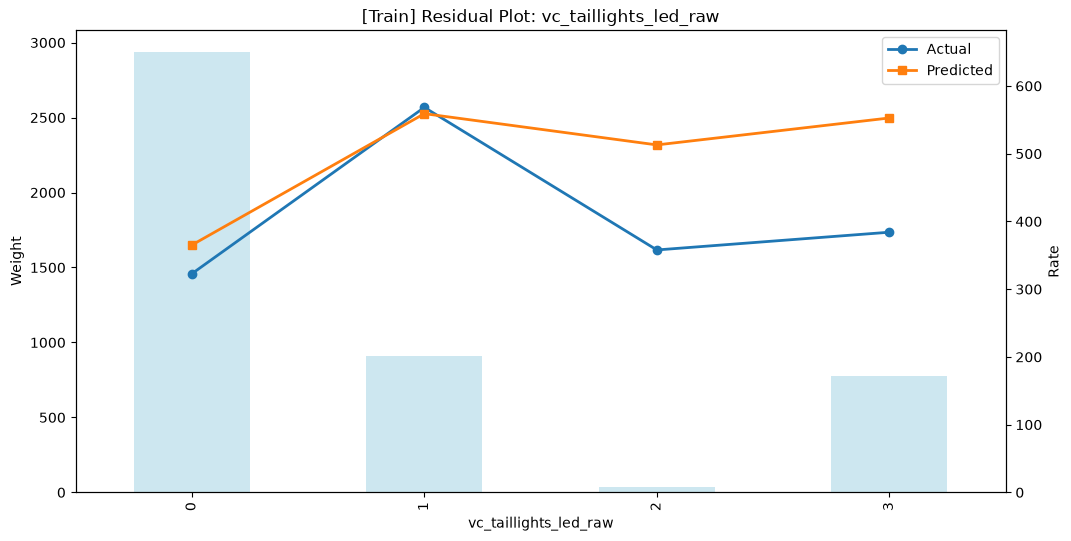

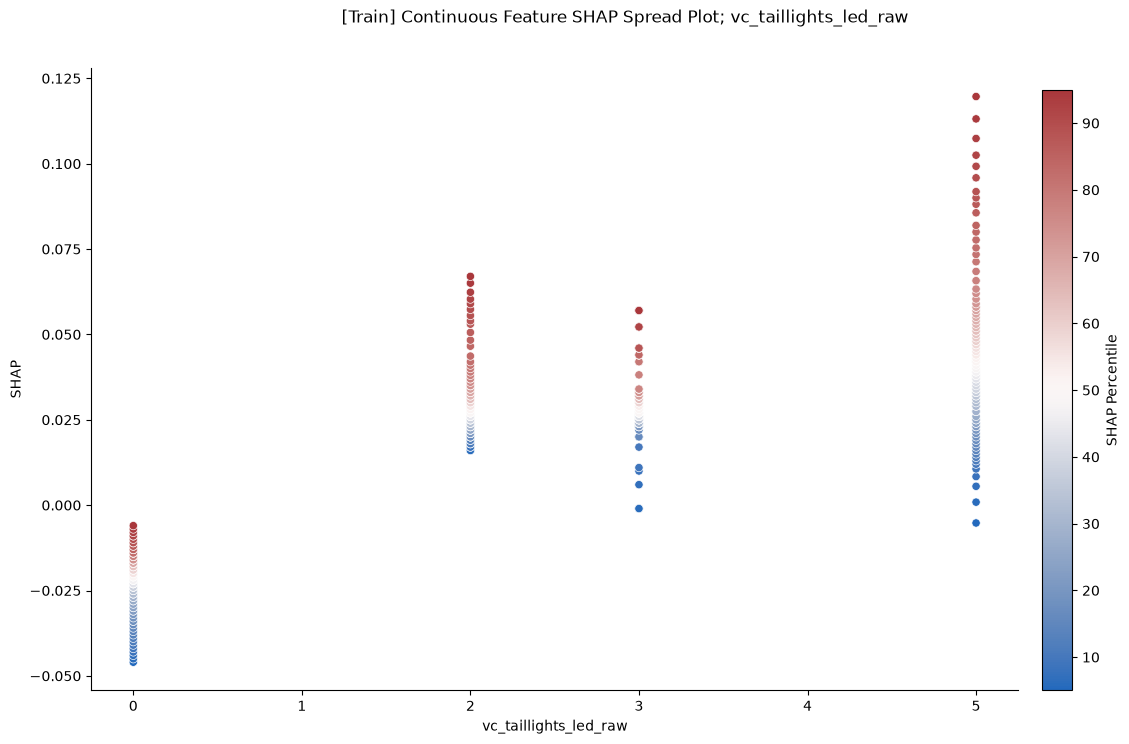

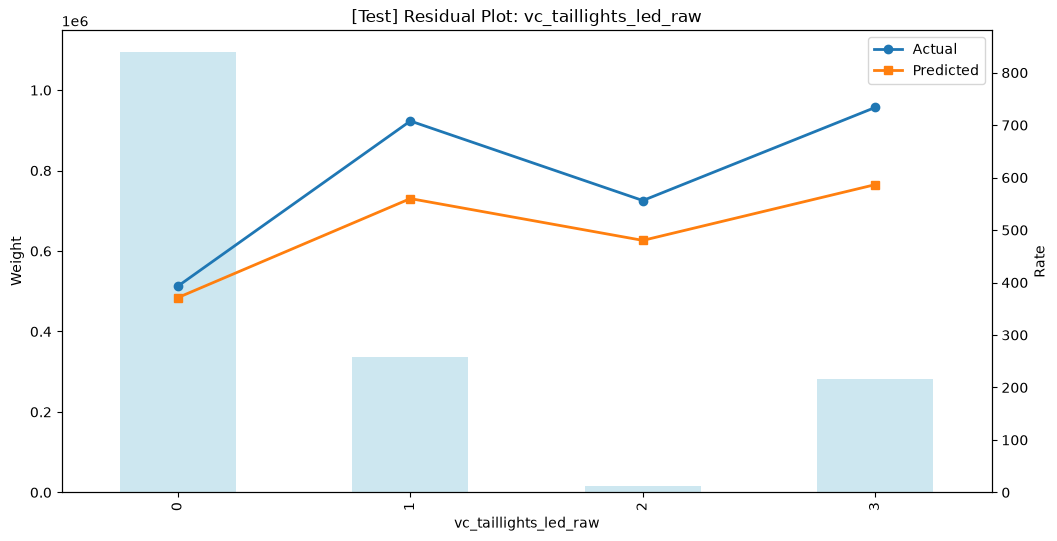

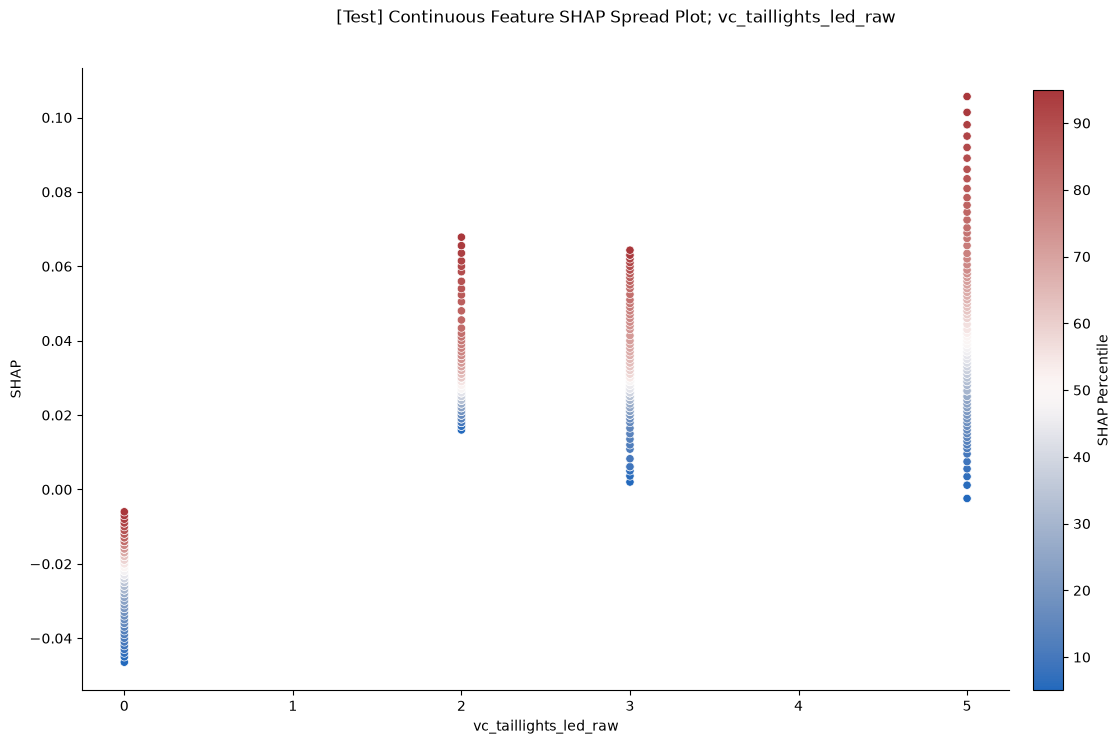


FEATURE: vc_subwoofer_raw


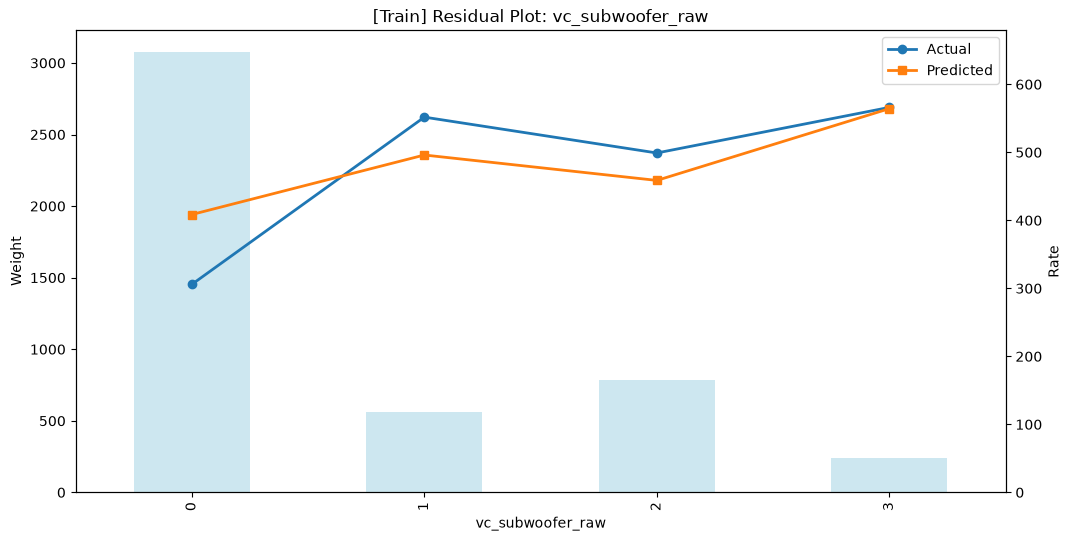

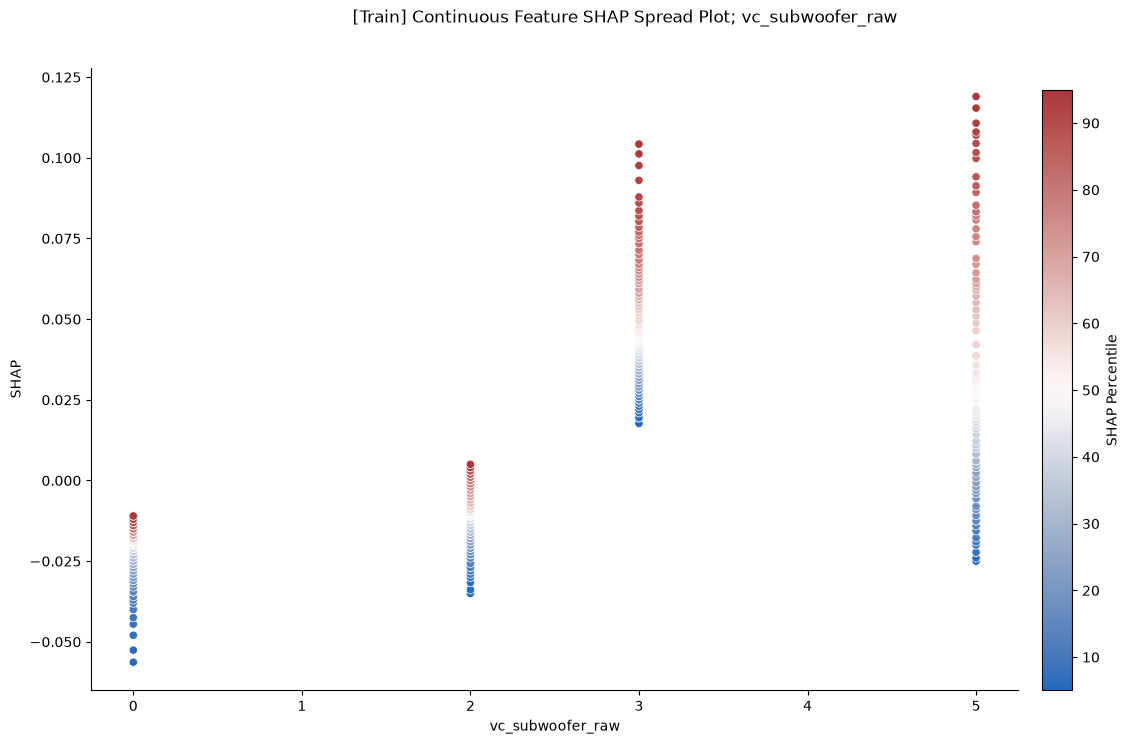

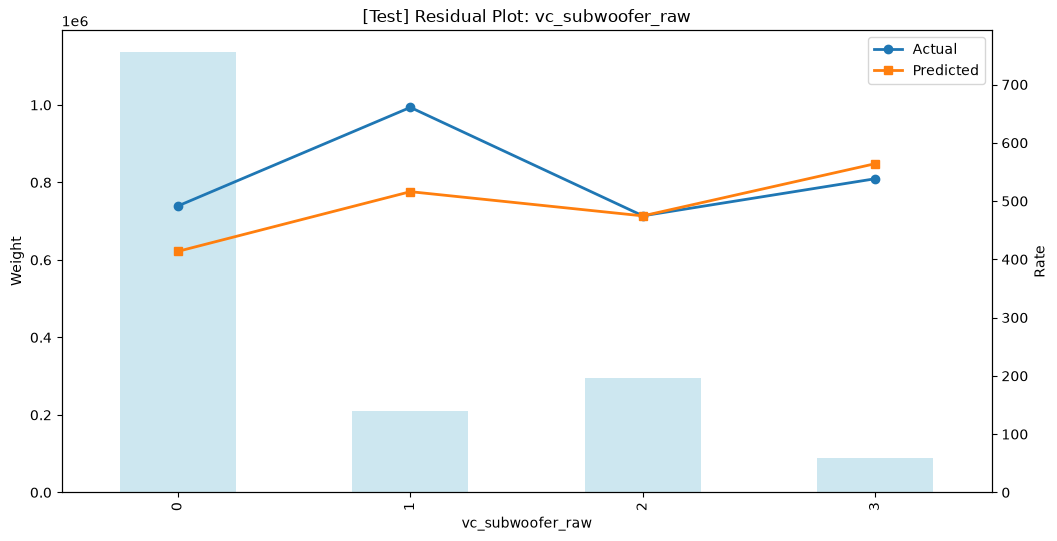

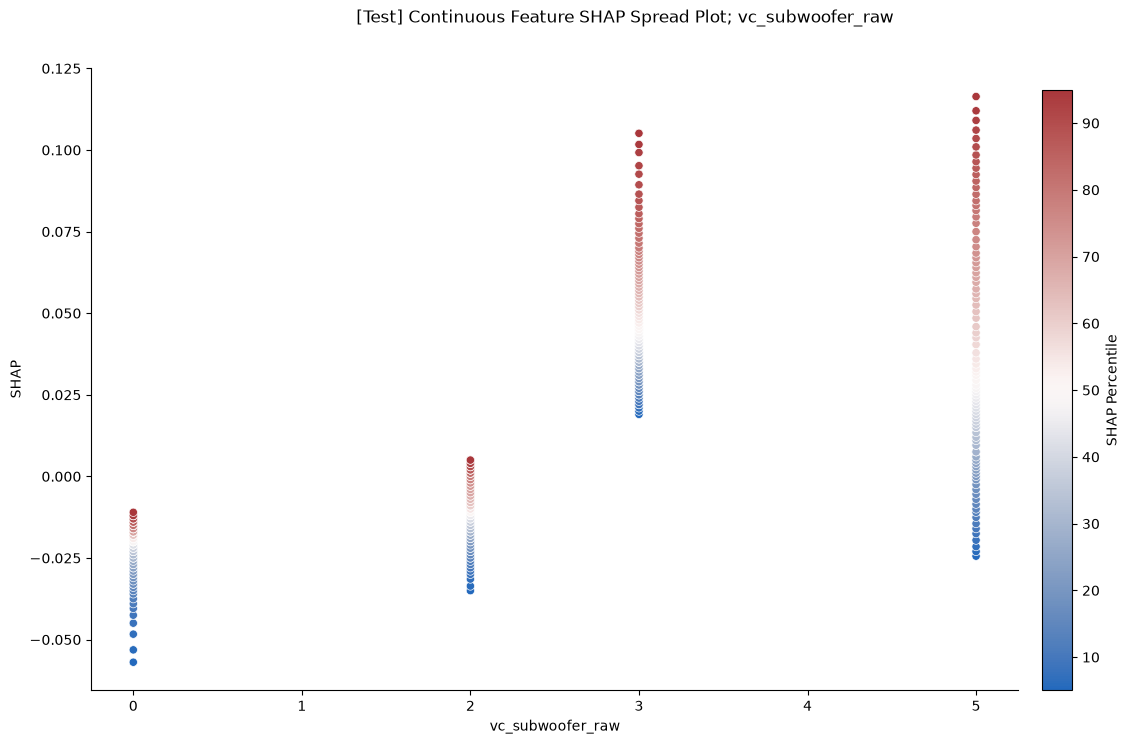


FEATURE: vc_auto_start_stop_raw


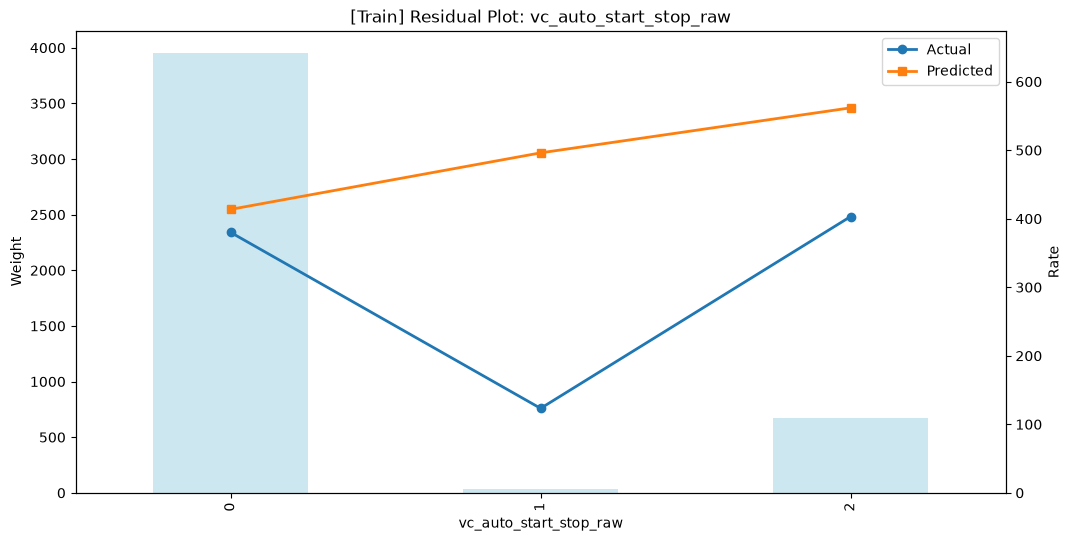

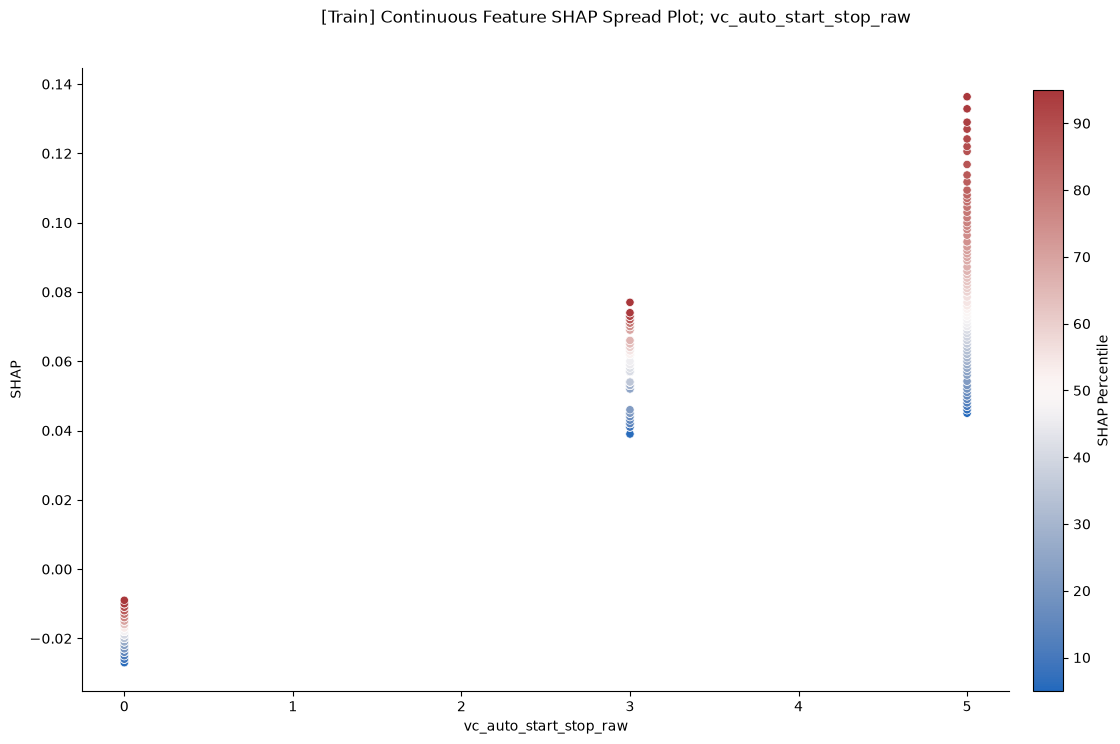

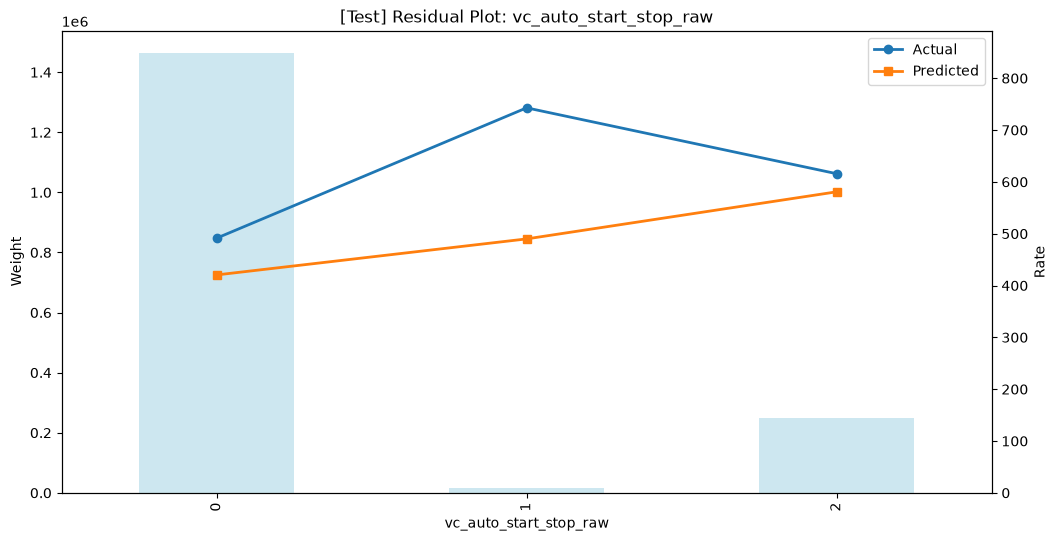

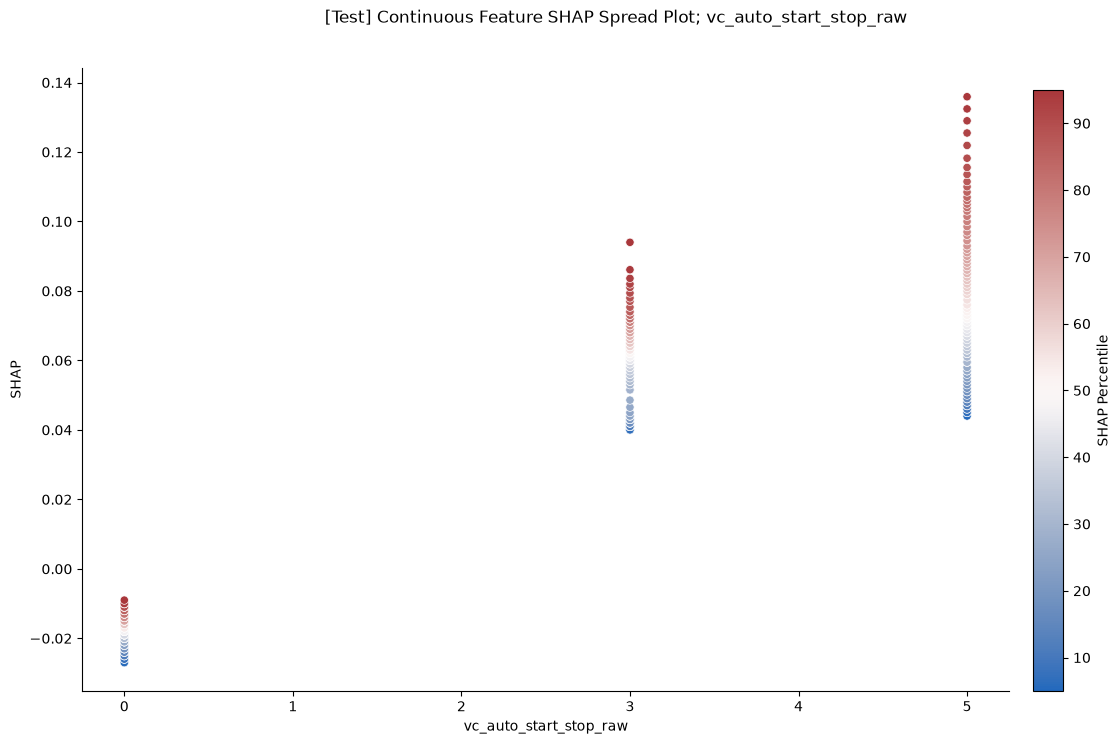


FEATURE: vc_touch_screen_raw


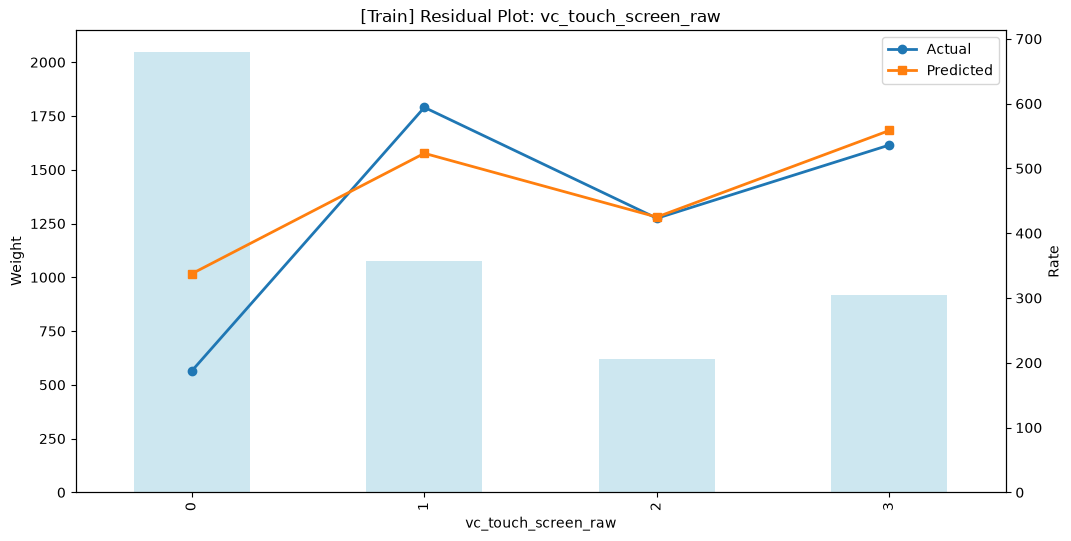

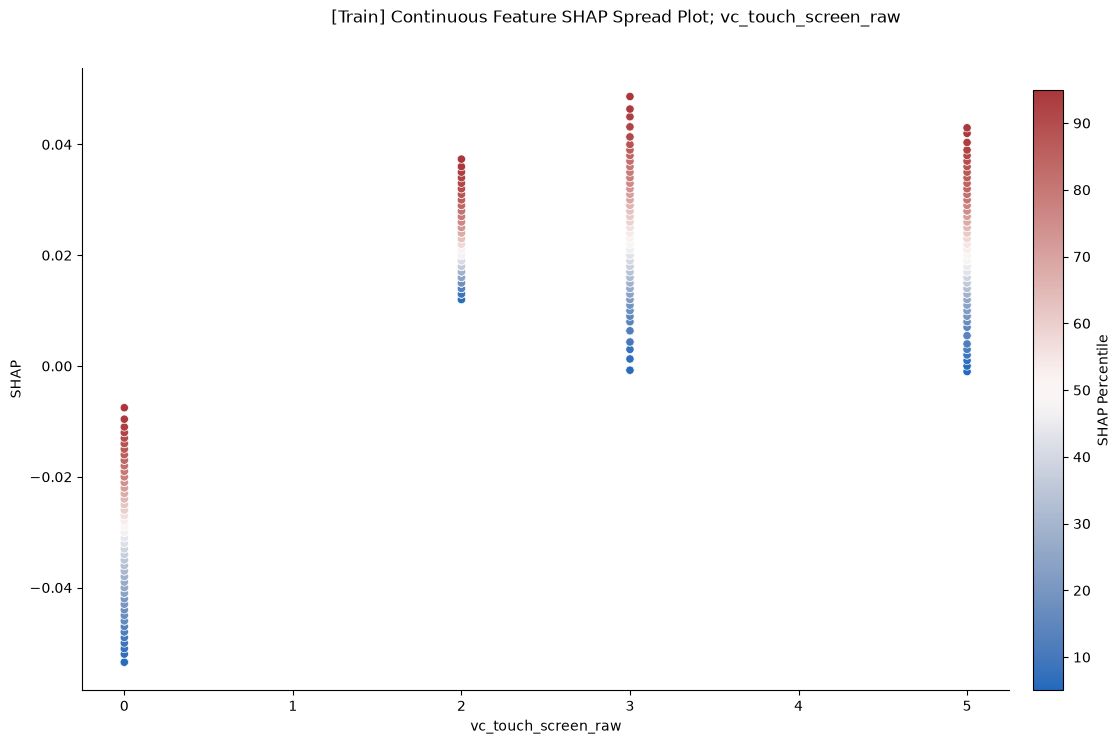

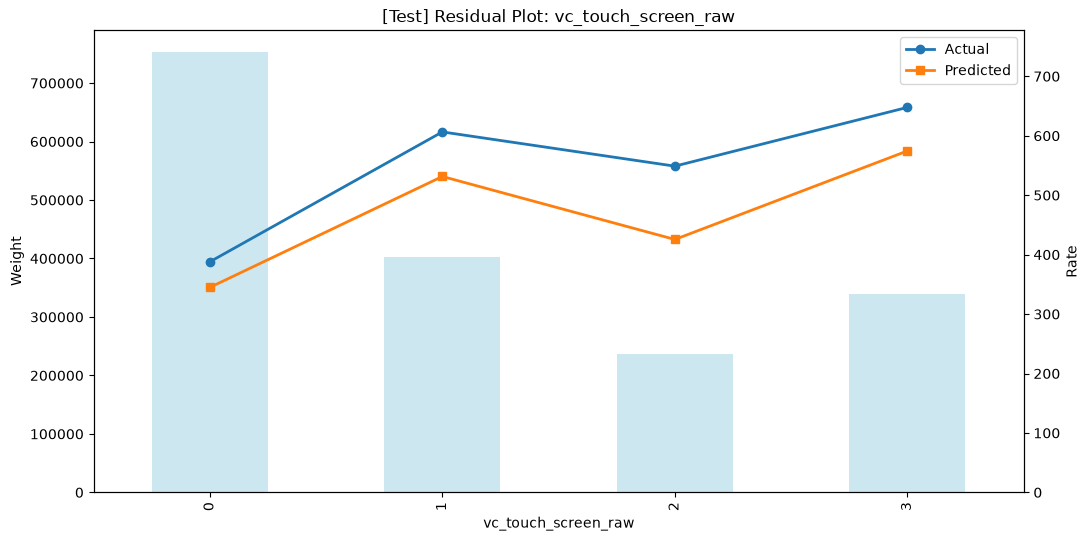

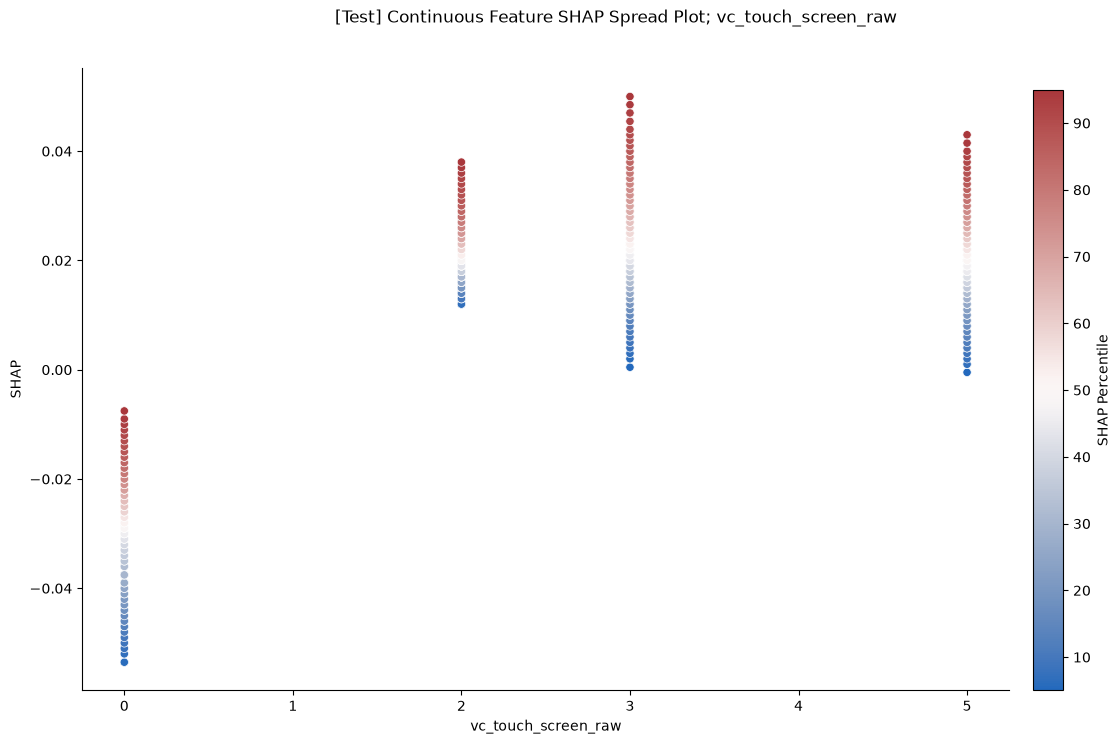


FEATURE: cef_first_cpo_ind


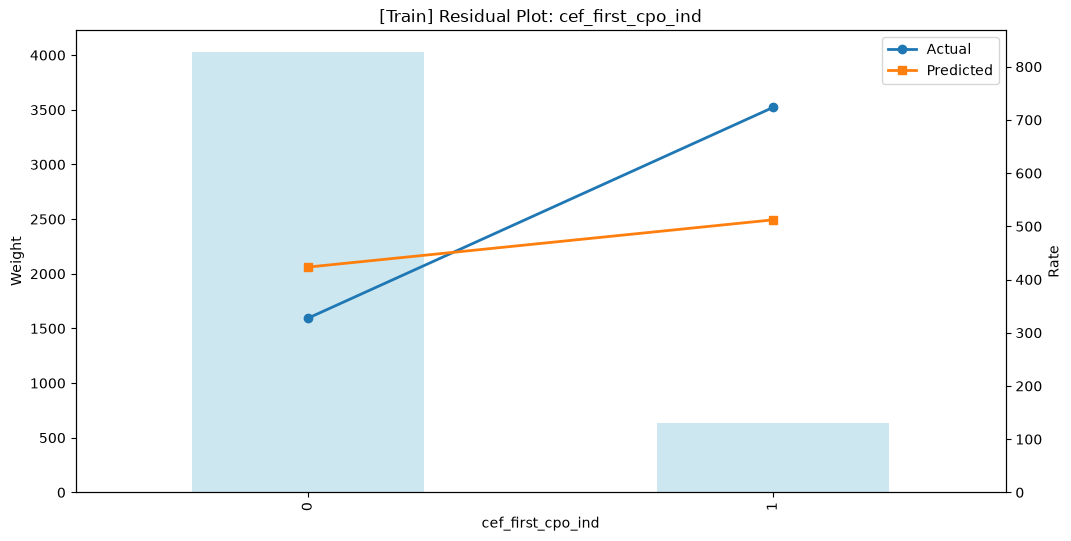

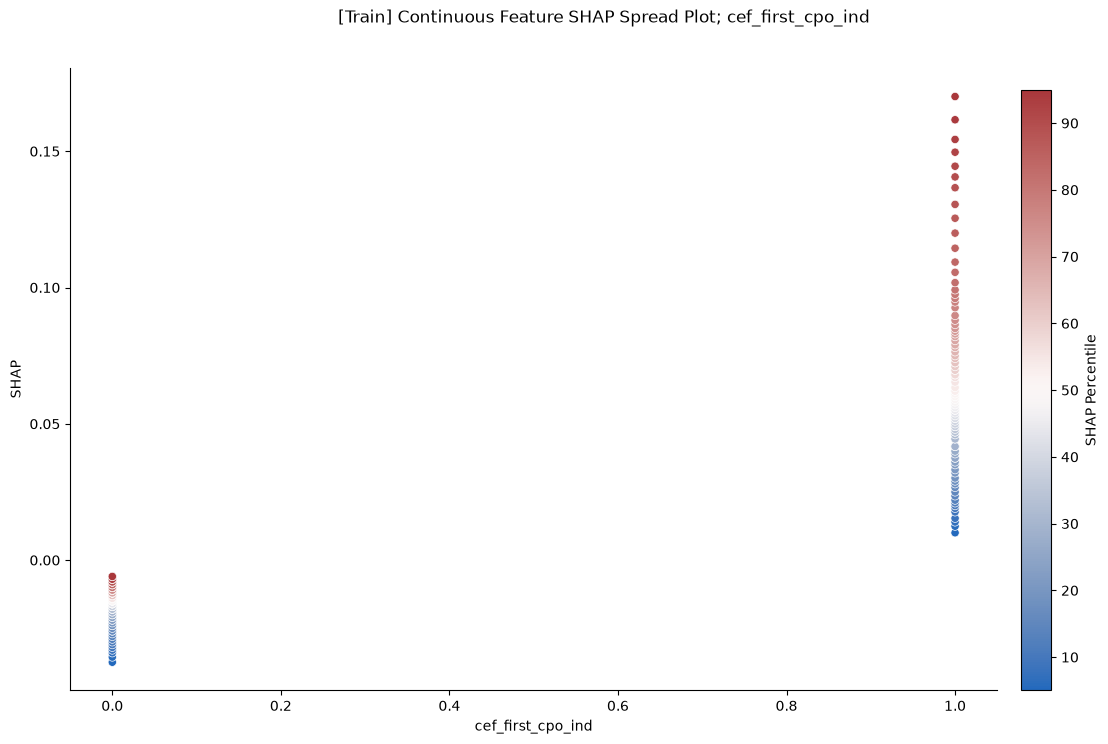

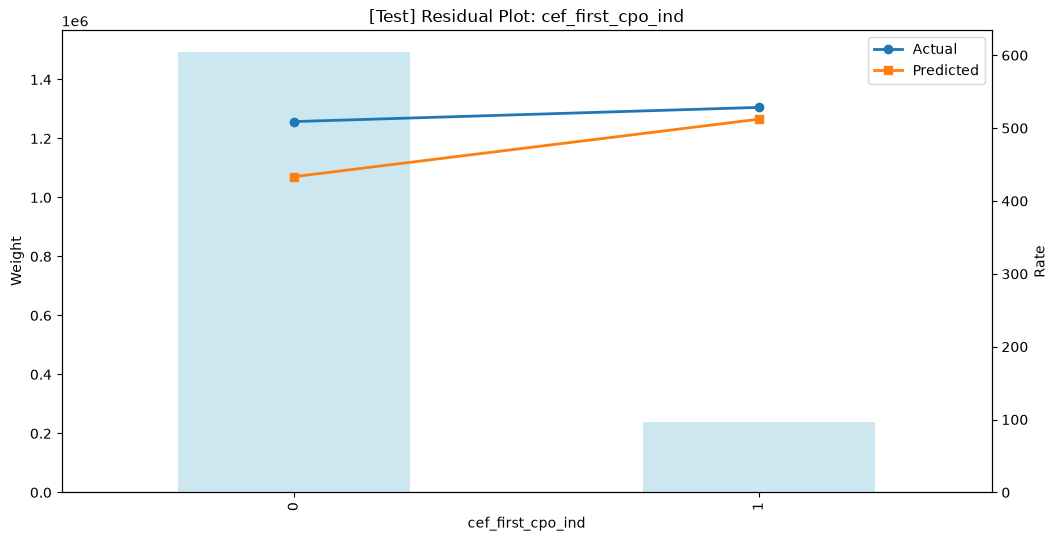

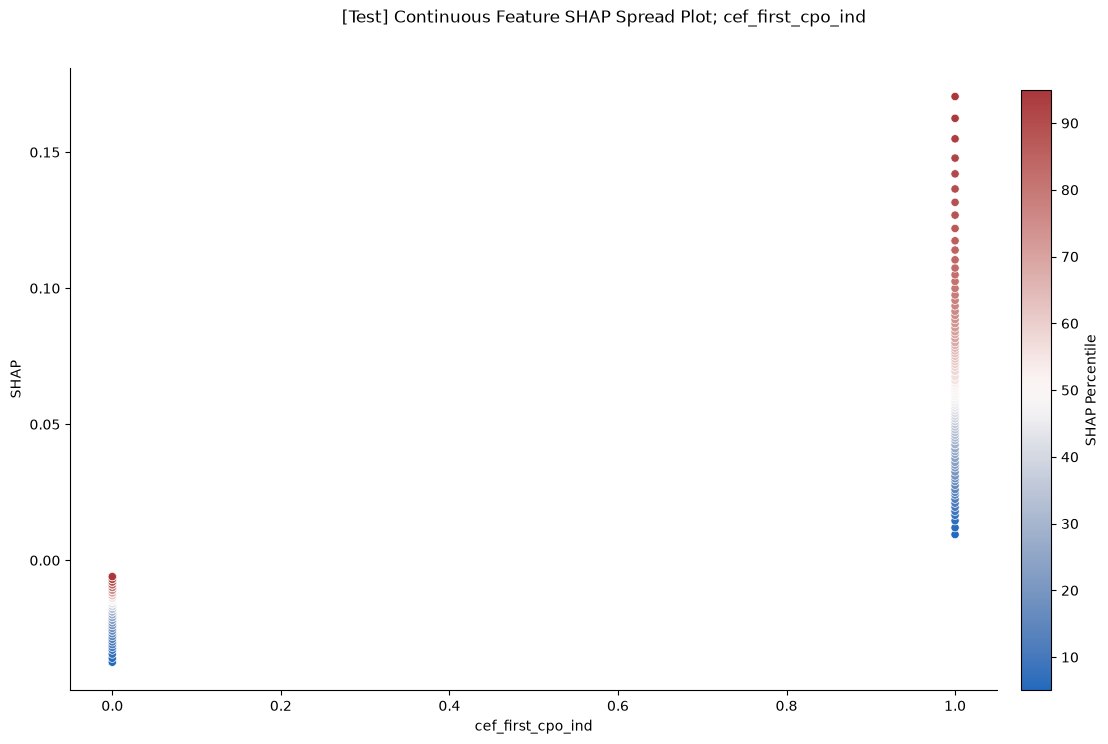


FEATURE: vc_drive_type_fwd_ind


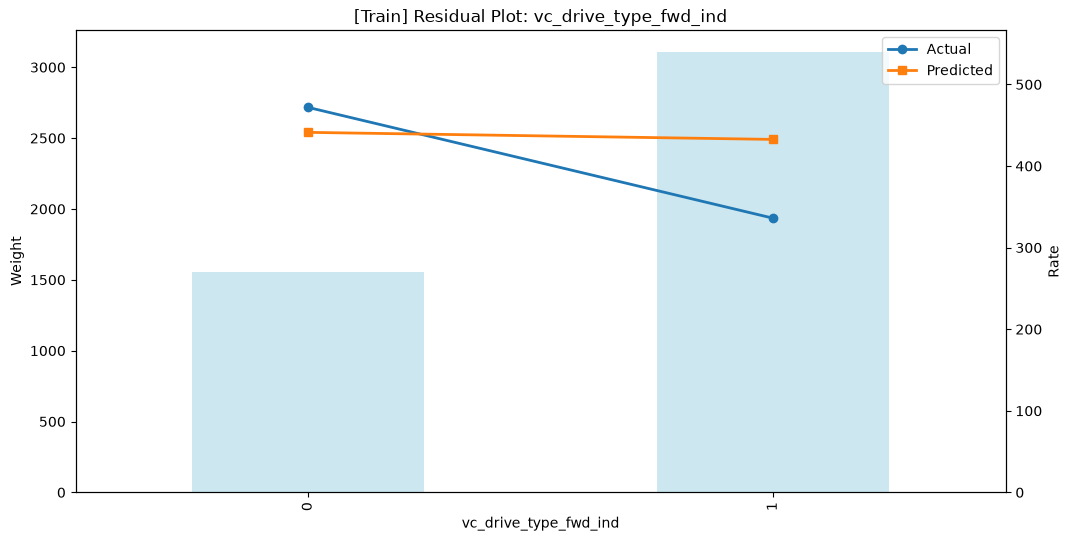

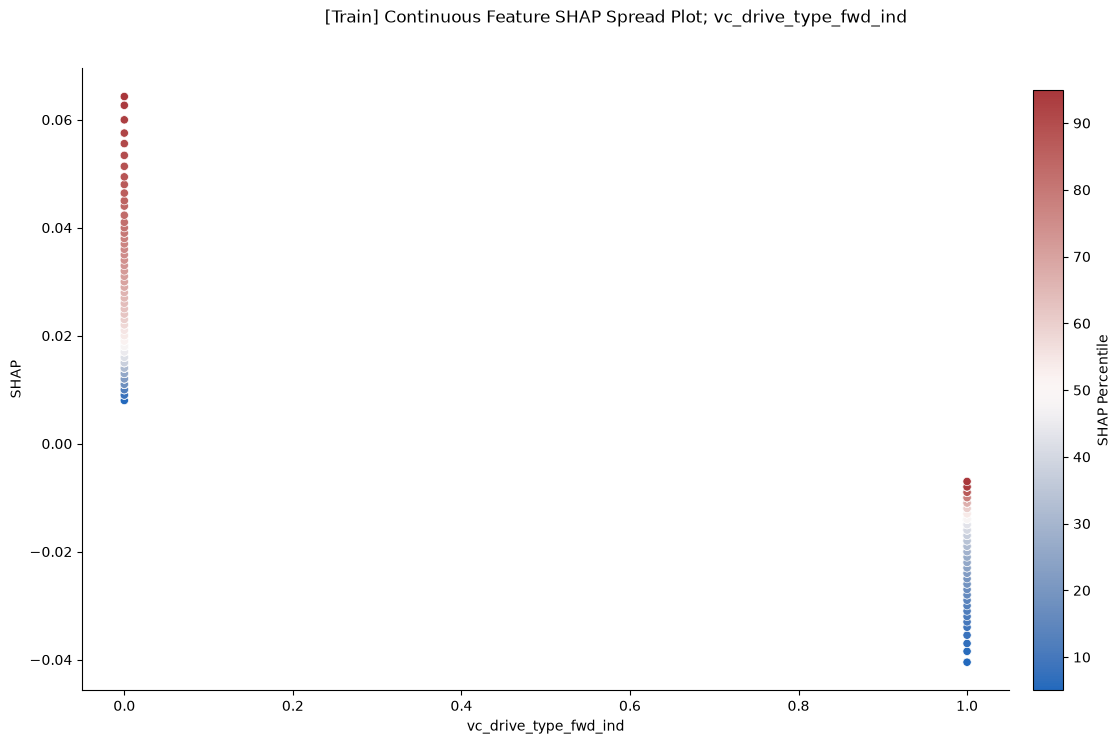

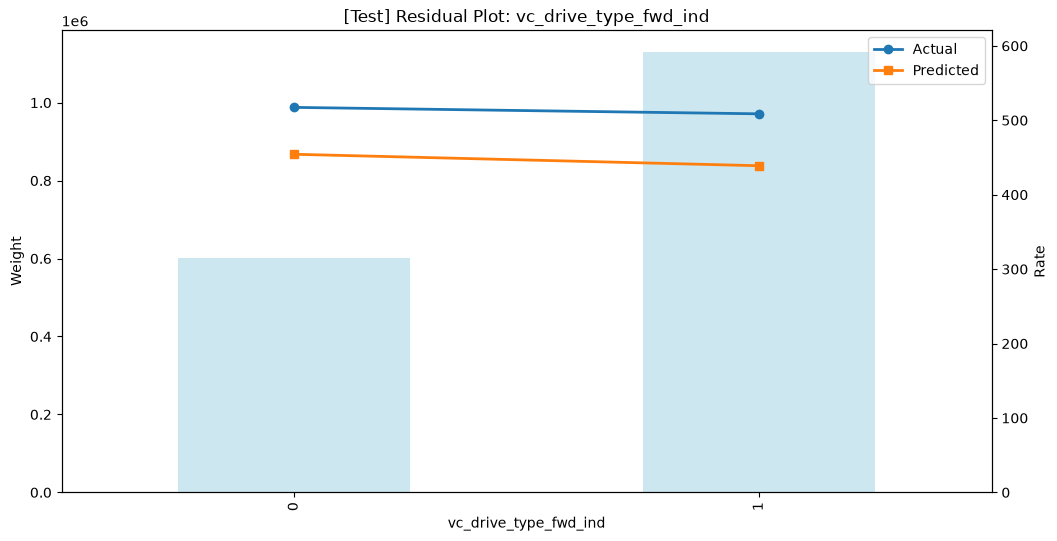

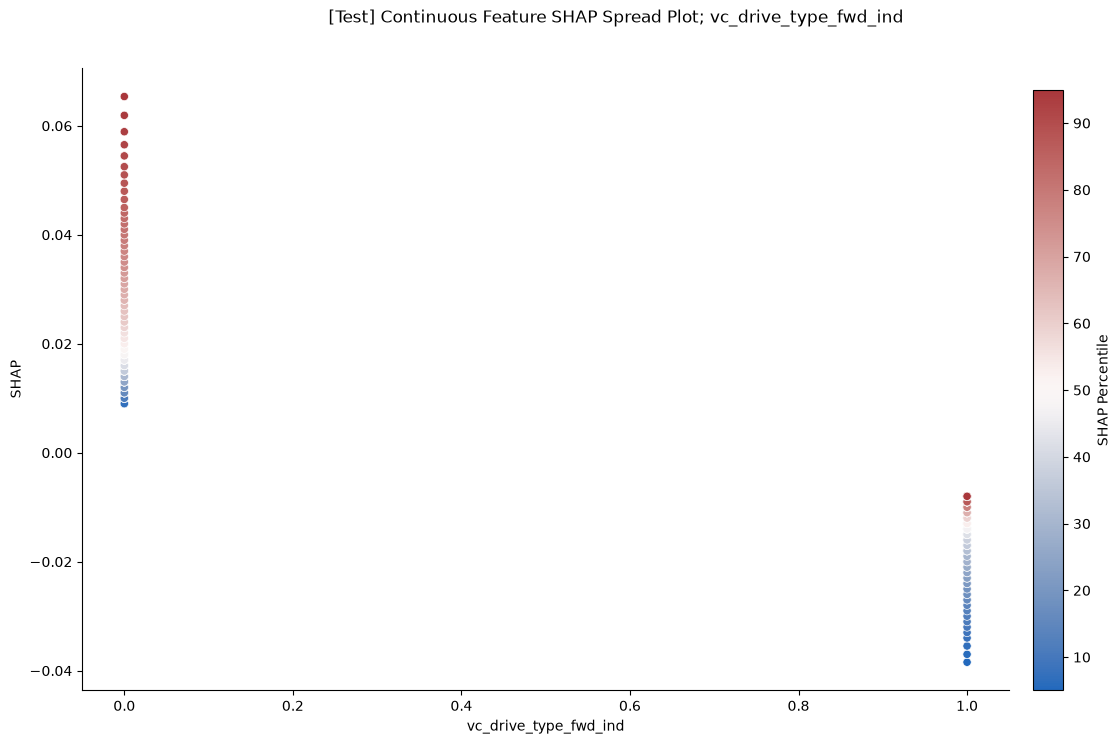


FEATURE: vc_wipers_automatic_raw


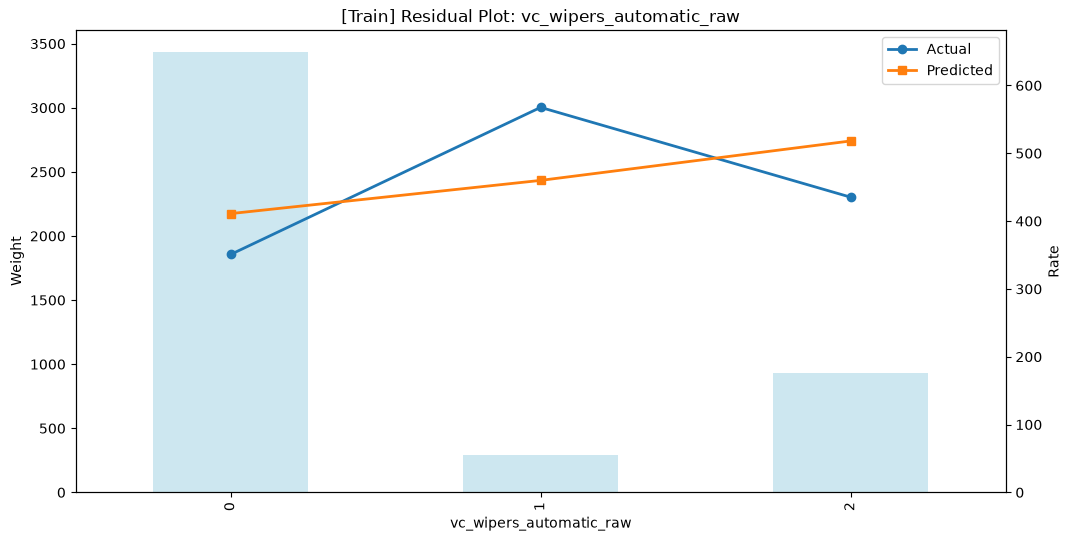

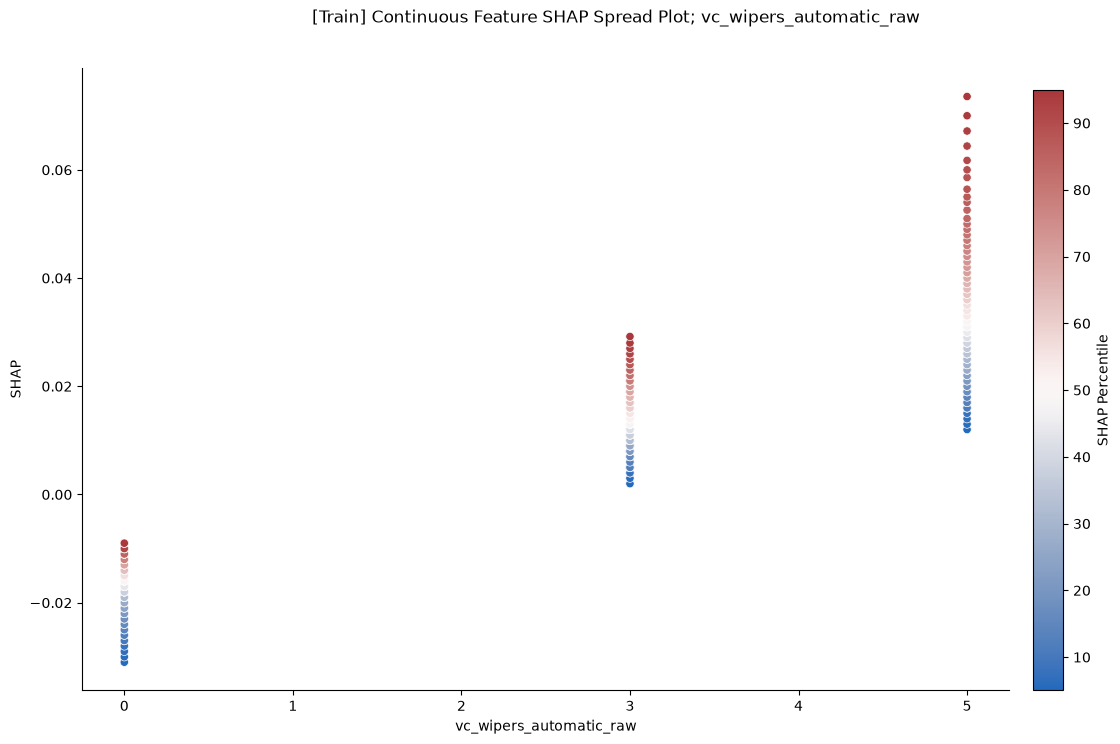

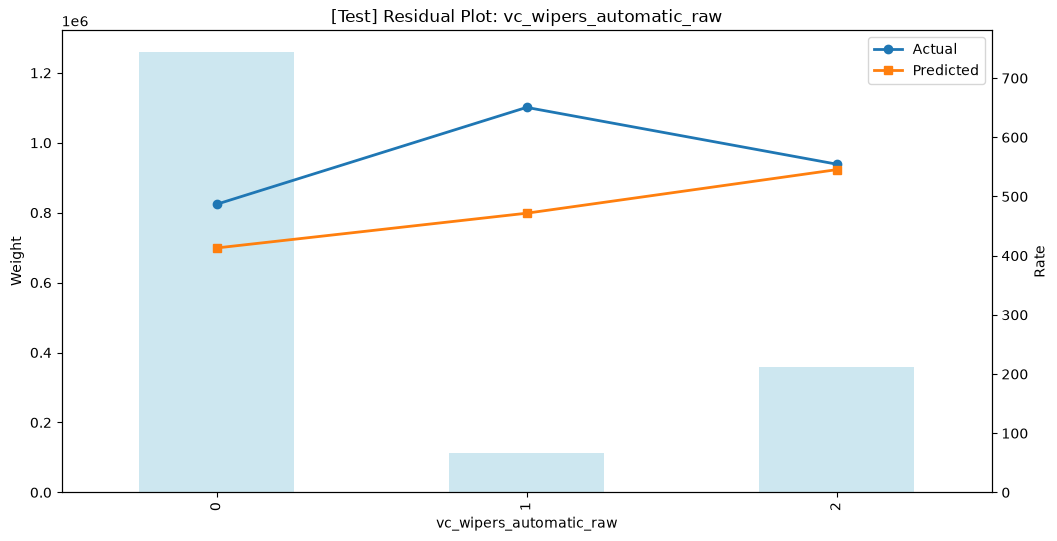

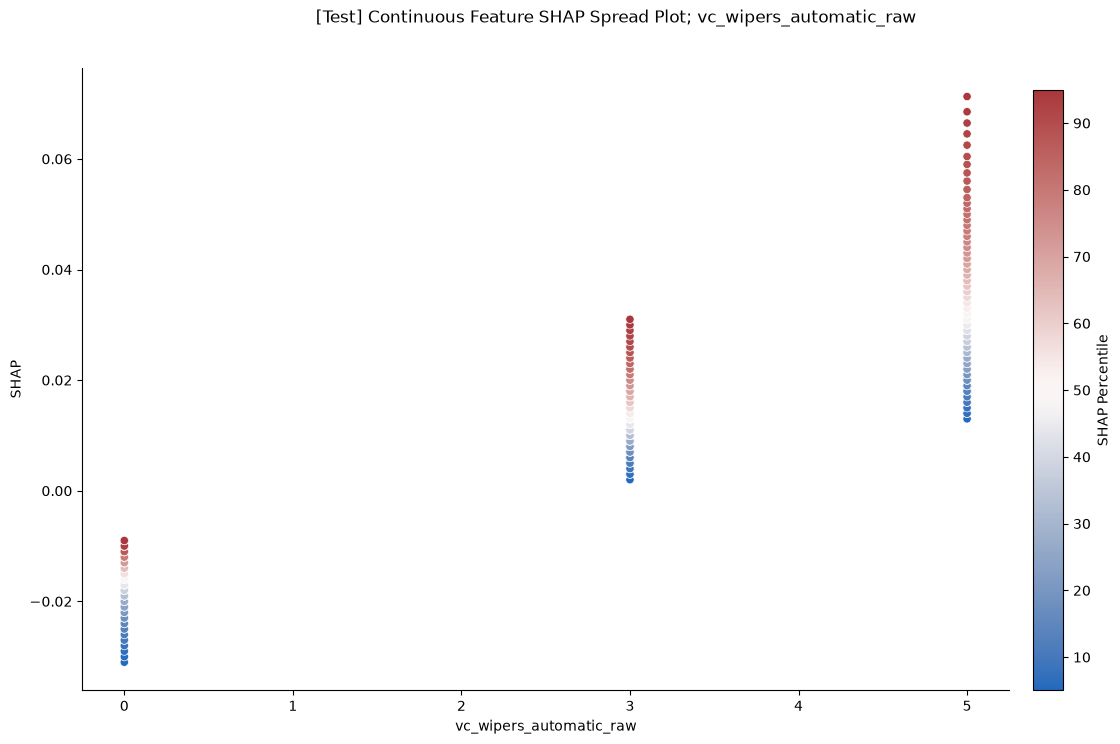


FEATURE: cef_first_sev_prob_ind


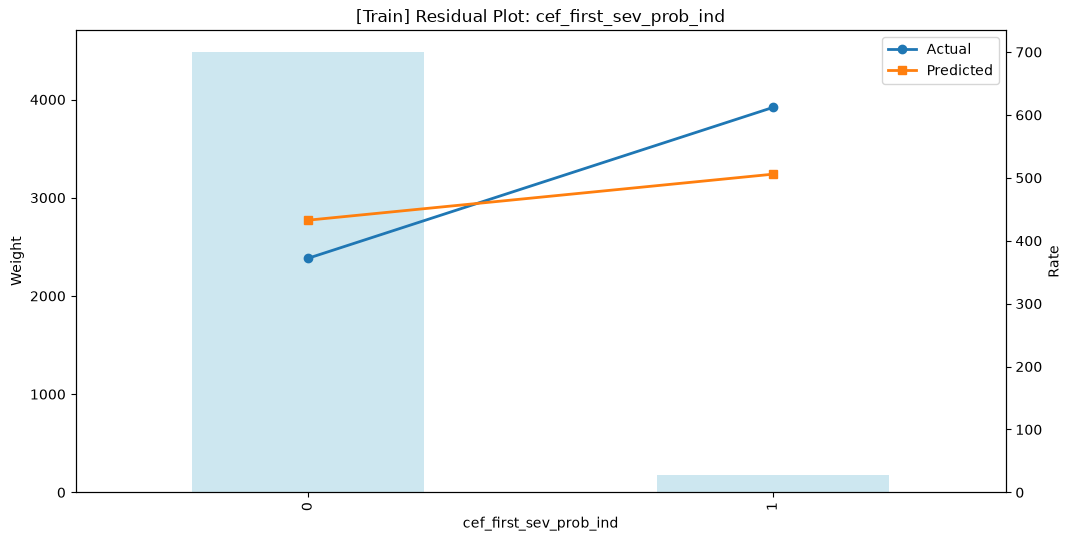

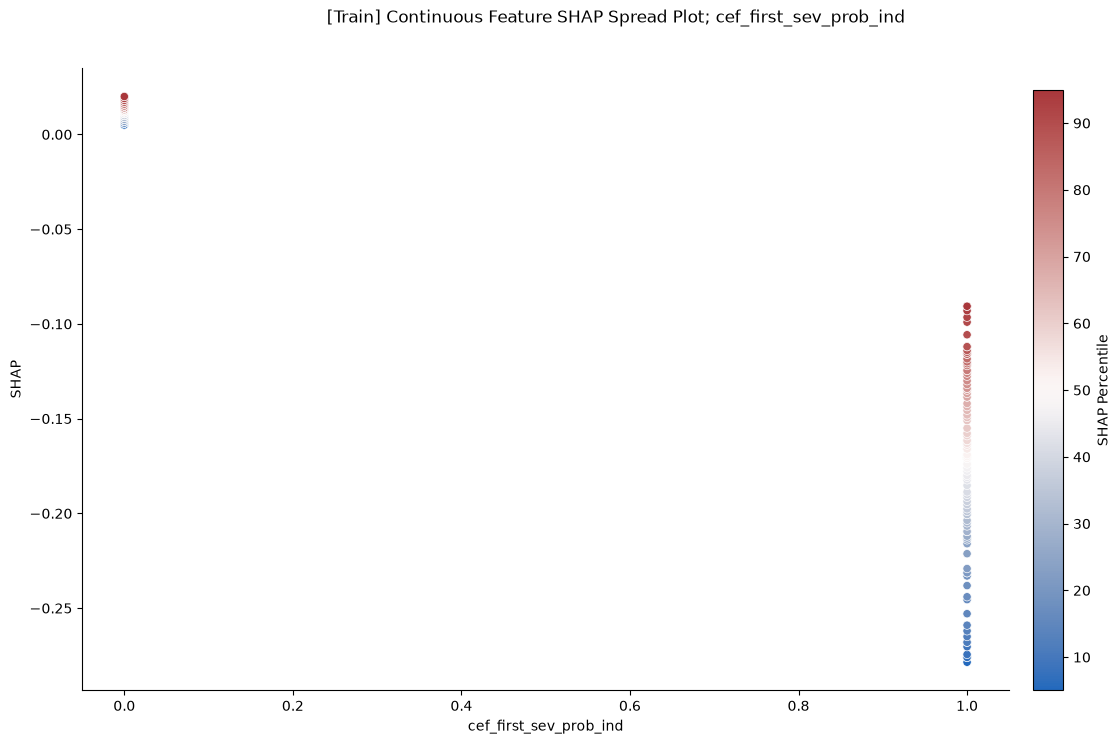

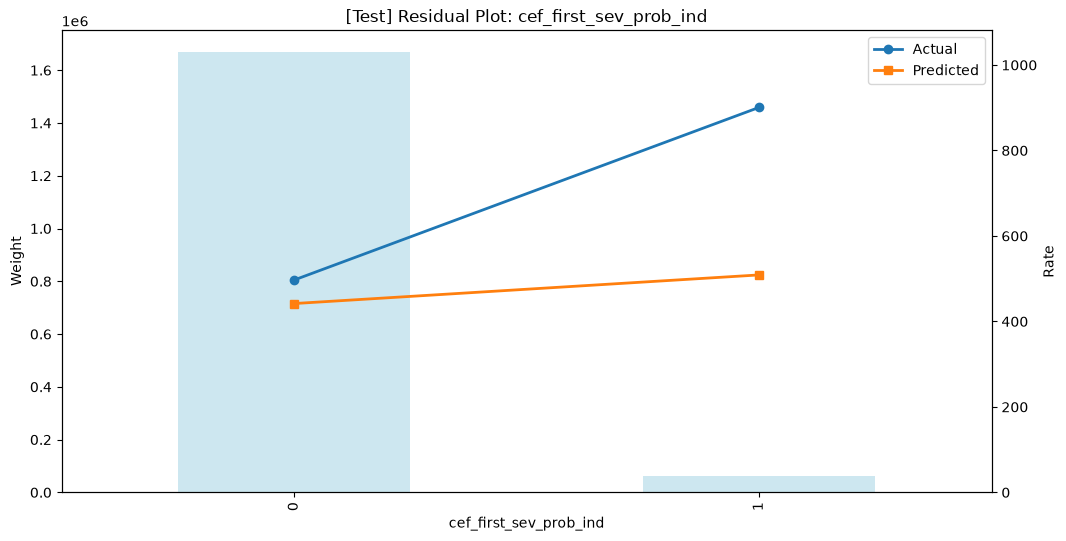

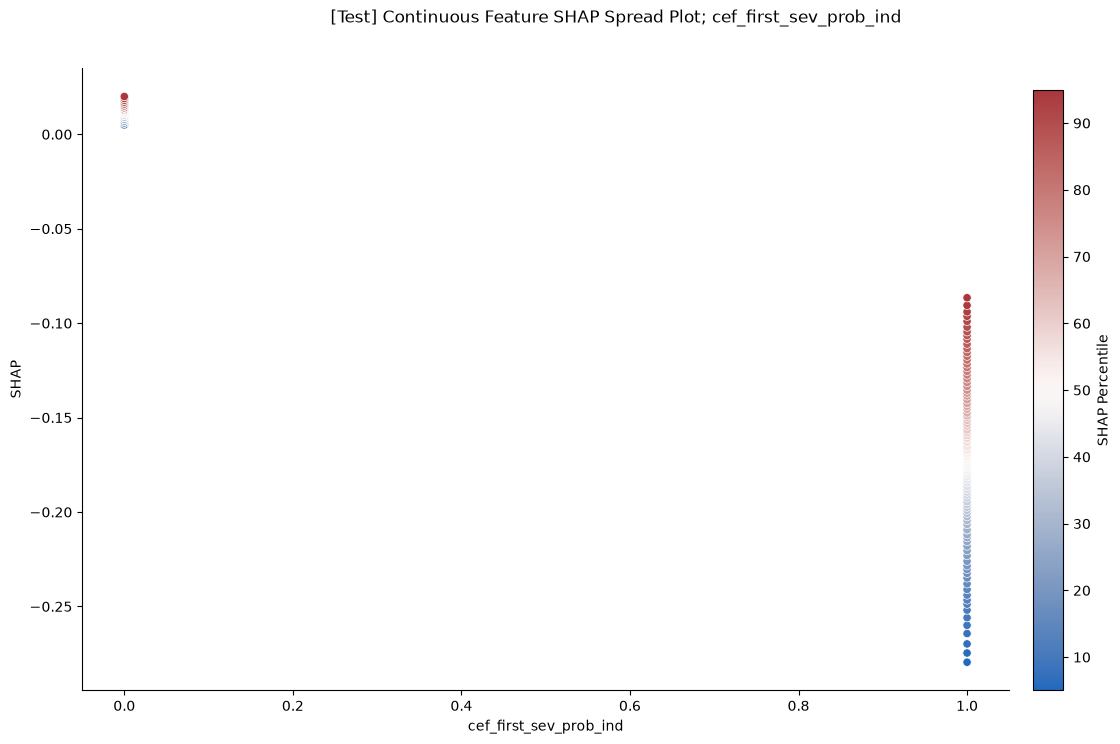


FEATURE: cef_first_branded_ind


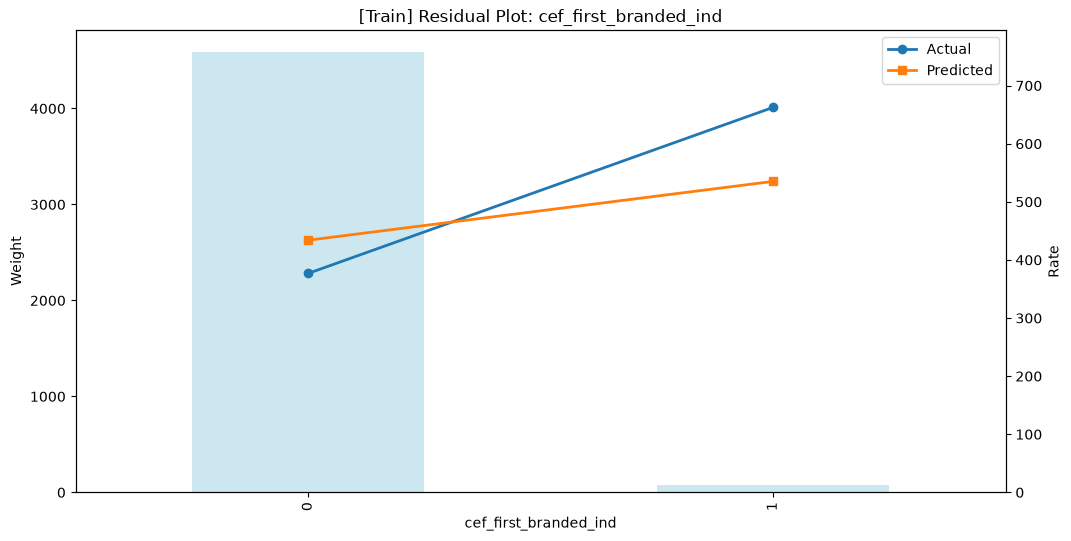

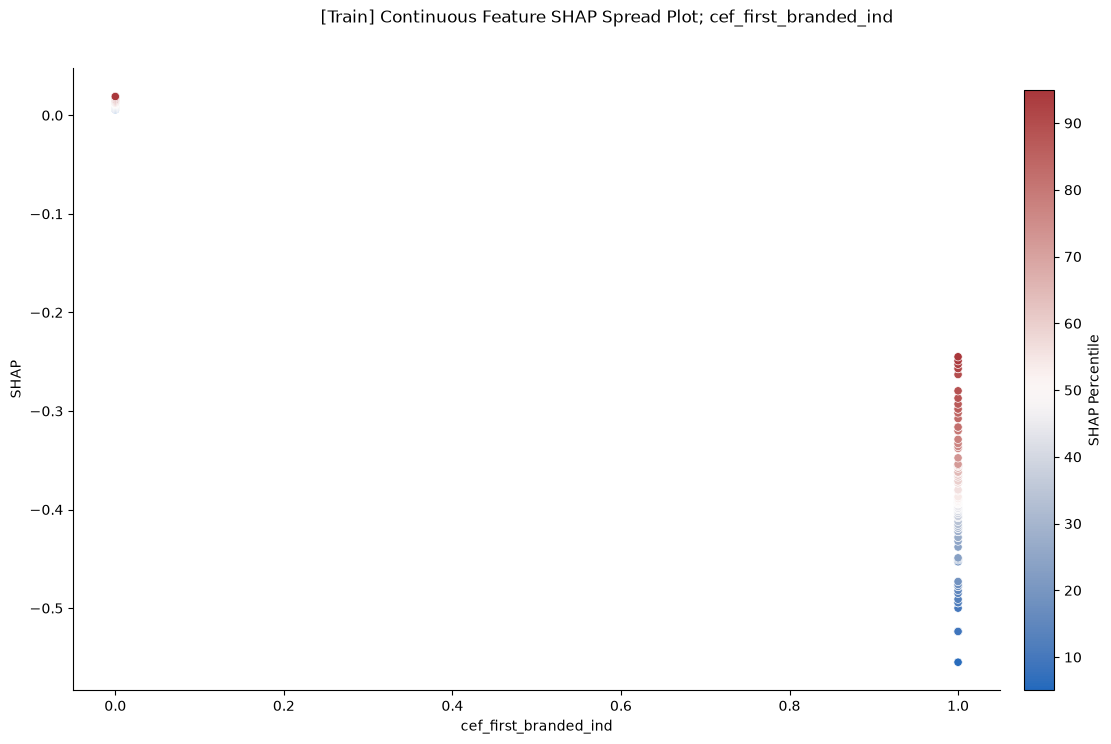

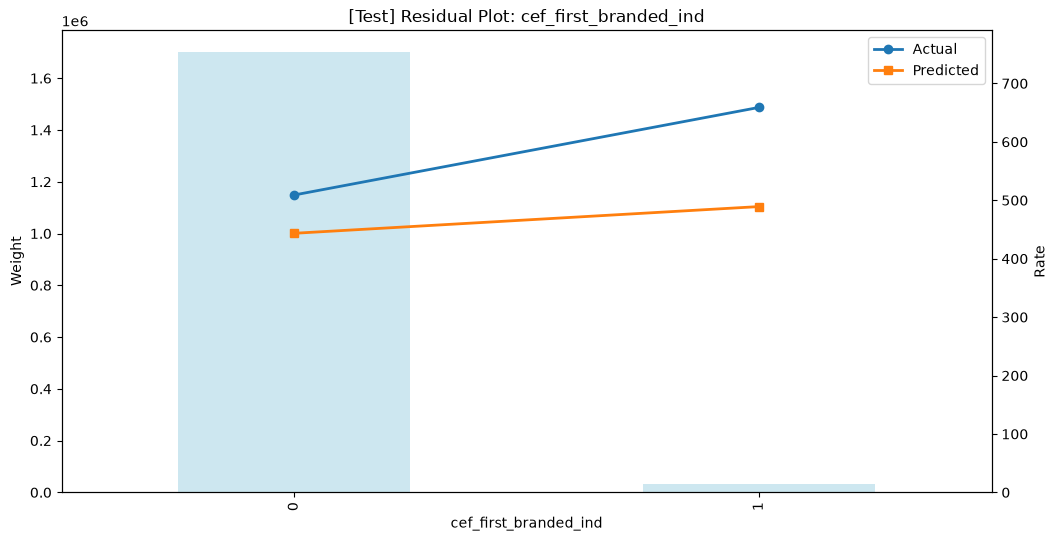

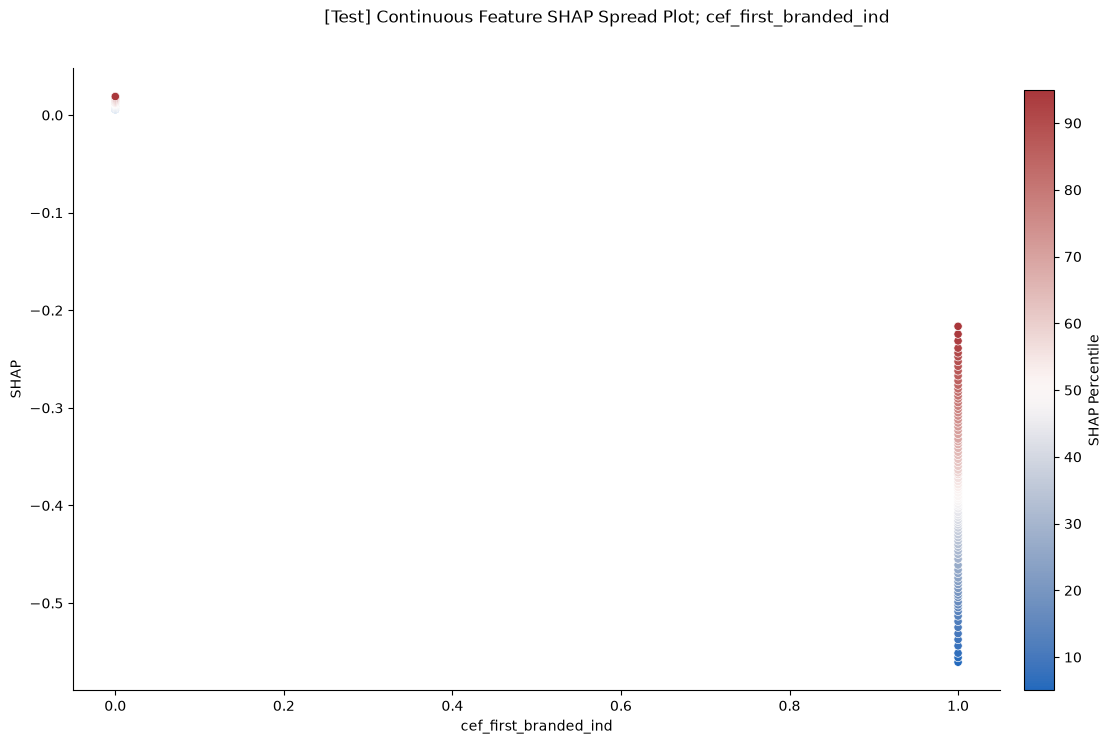


FEATURE: vc_transmission_type_automatic_ind


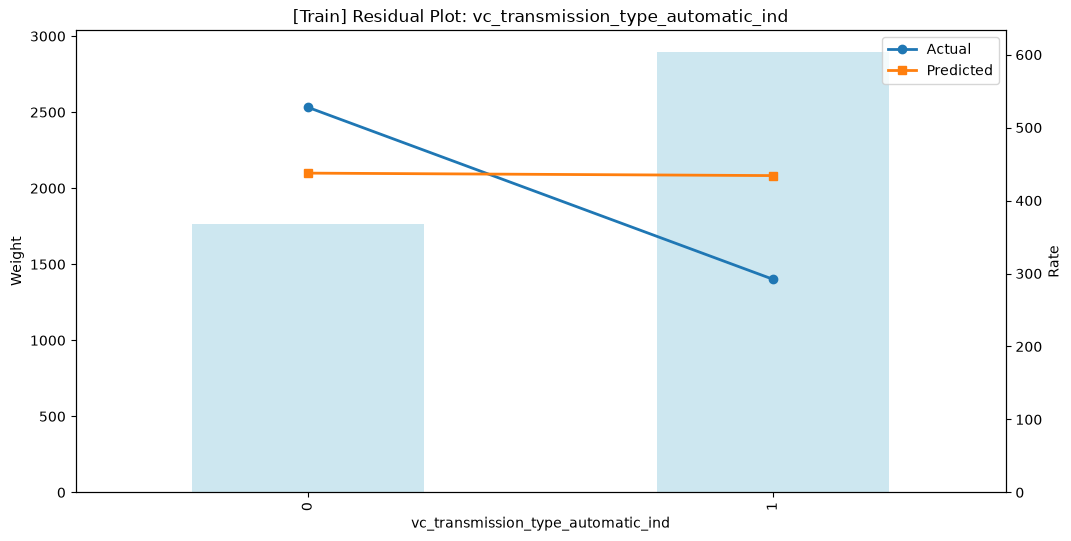

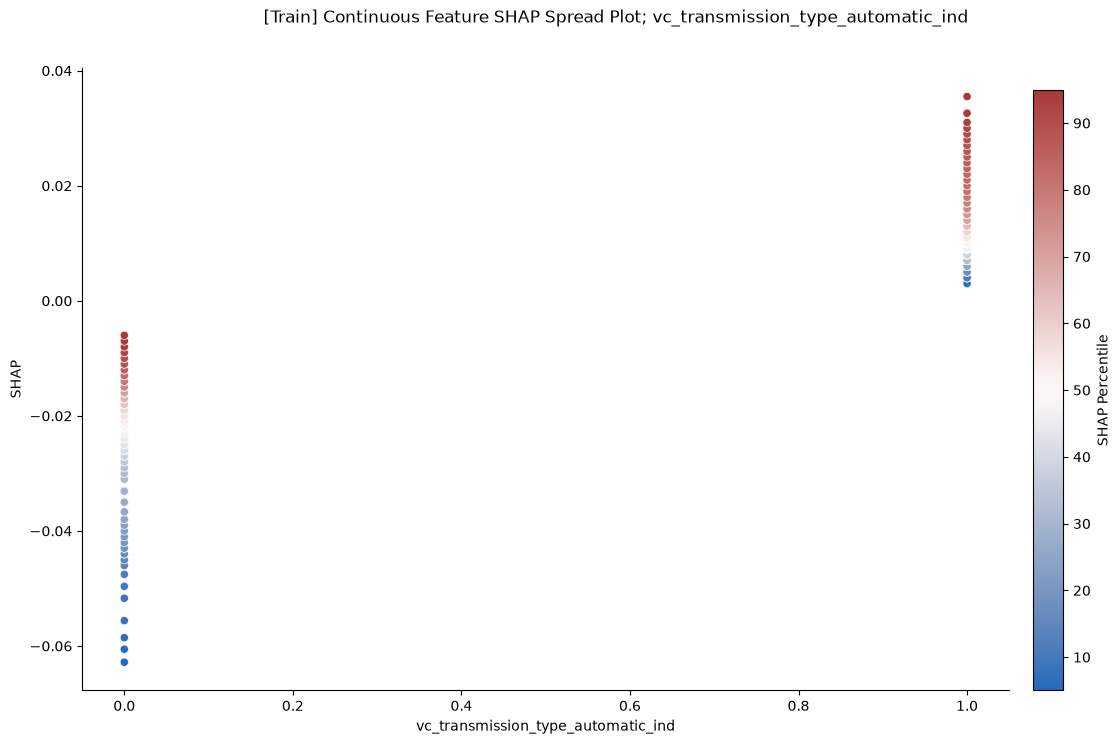

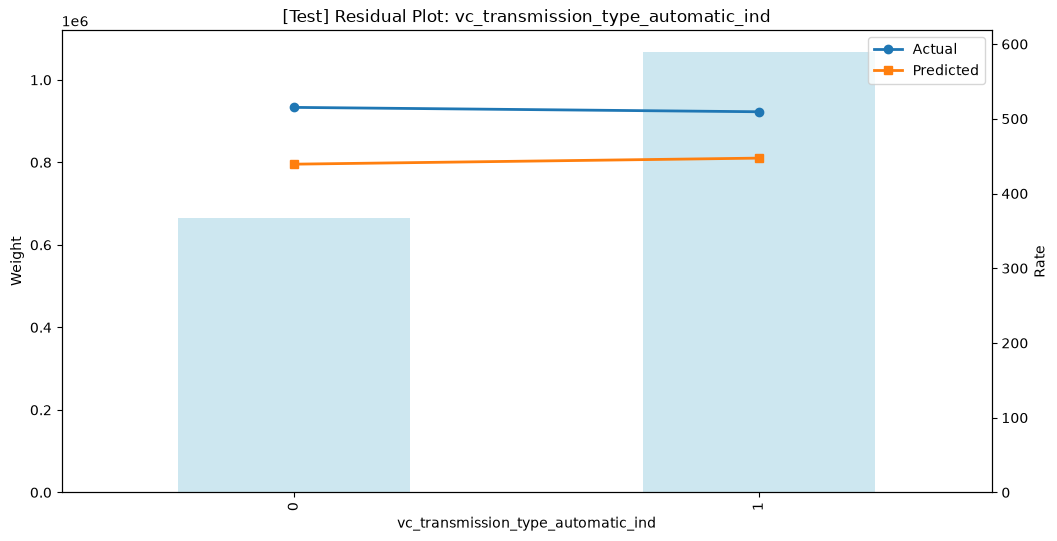

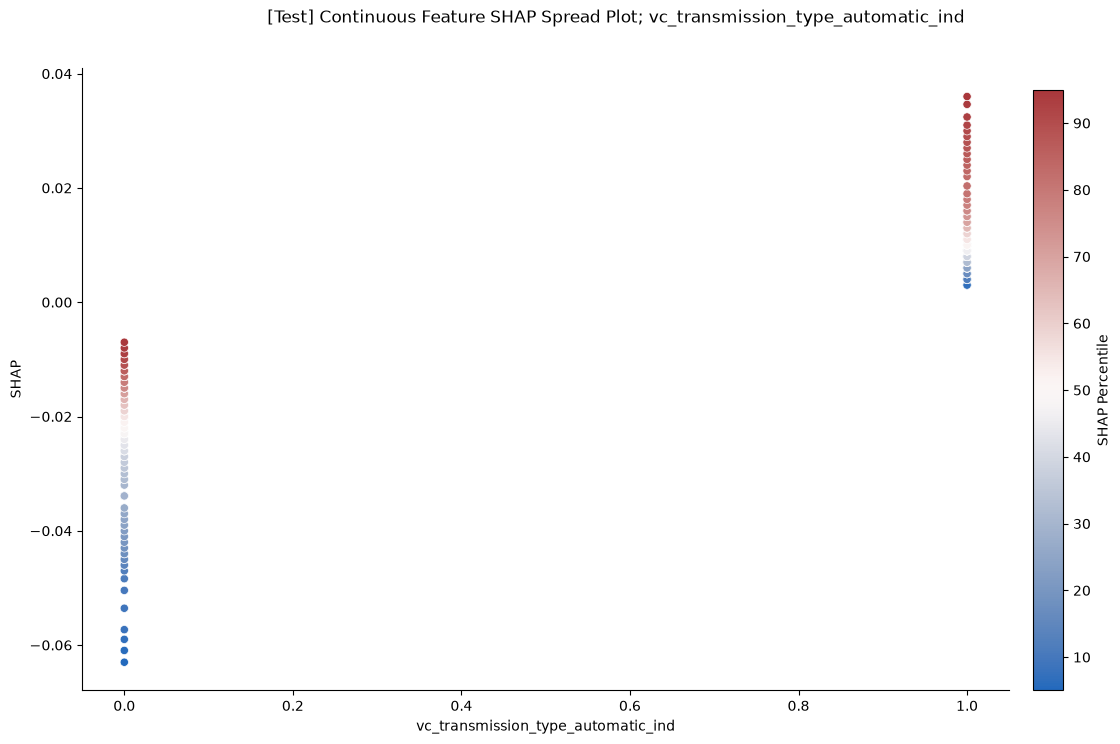


FEATURE: vc_auto_dimming_side_mirrors_raw


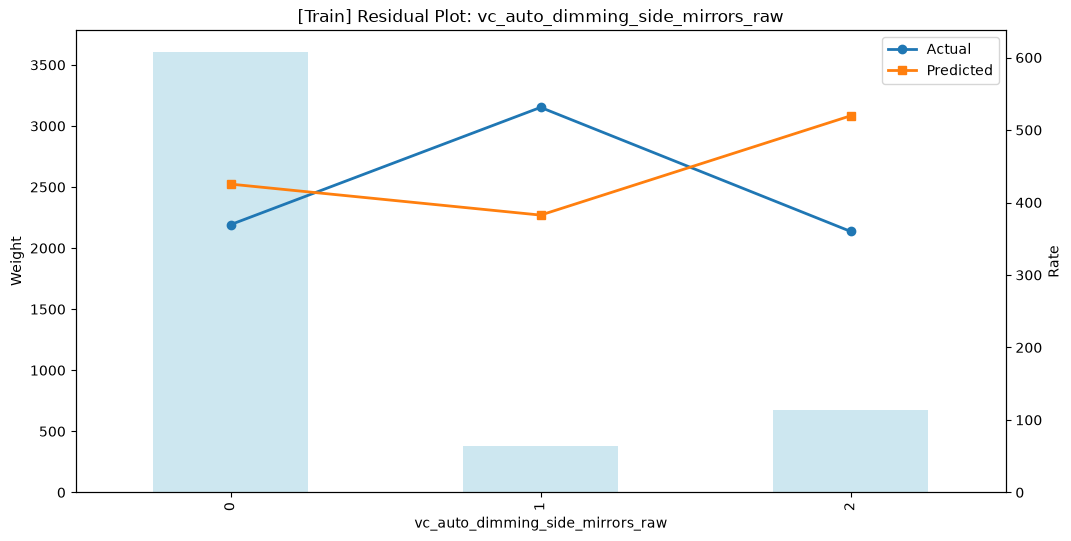

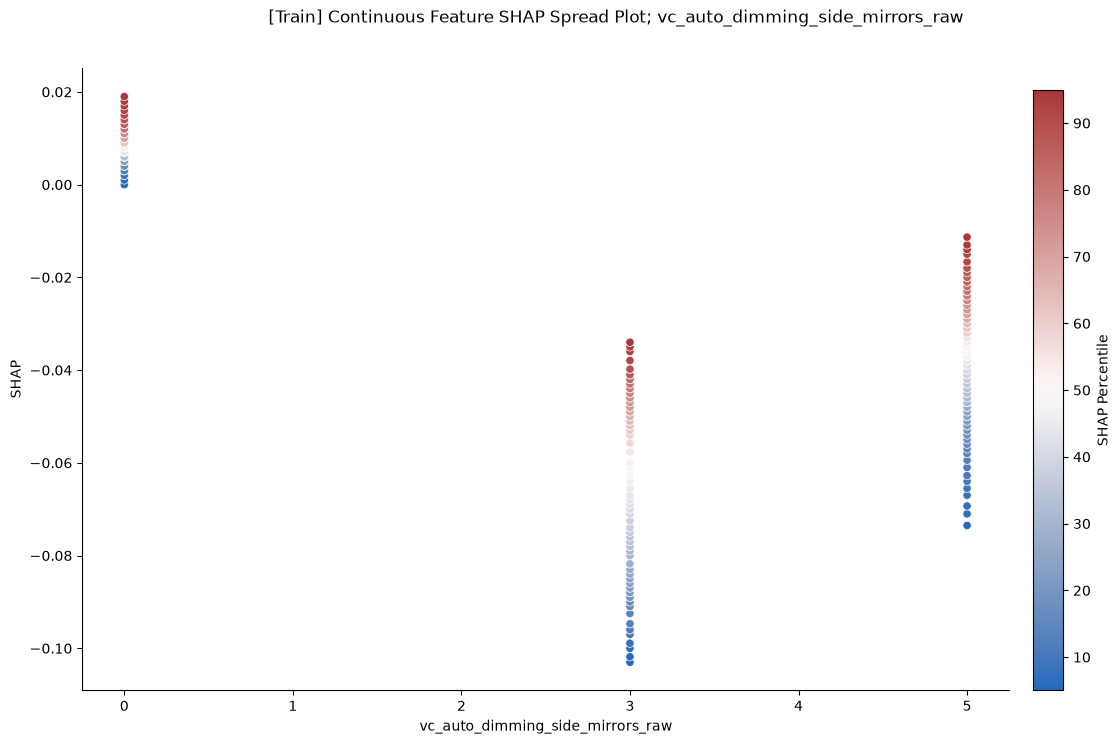

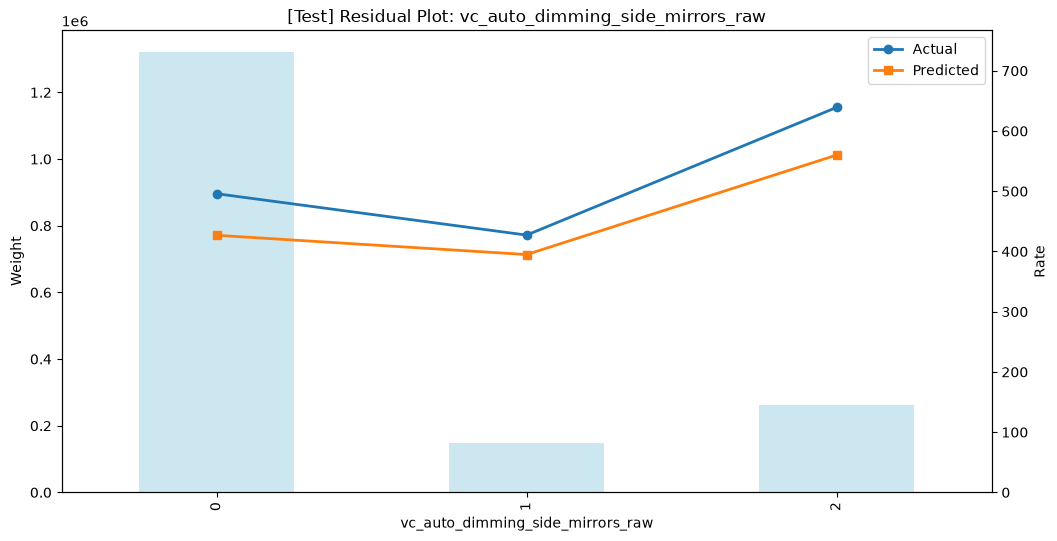

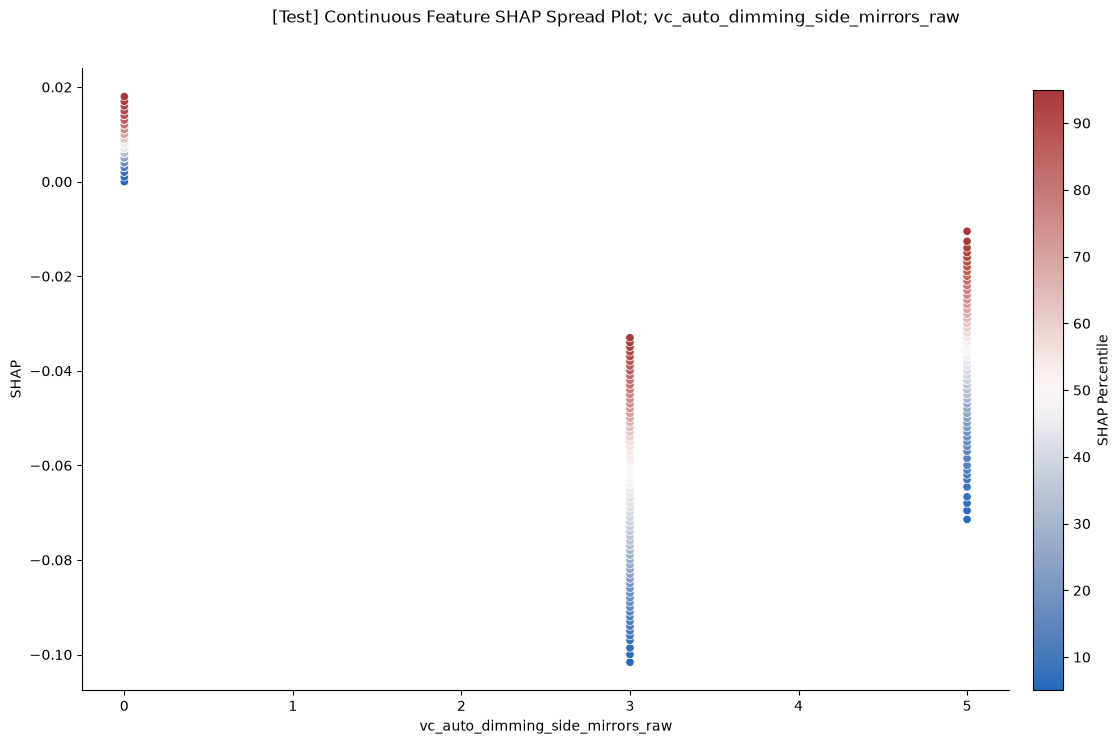


FEATURE: vc_forward_automatic_emergency_braking_raw


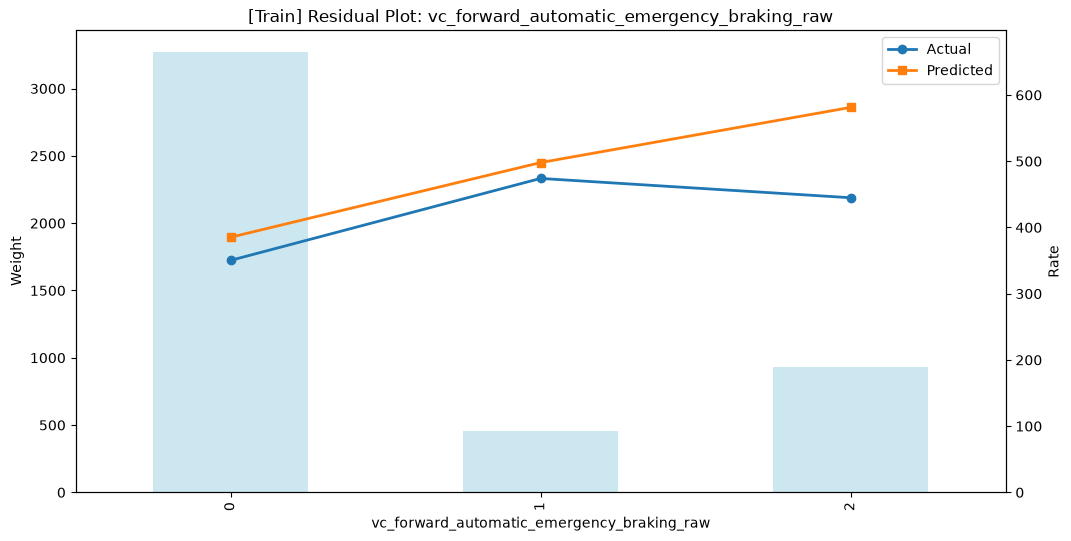

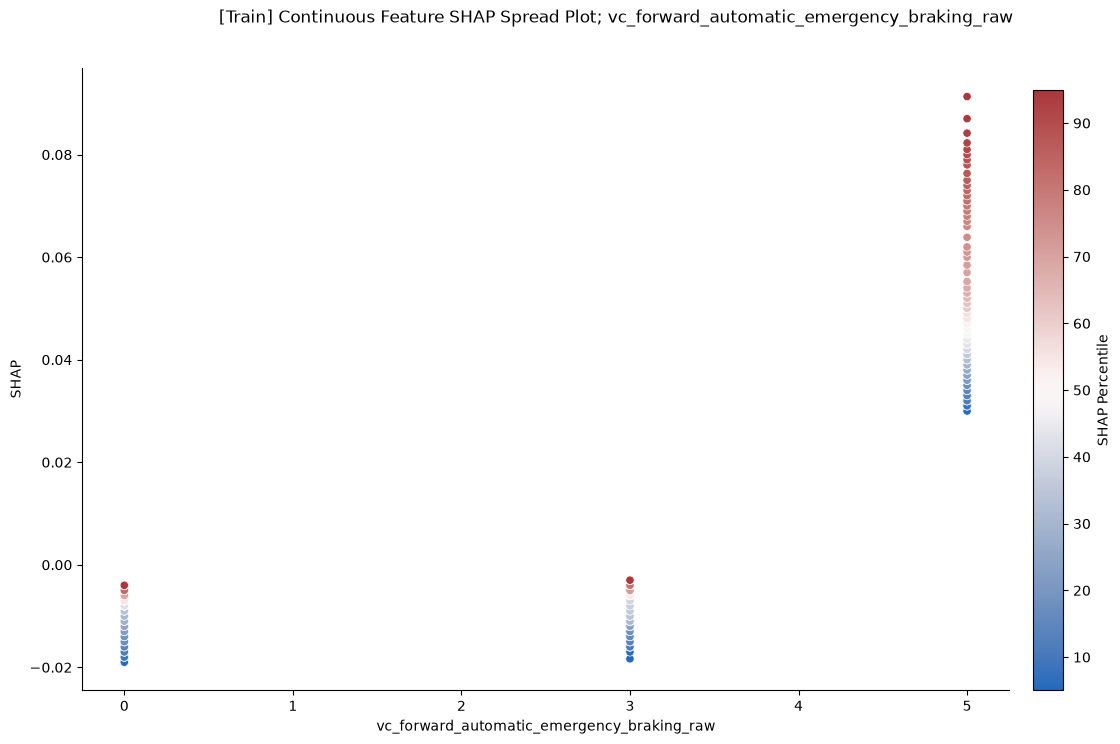

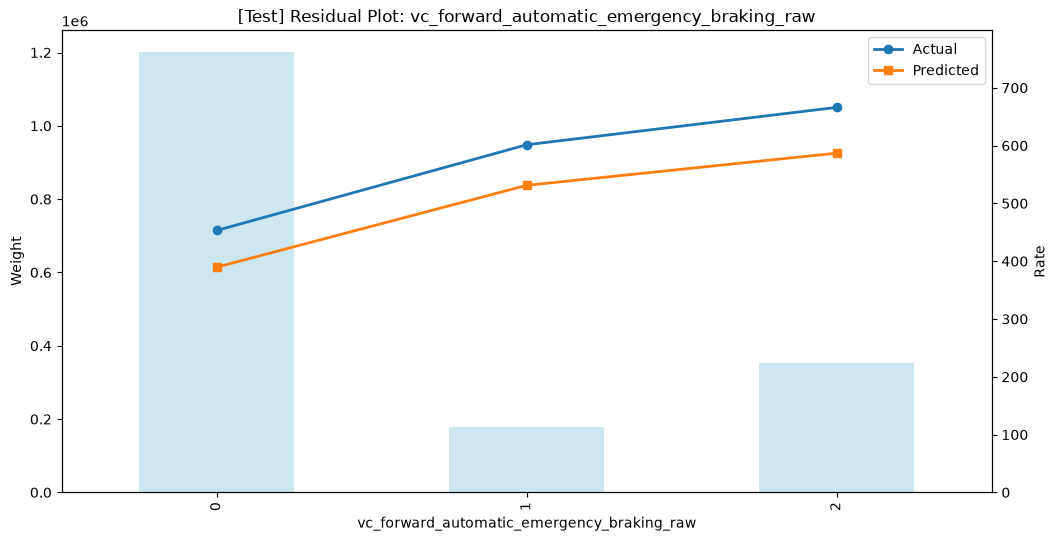

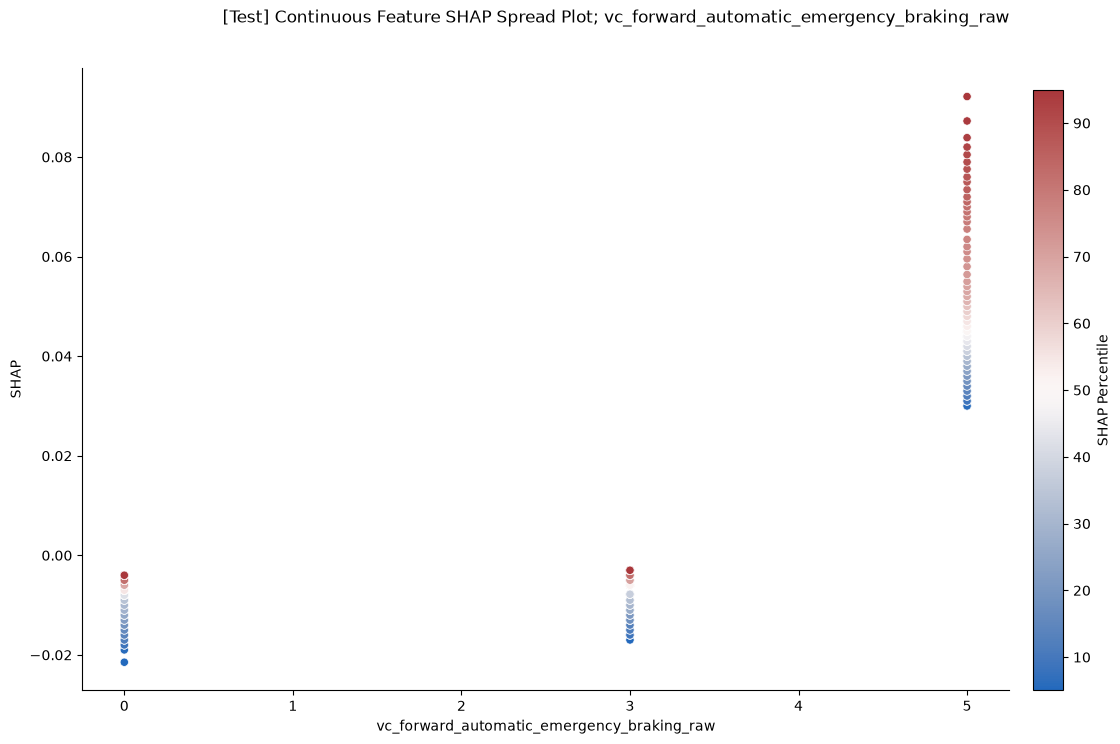


FEATURE: vc_power_sunroof_raw


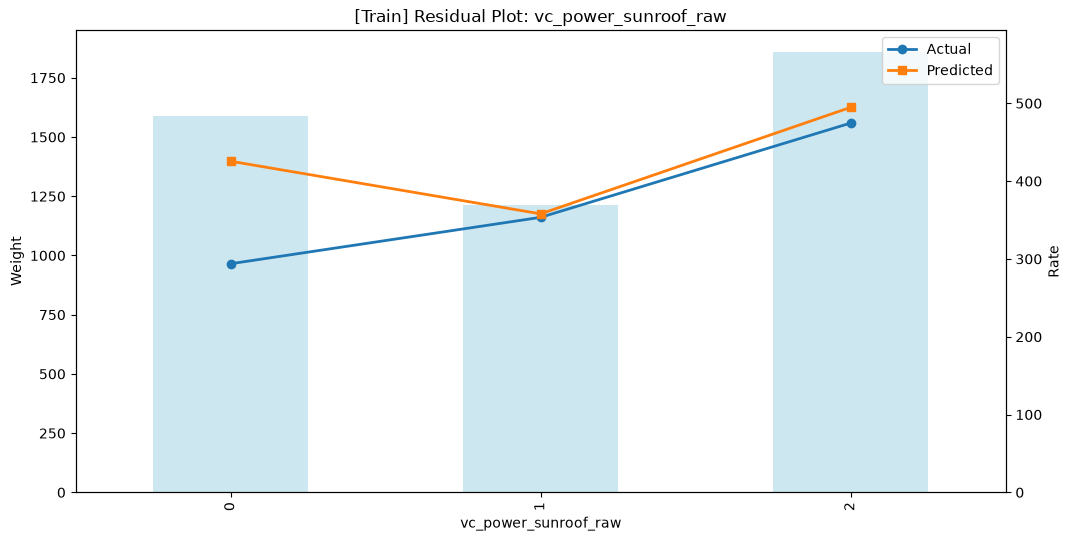

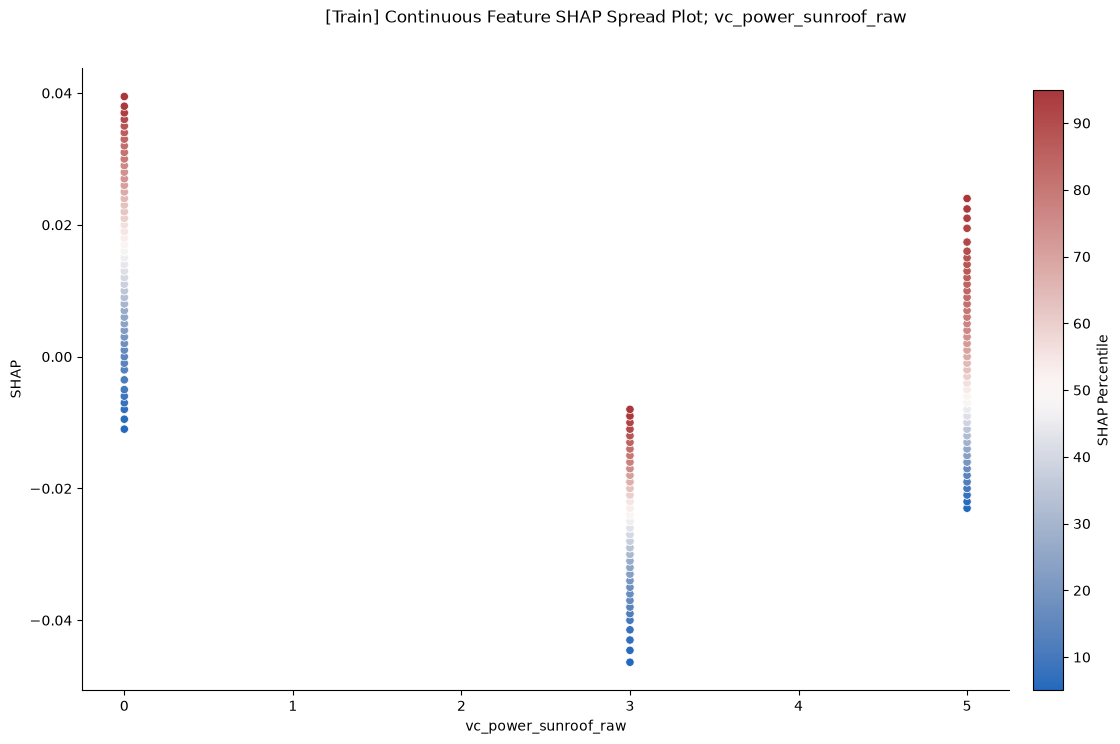

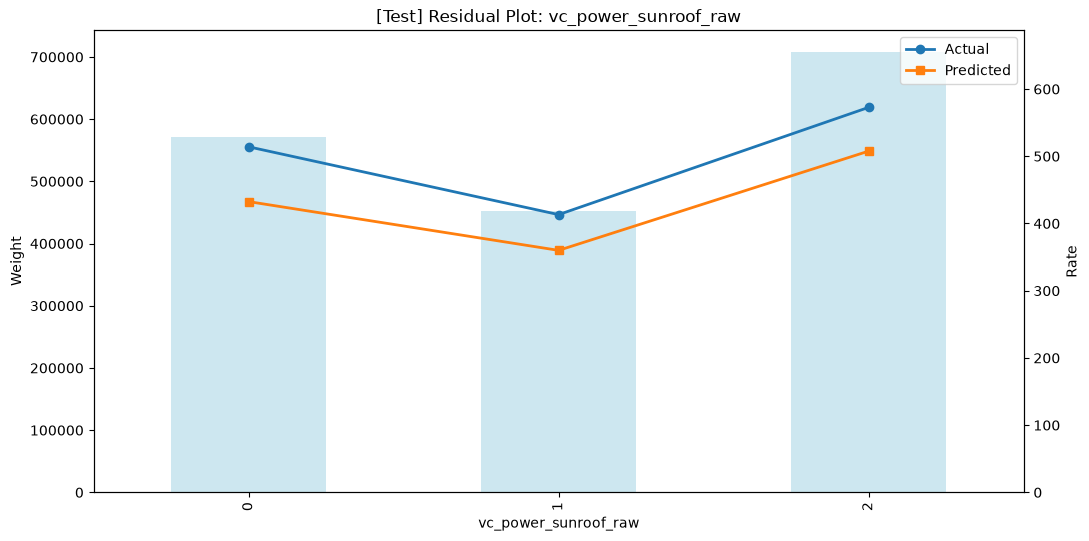

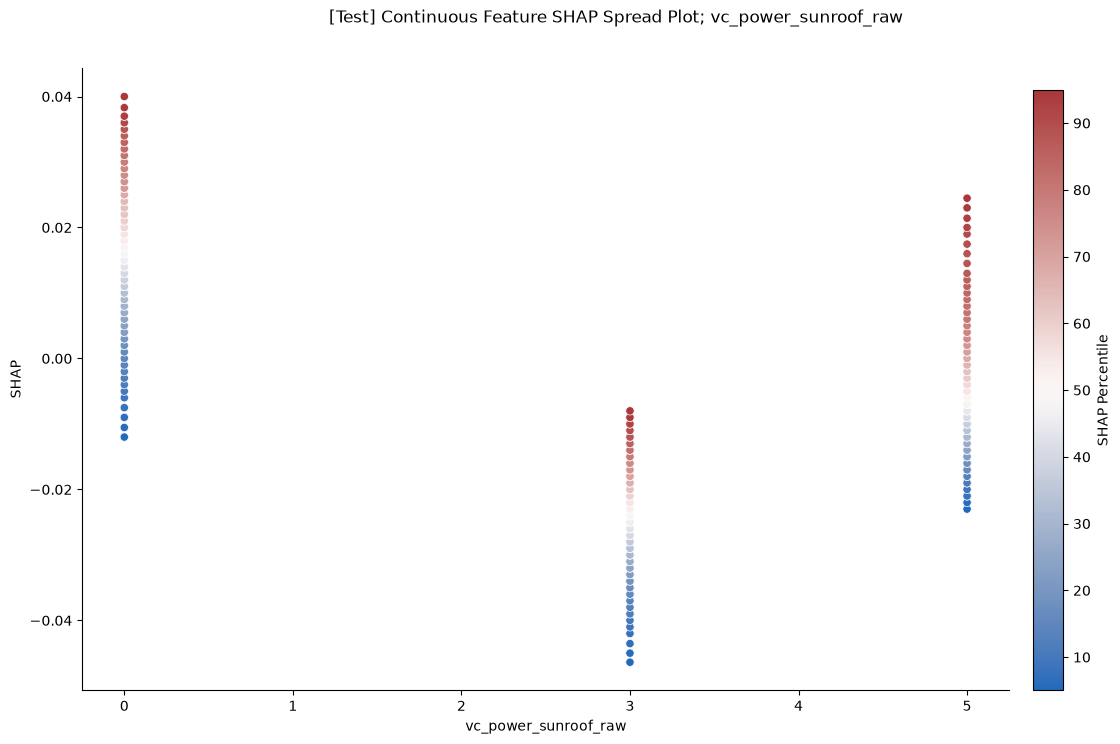


FEATURE: vc_heated_side_mirrors_raw


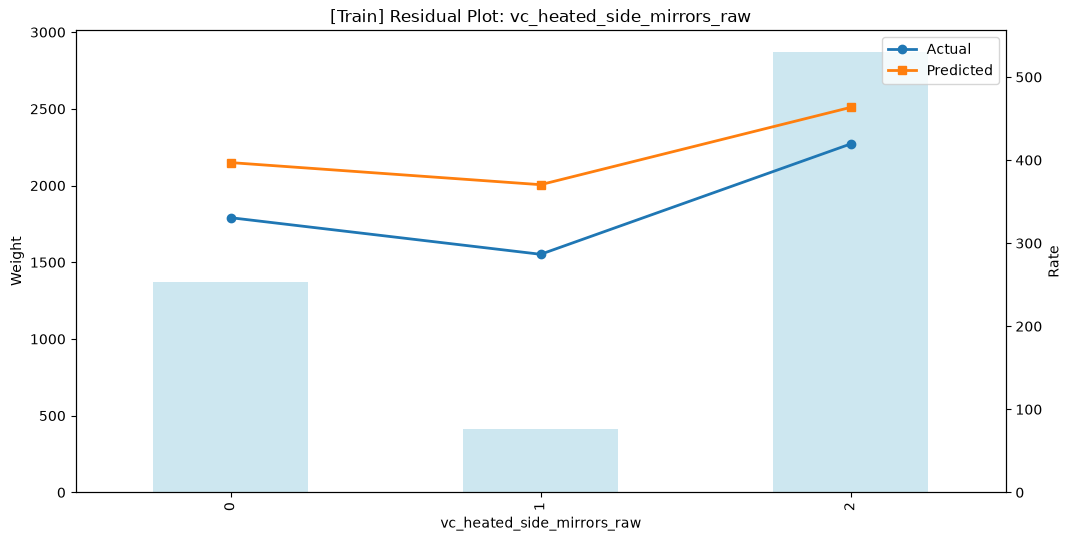

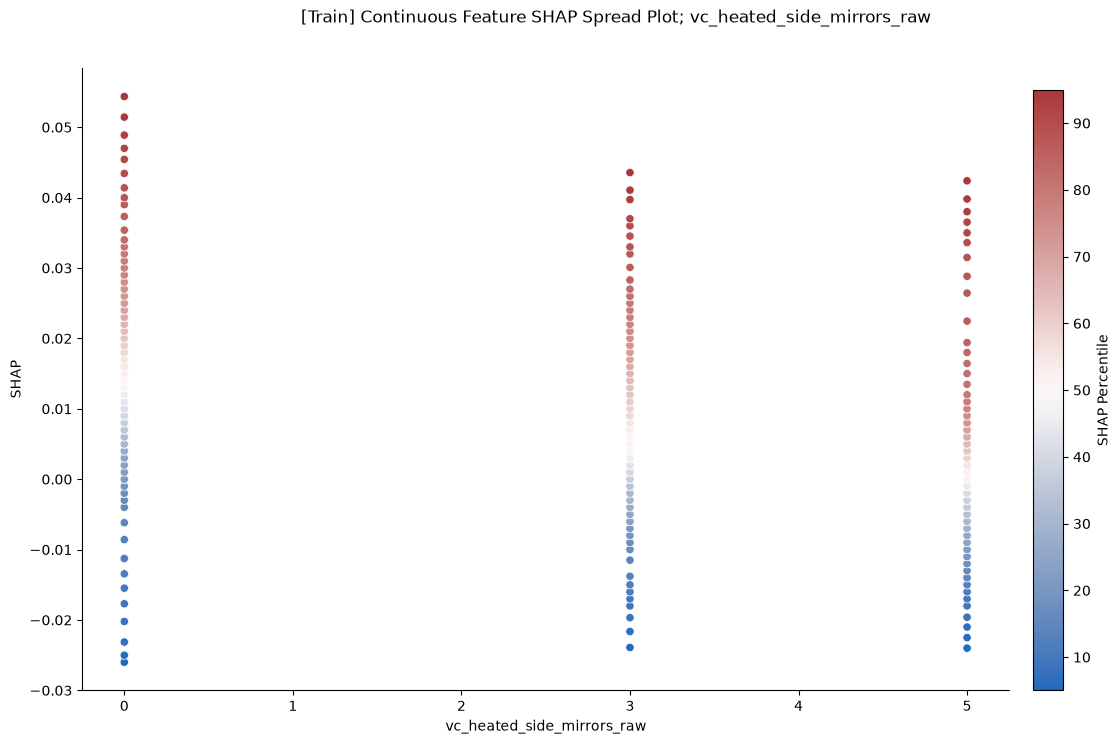

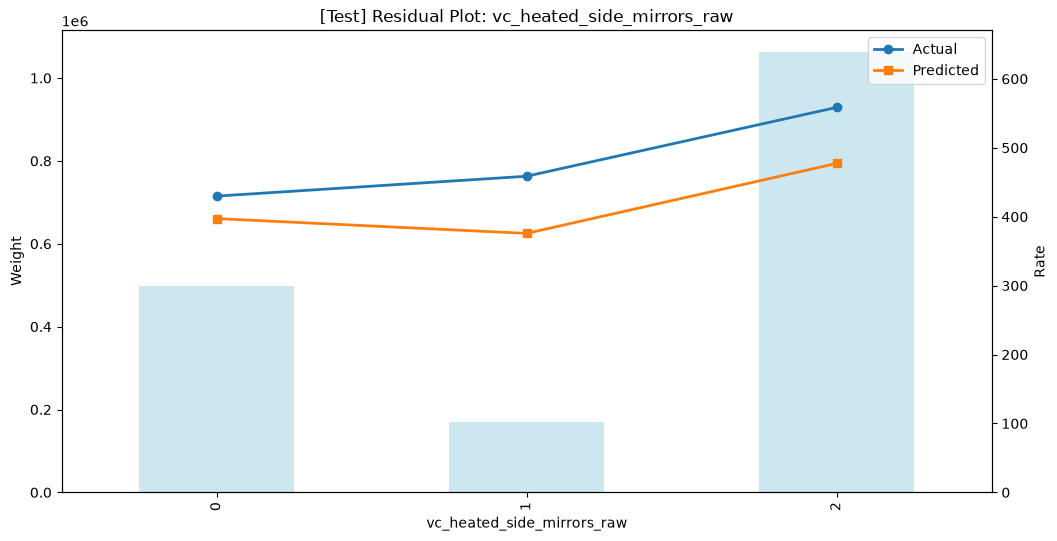

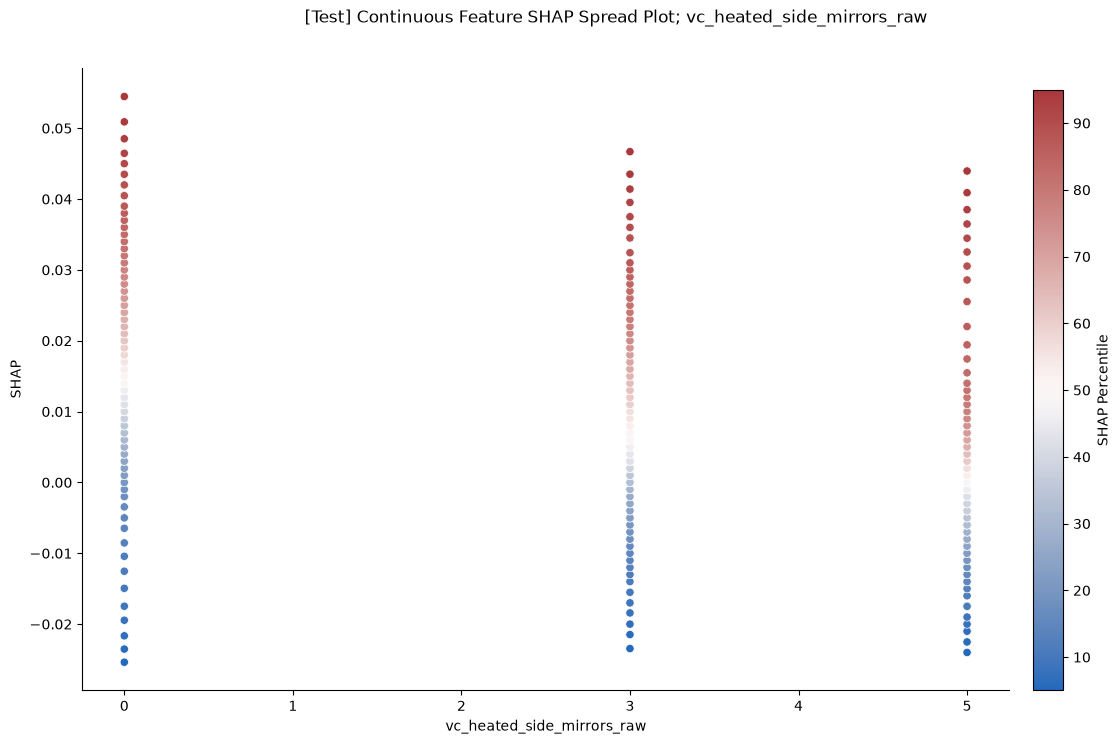


FEATURE: vc_adaptive_cruise_control_raw


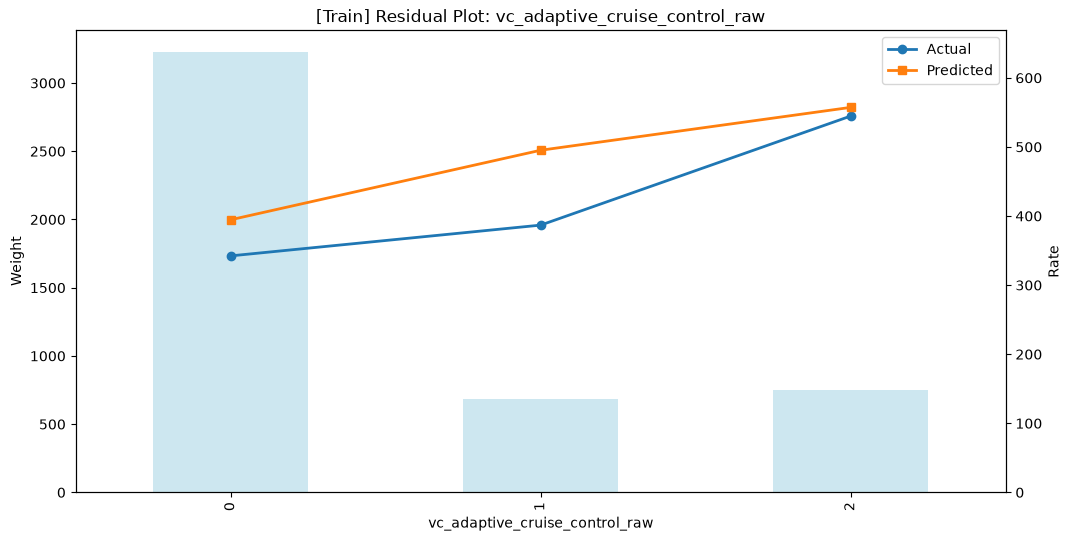

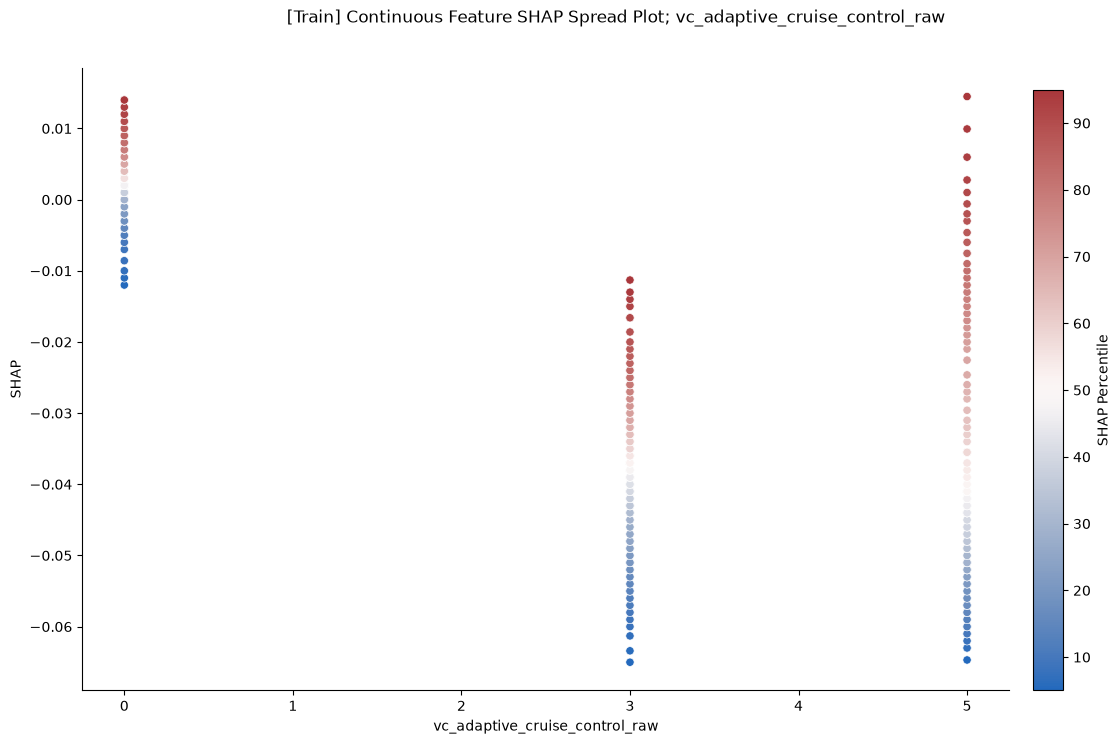

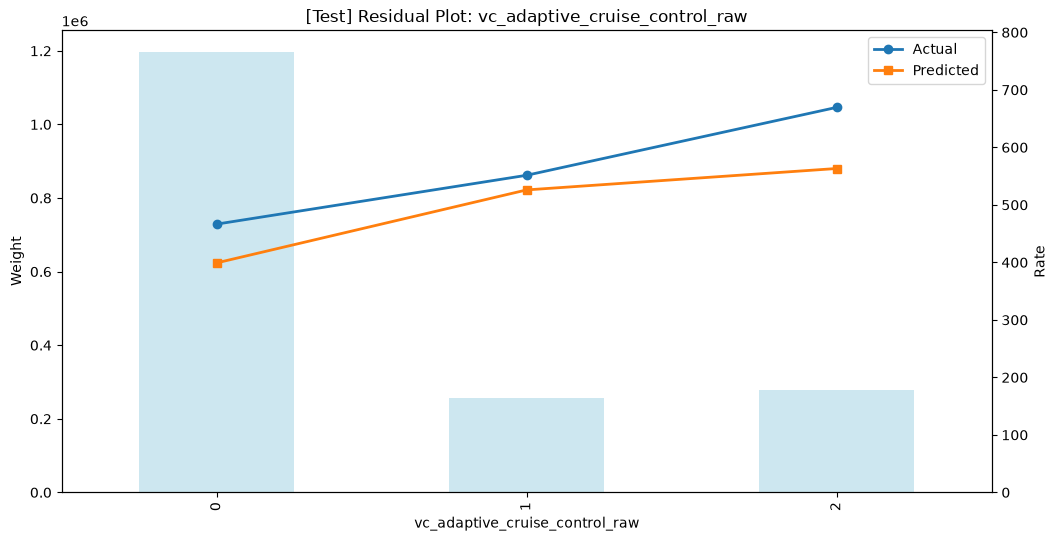

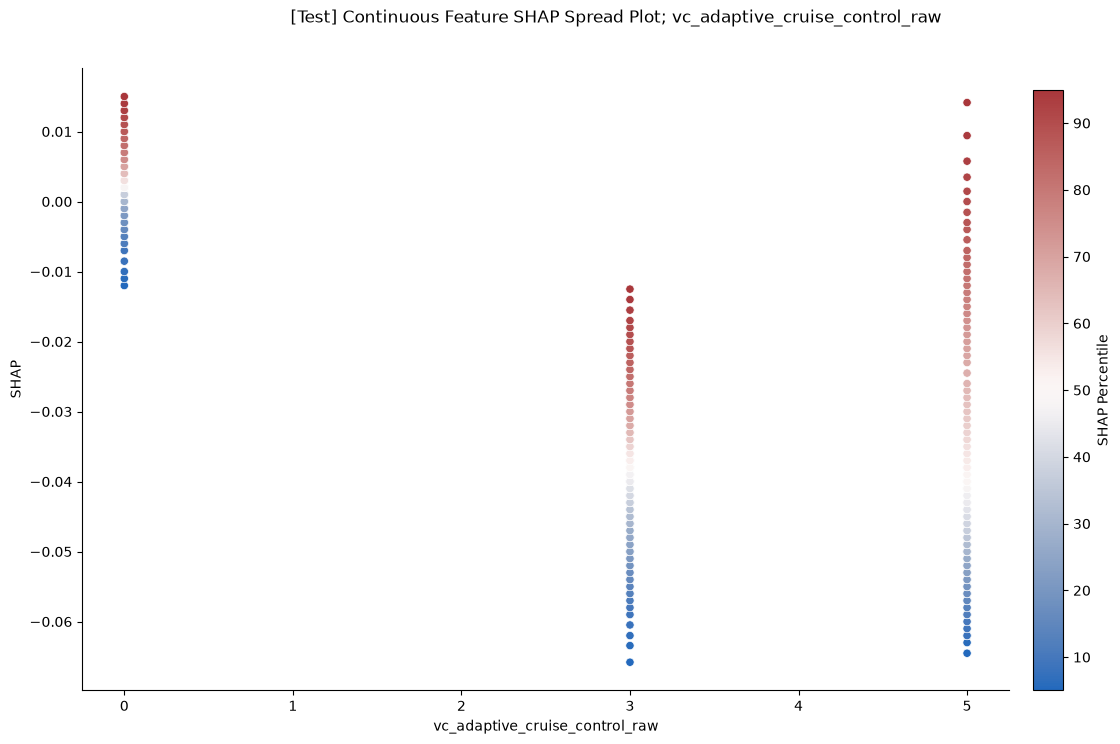


FEATURE: veh_use_commute_ind


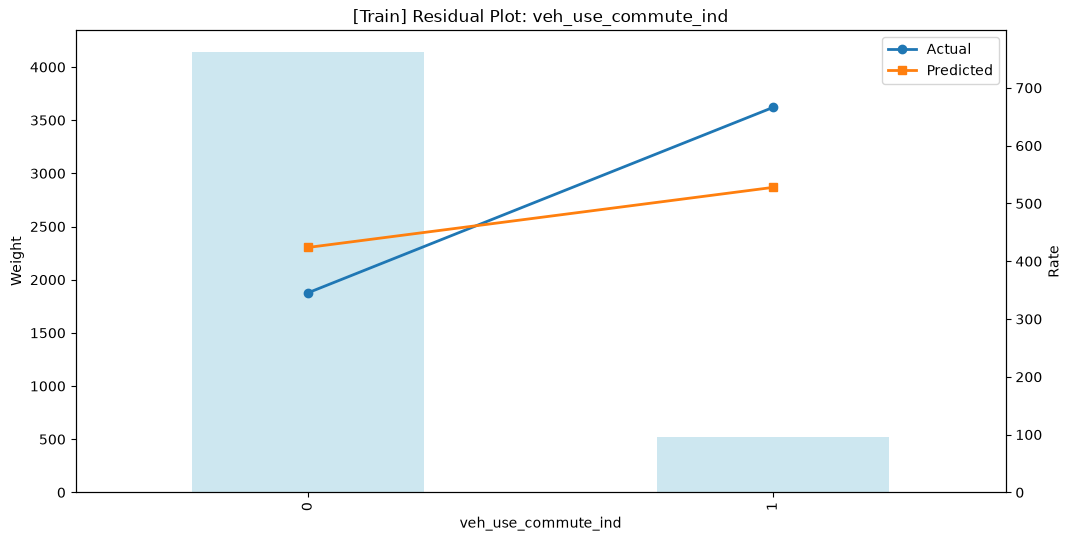

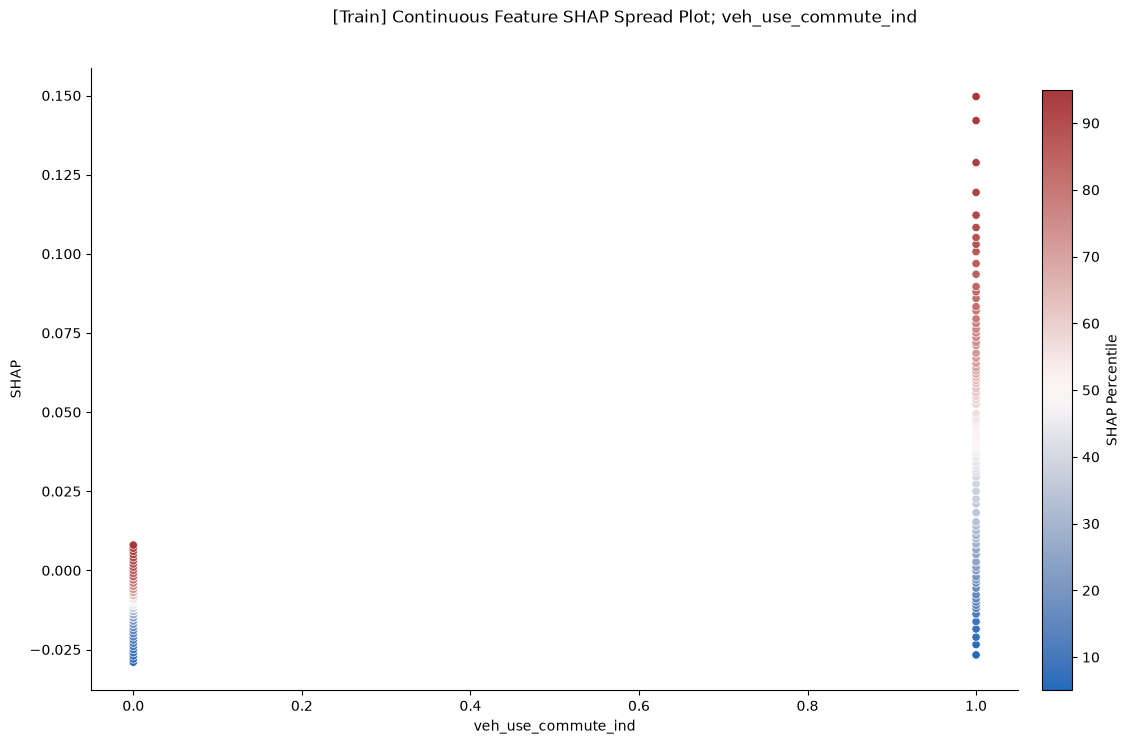

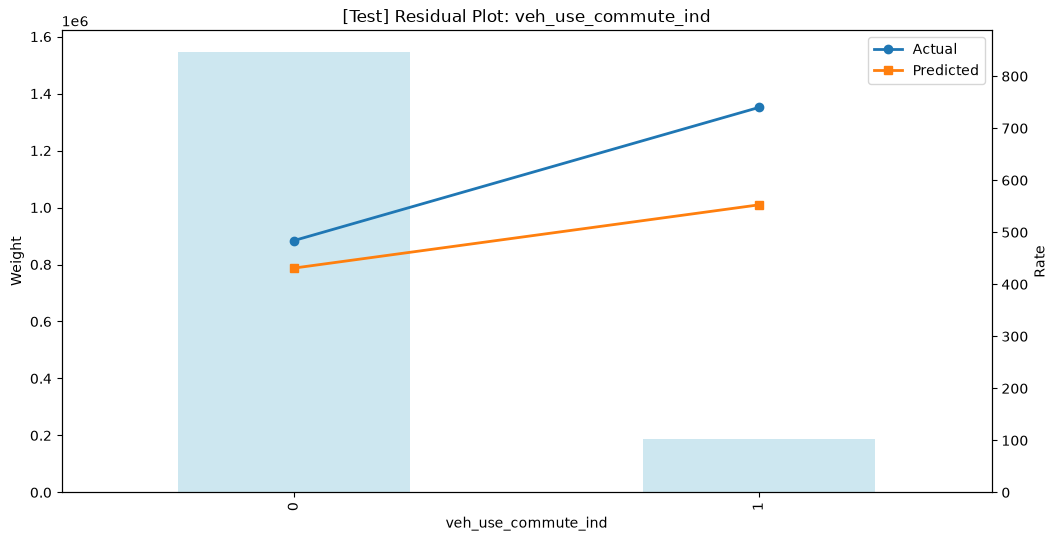

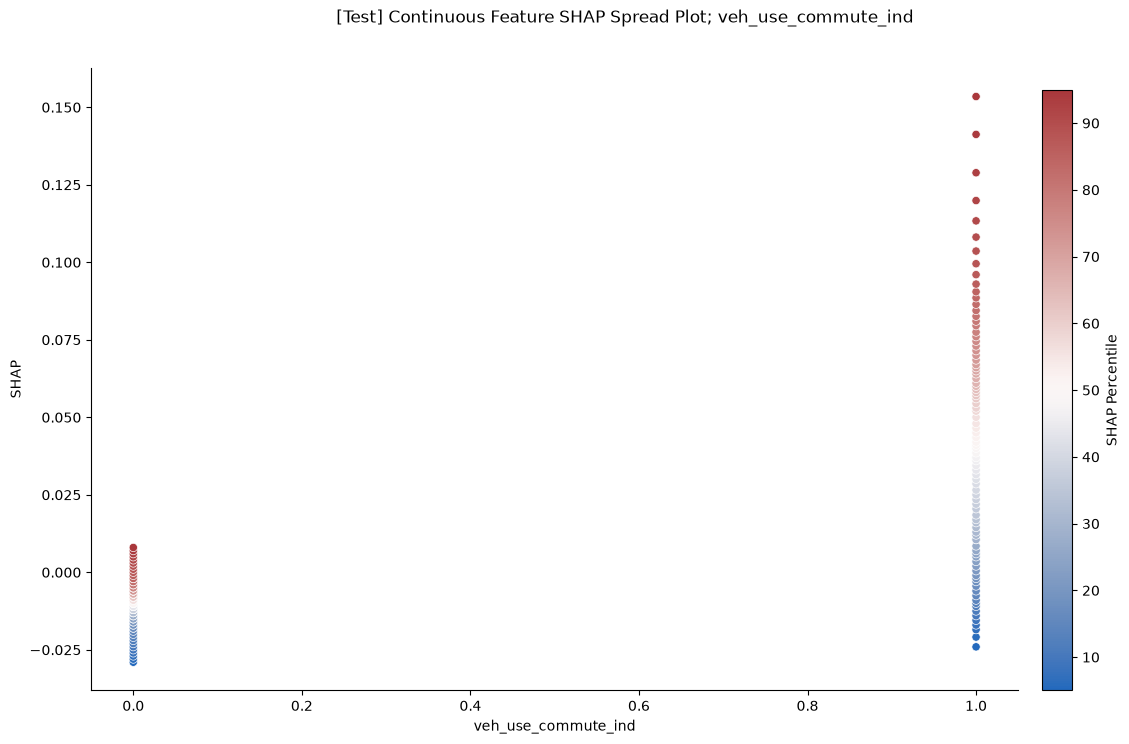


FEATURE: vc_drive_type_rwd_ind


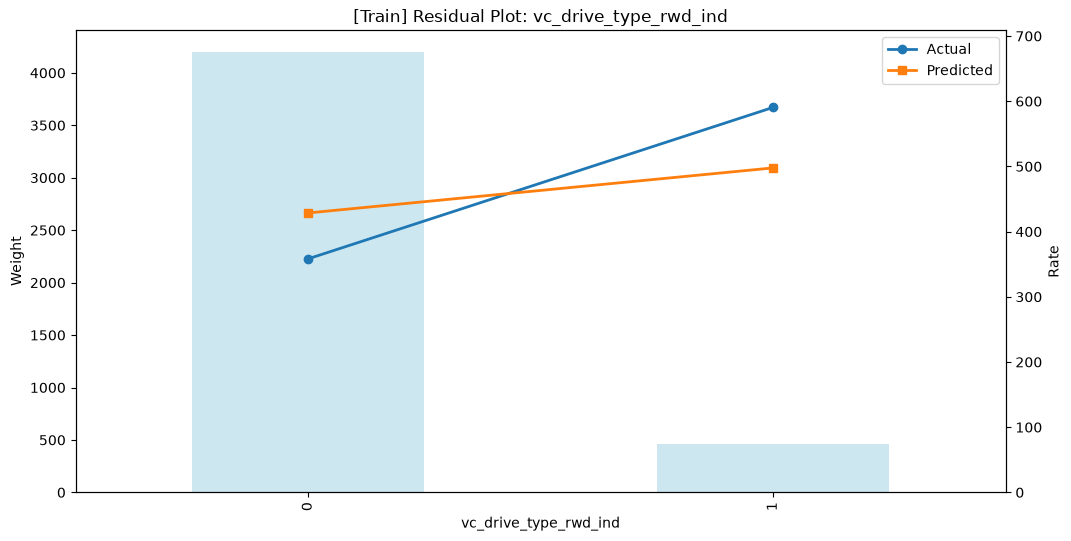

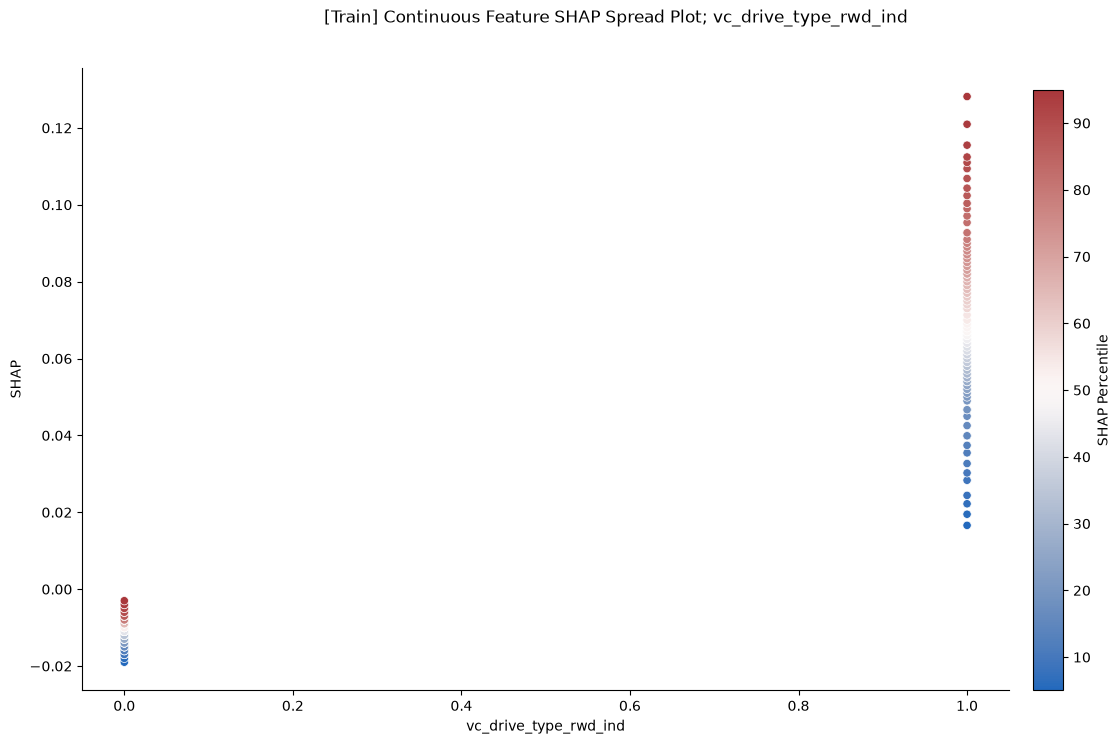

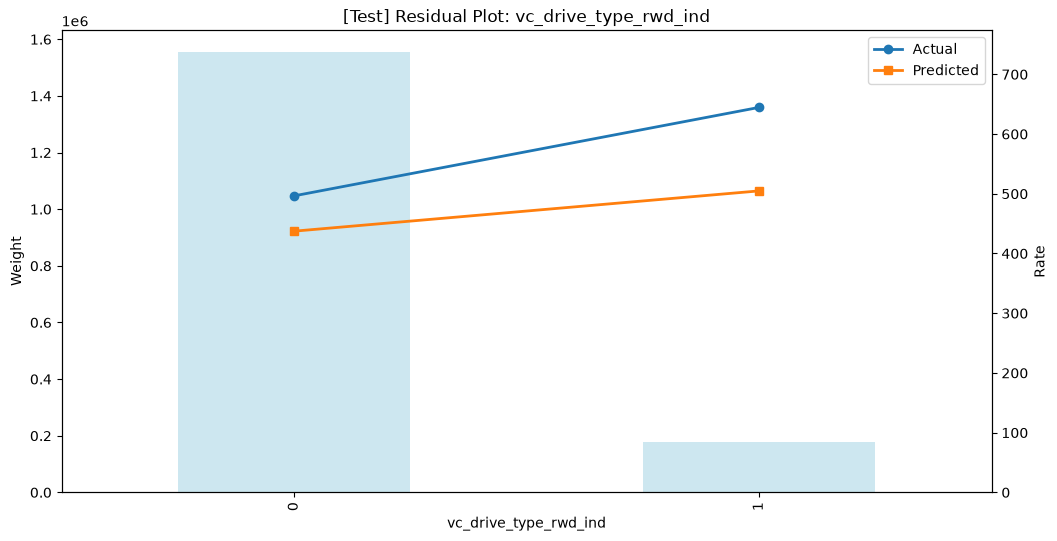

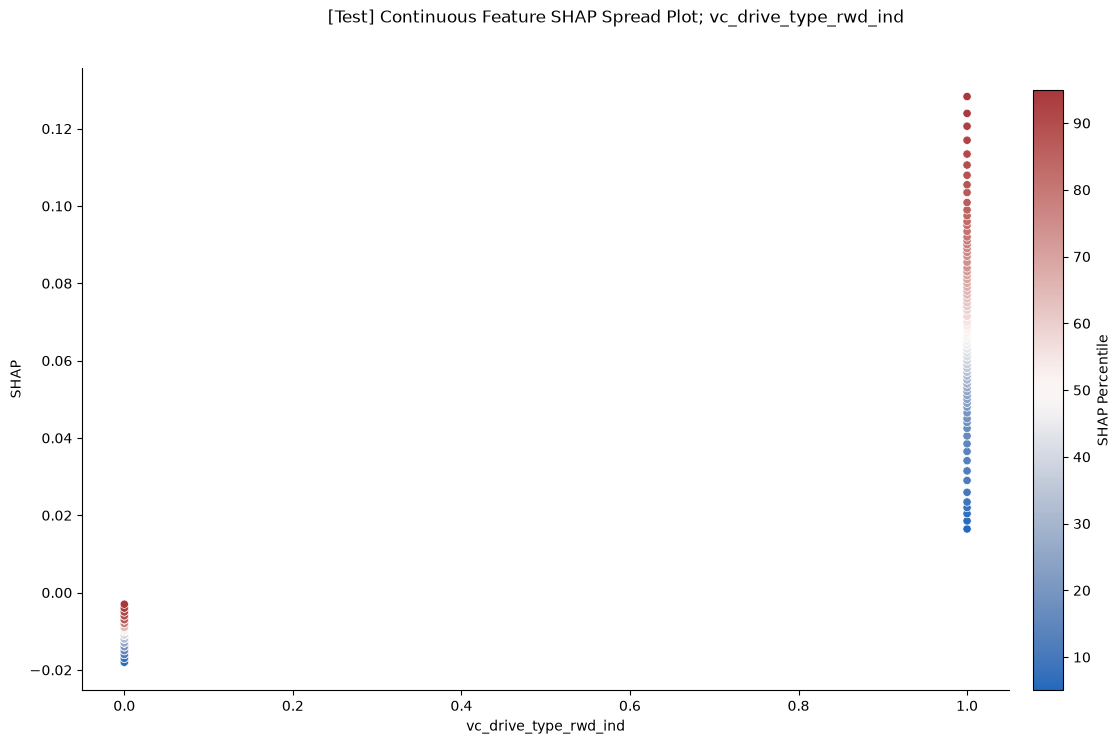


FEATURE: vc_driver_attention_system_raw


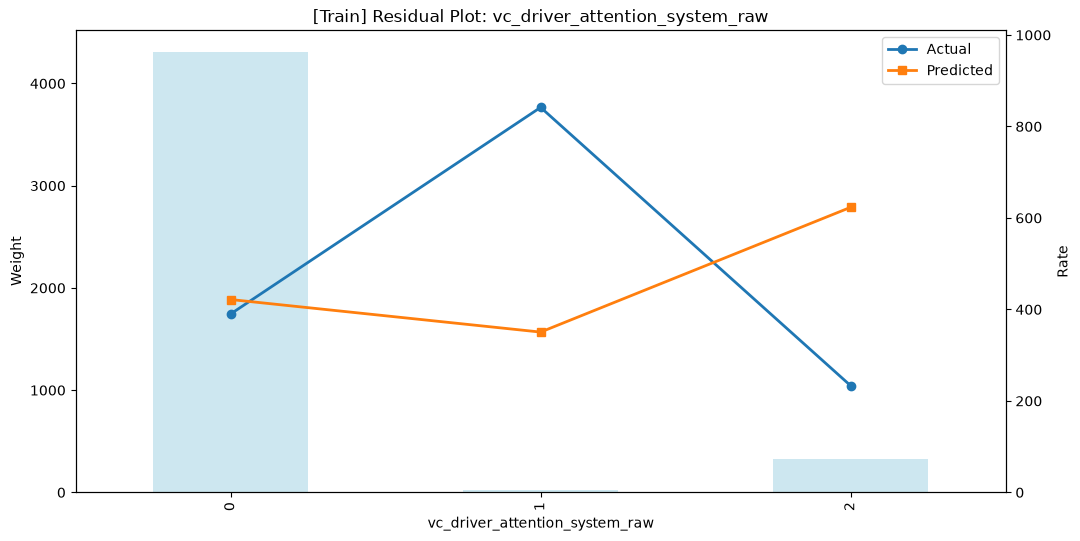

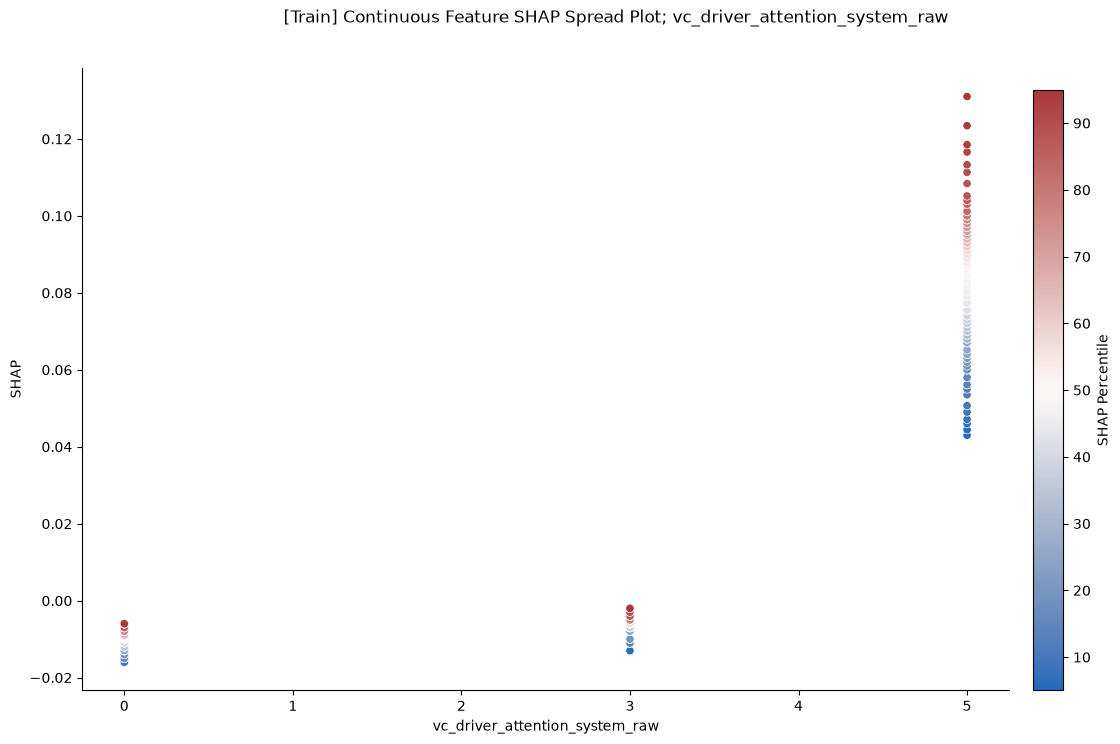

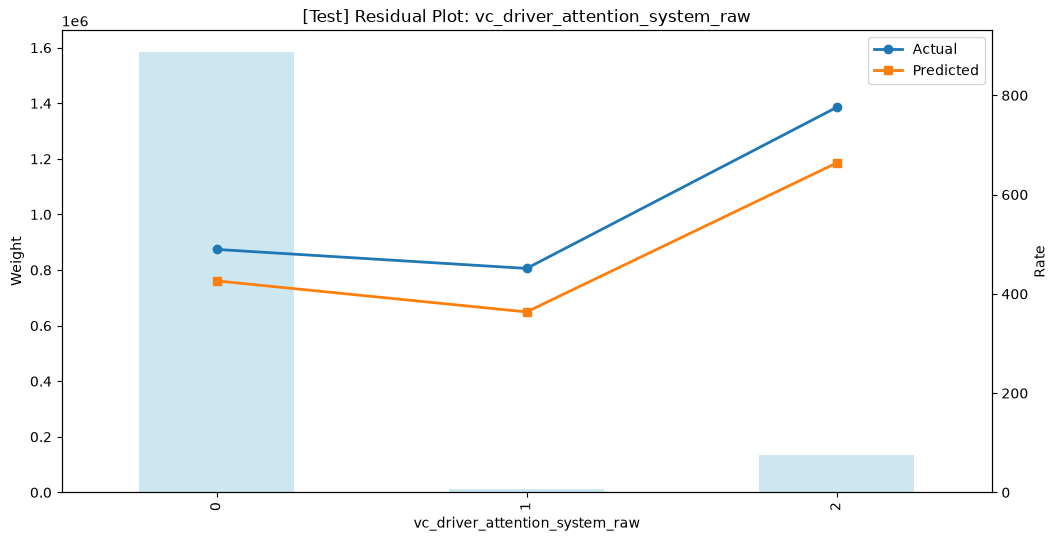

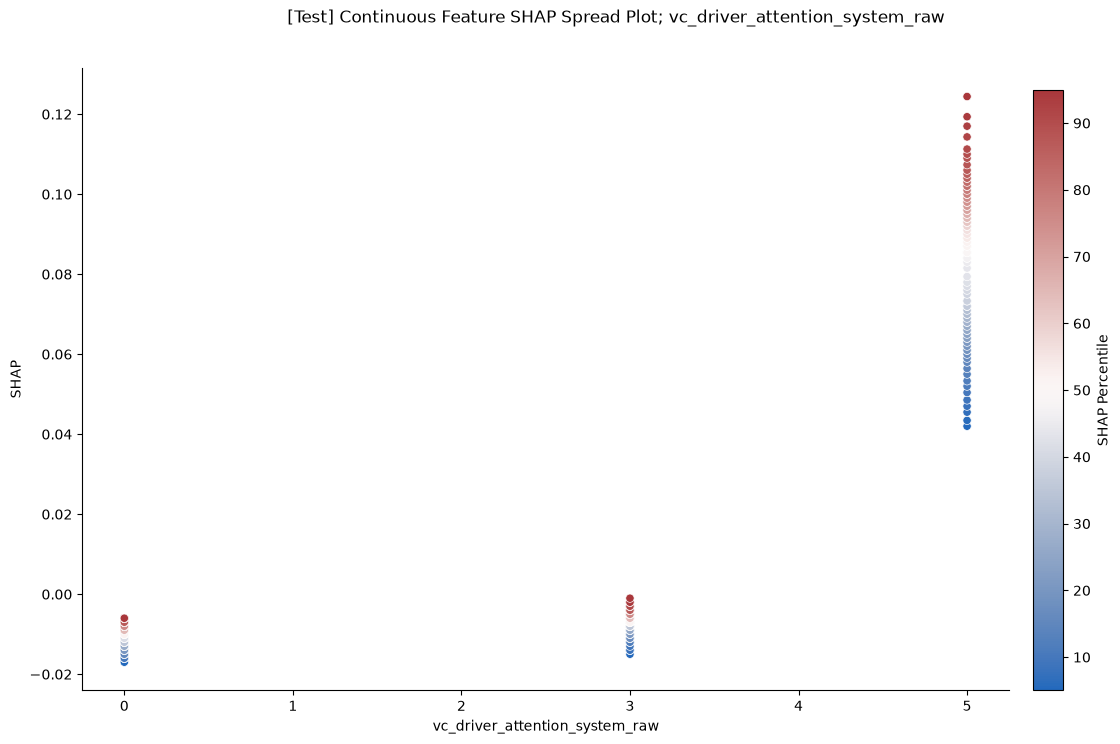


FEATURE: vc_passive_collision_avoidance_system_raw


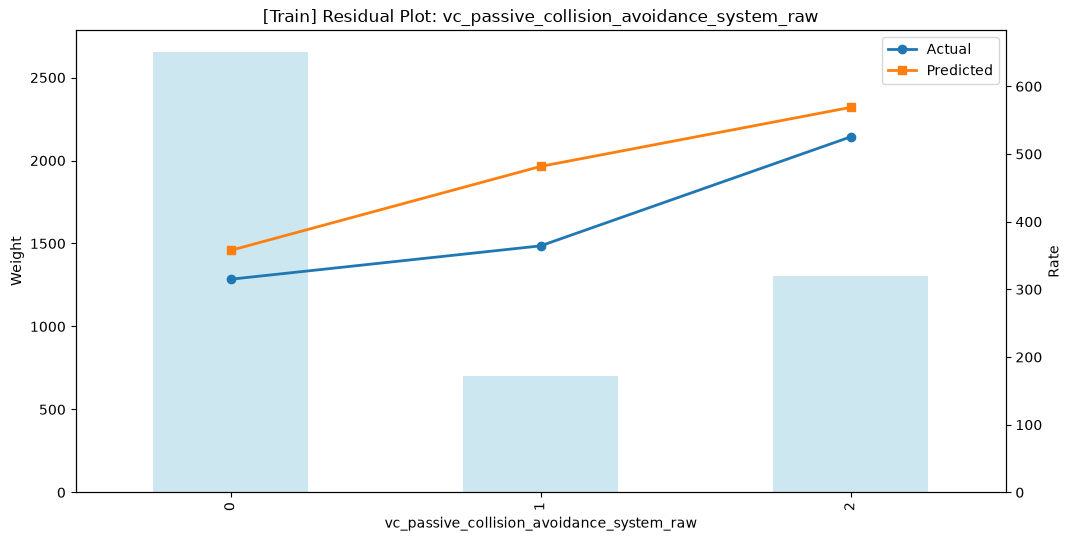

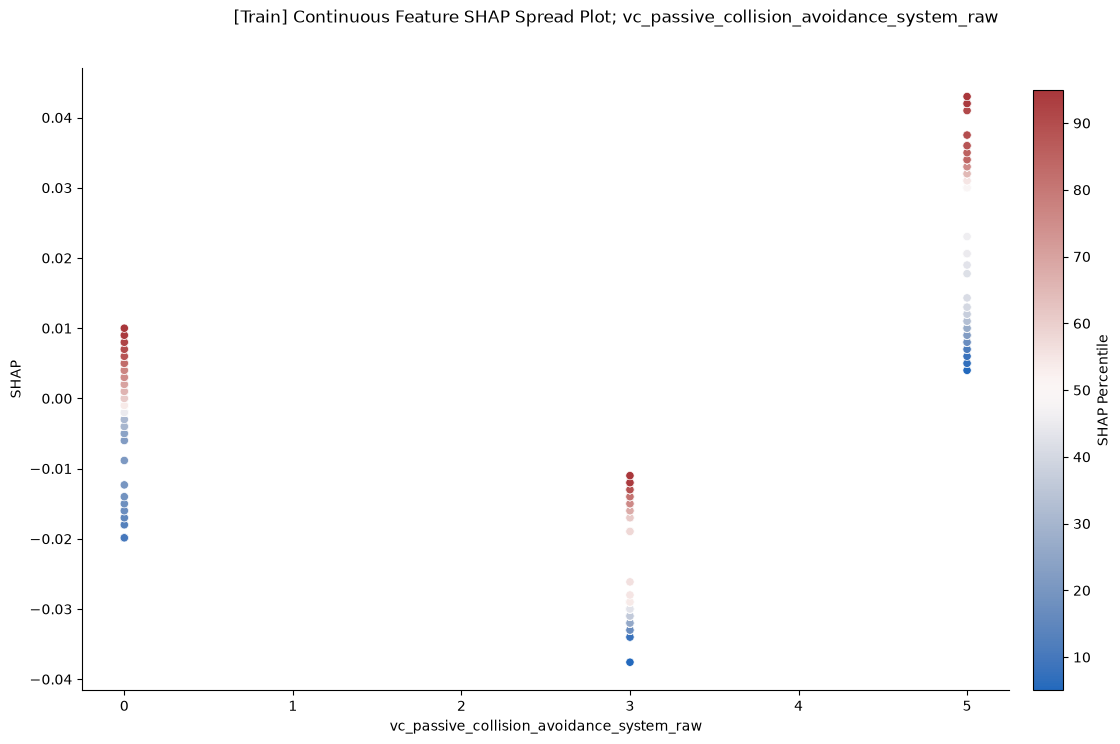

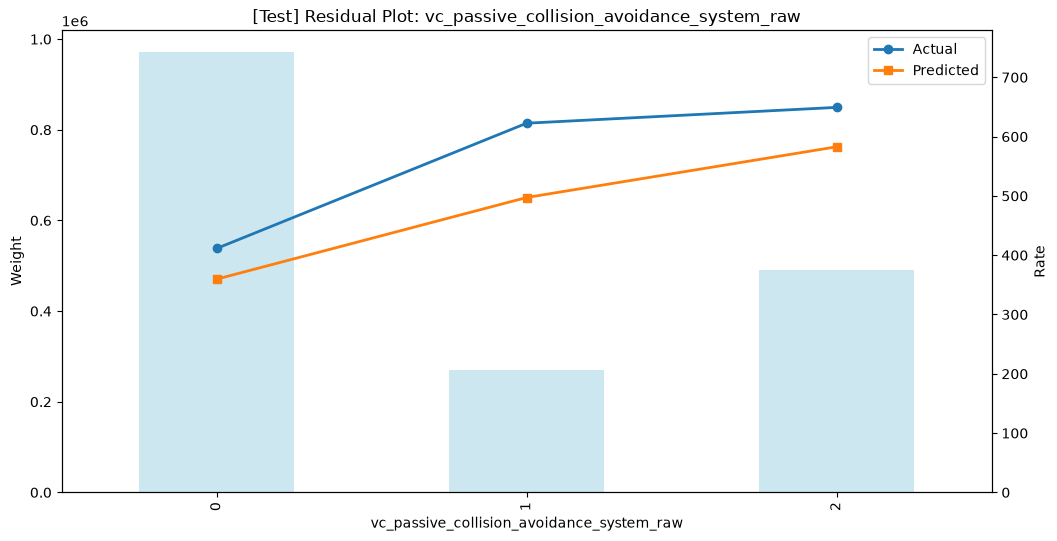

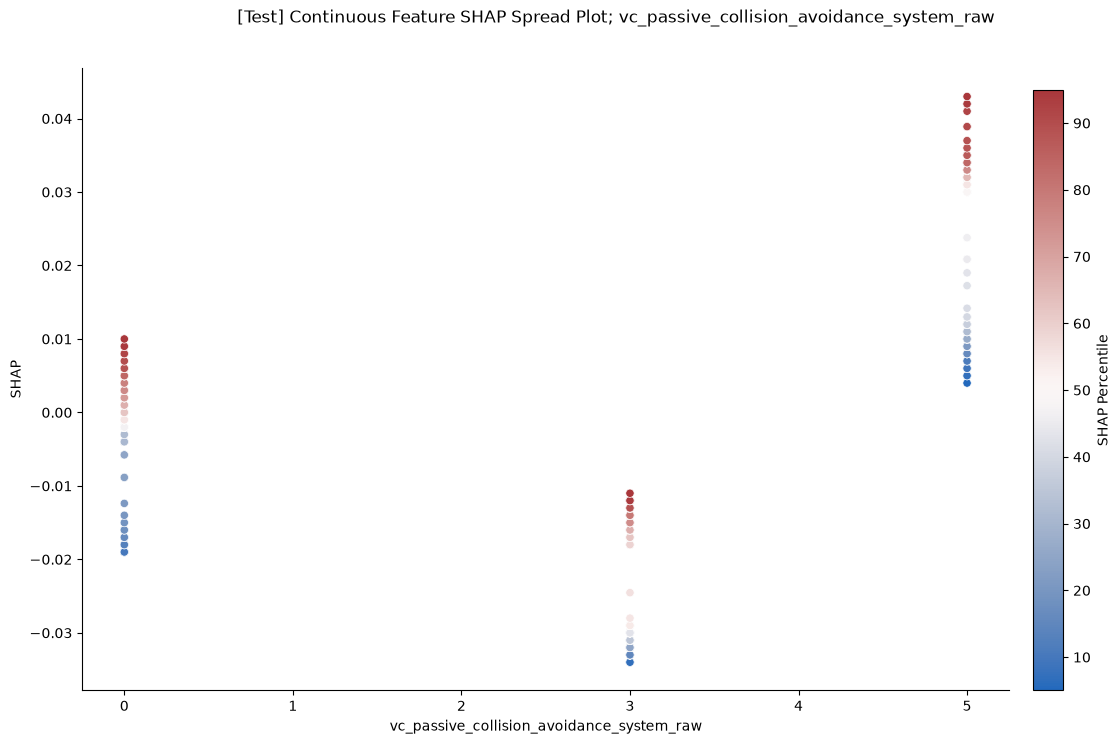


FEATURE: vc_blind_spot_warning_raw


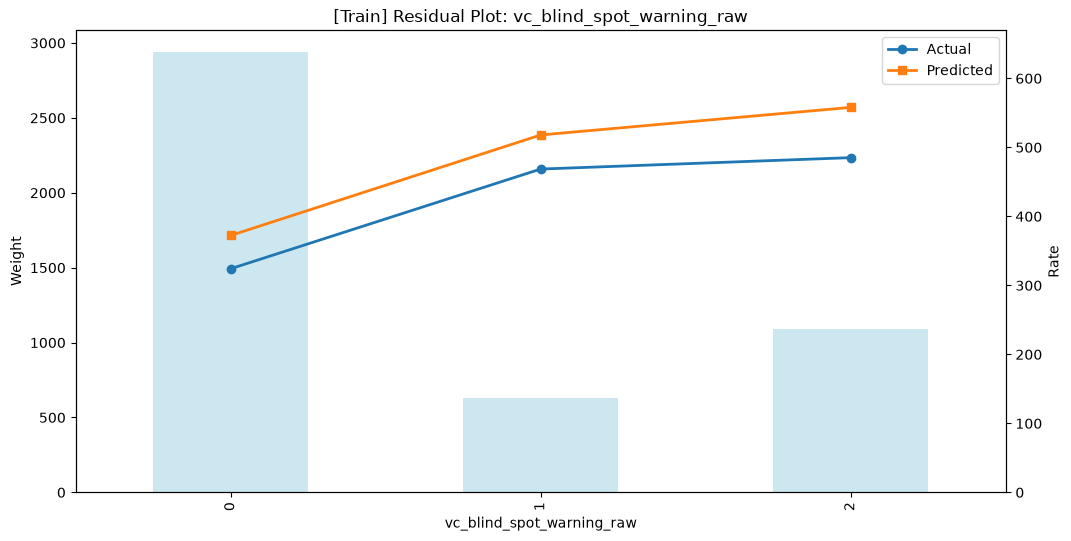

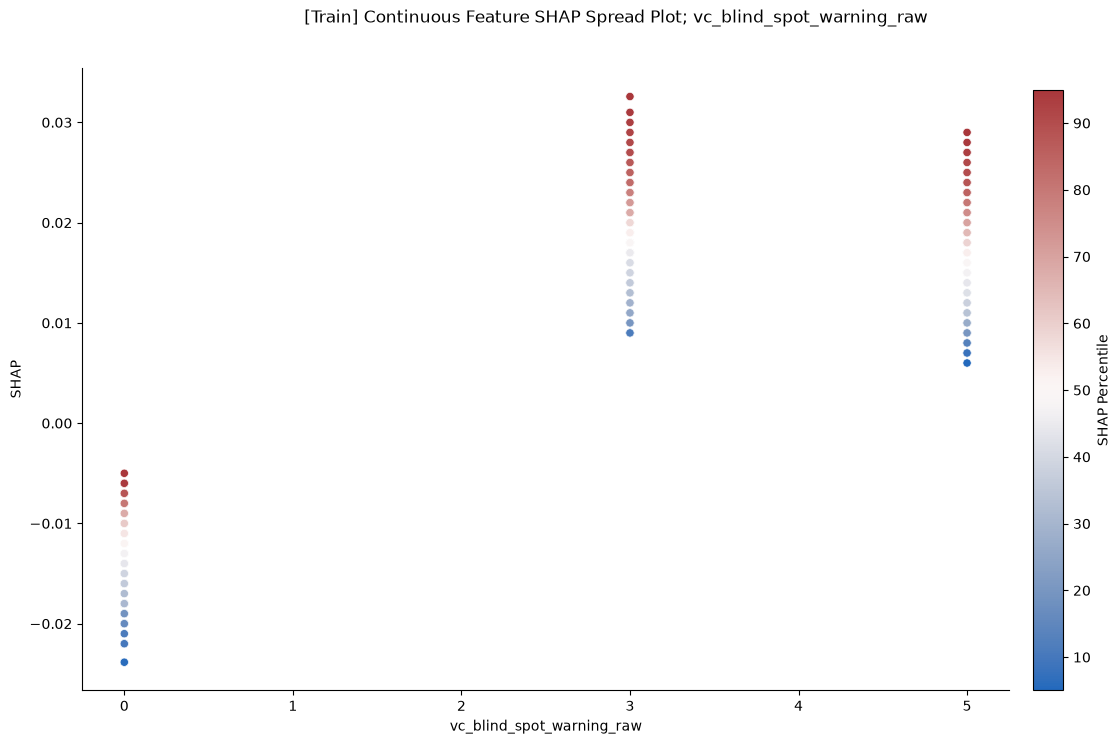

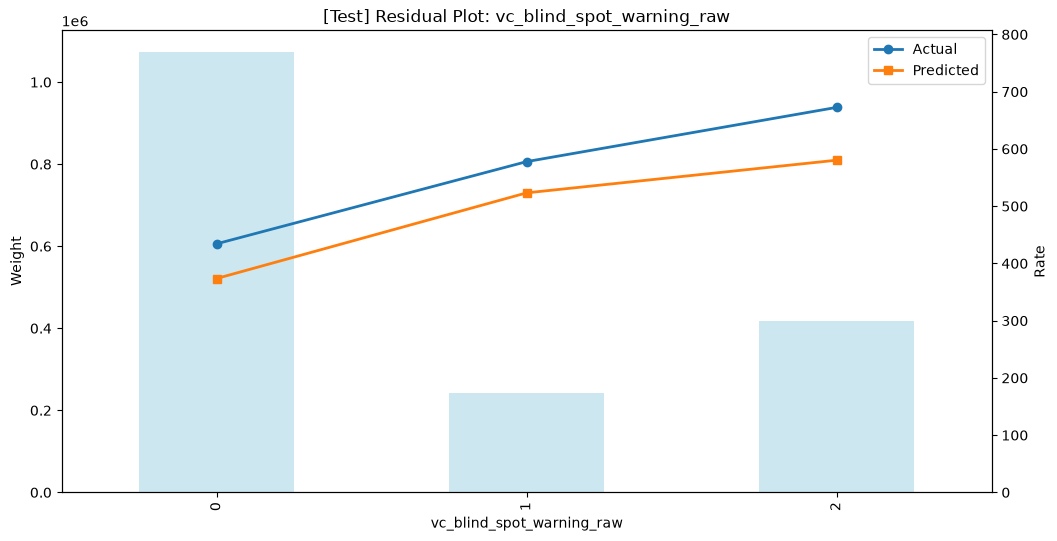

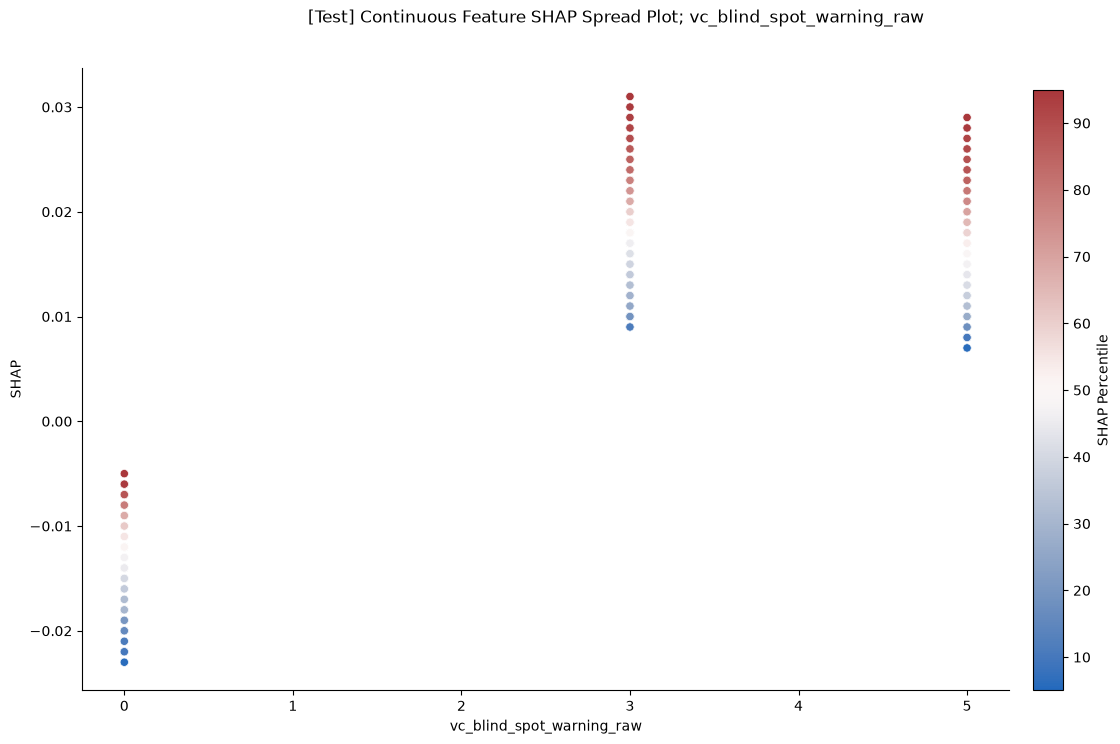


FEATURE: vc_fog_lights_raw


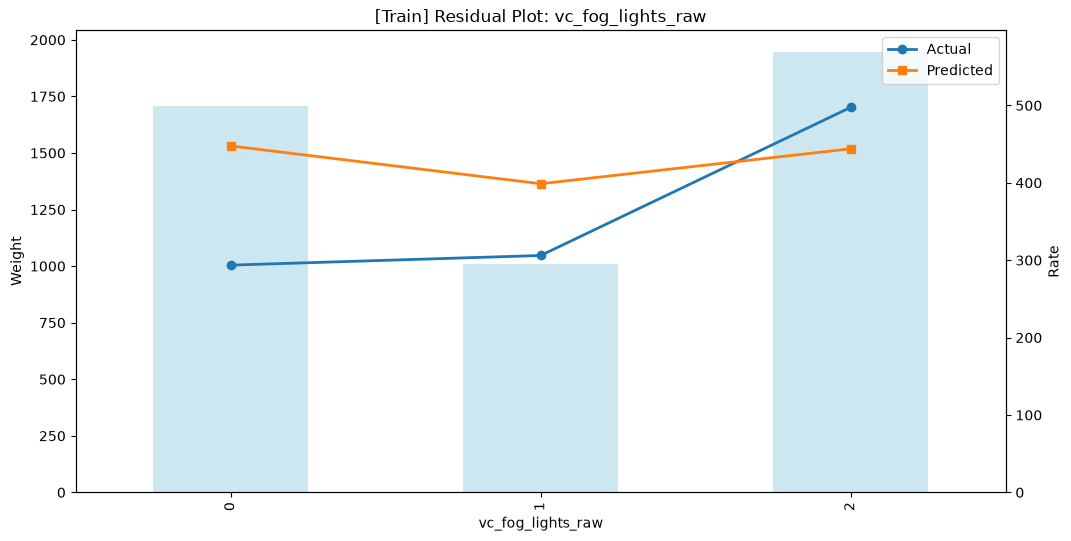

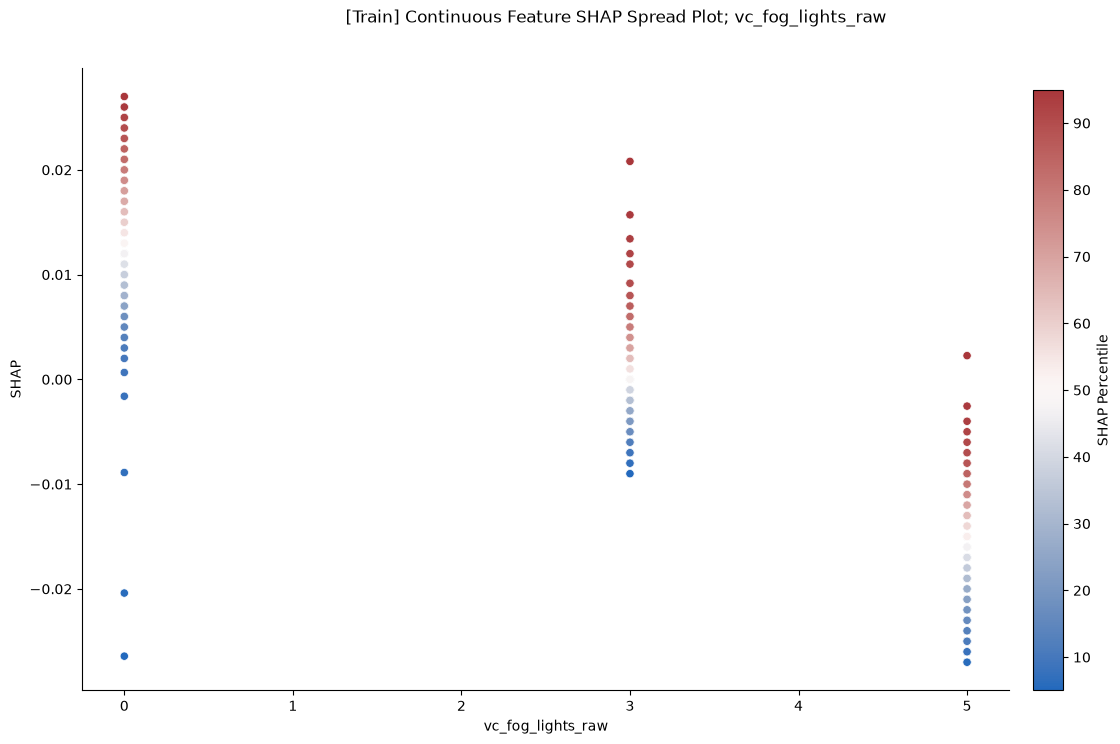

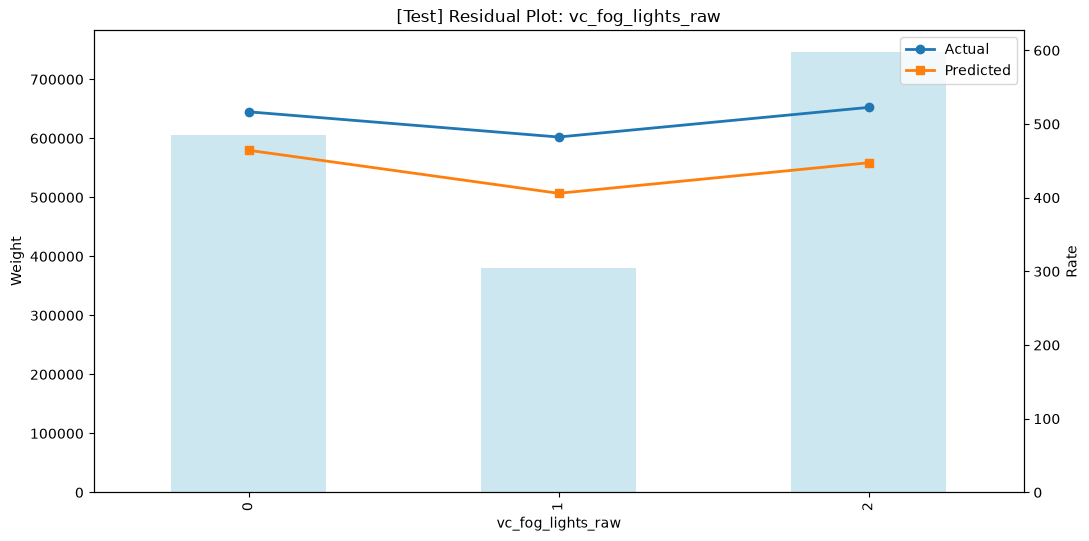

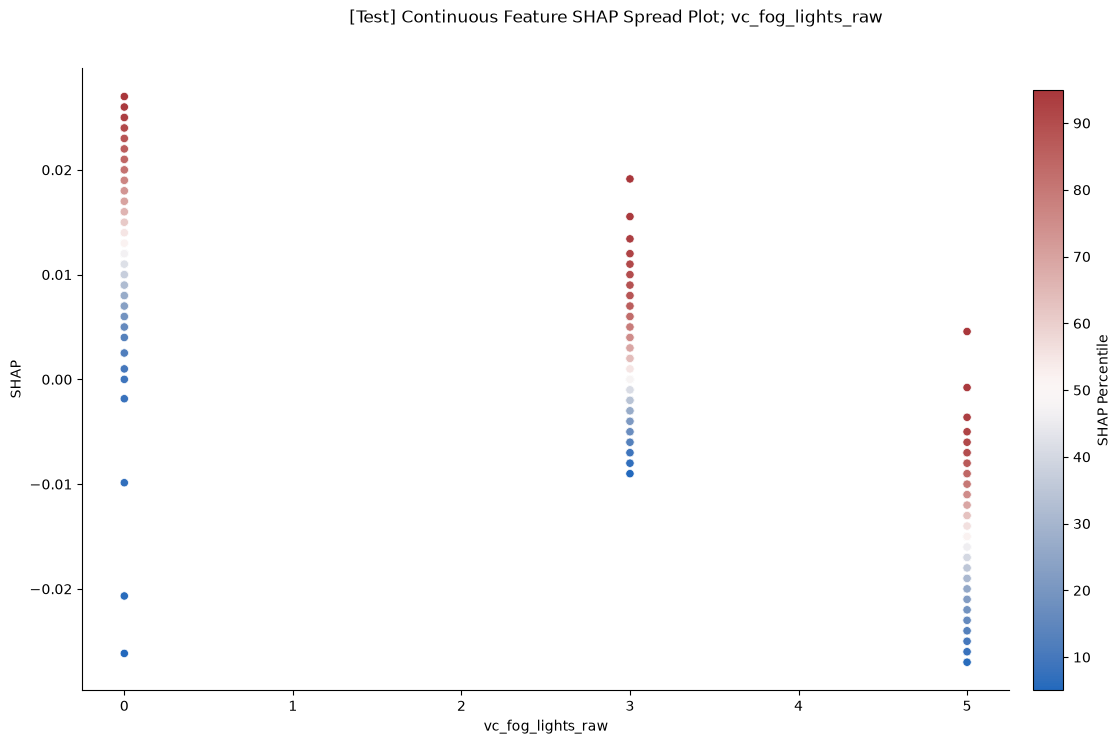


FEATURE: vc_navigation_touchscreen_raw


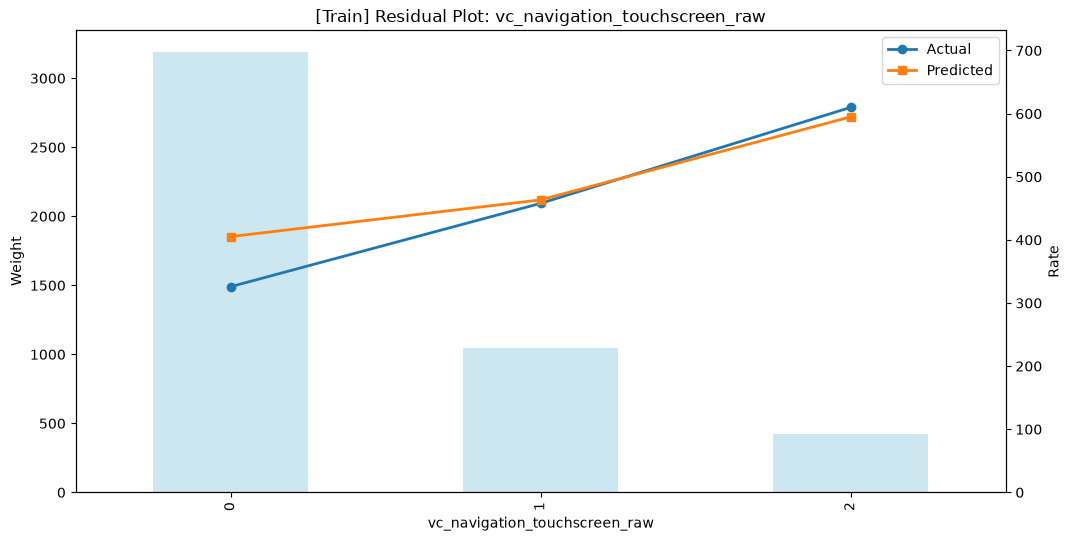

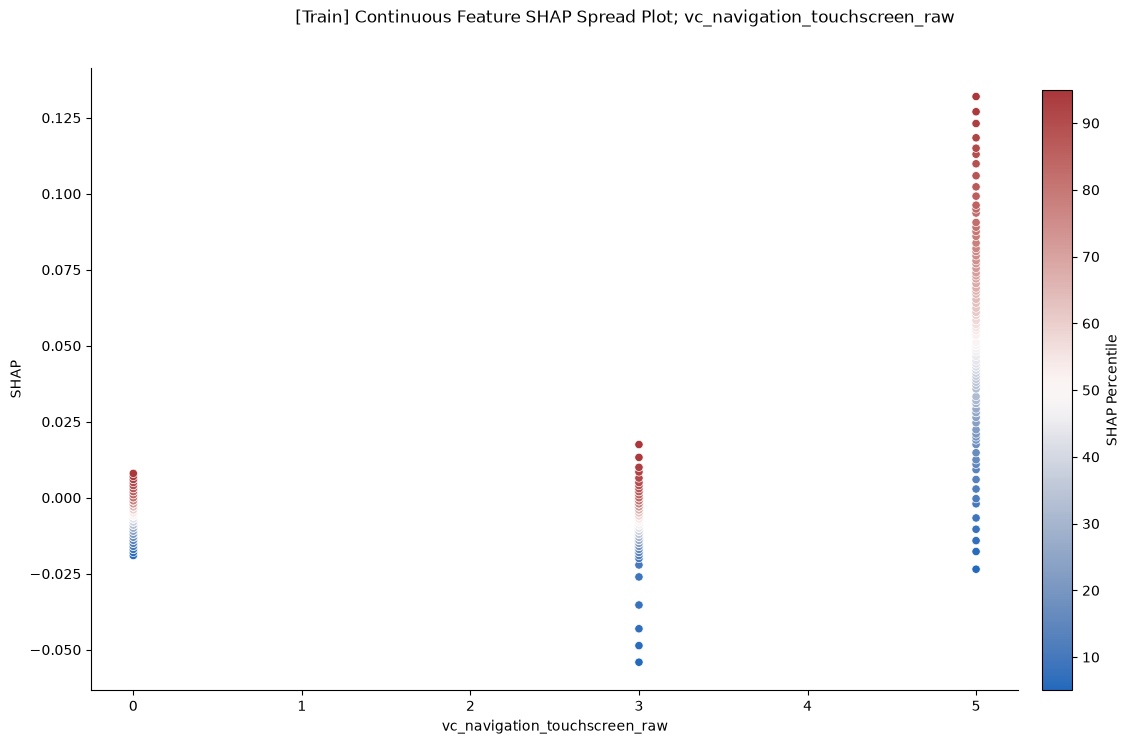

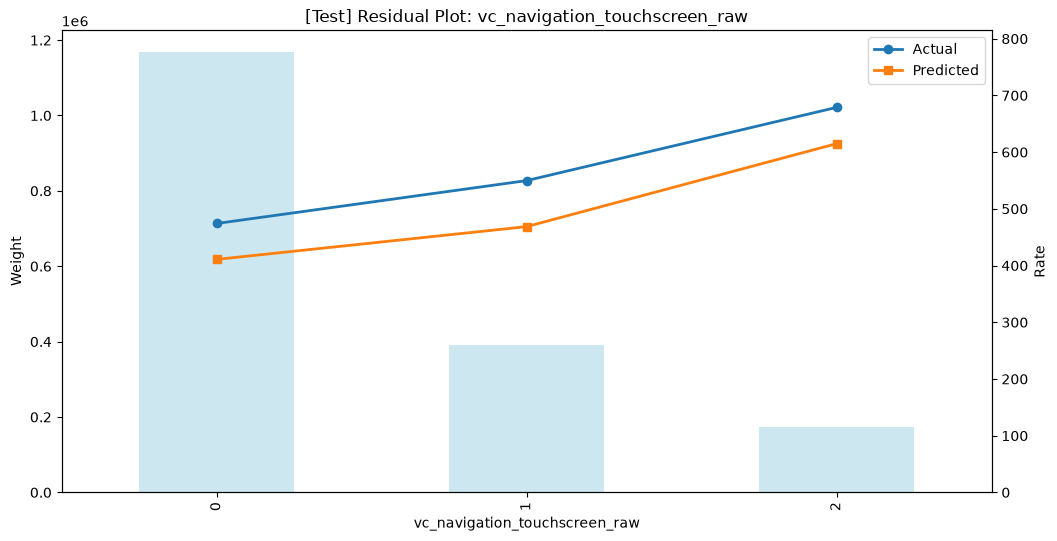

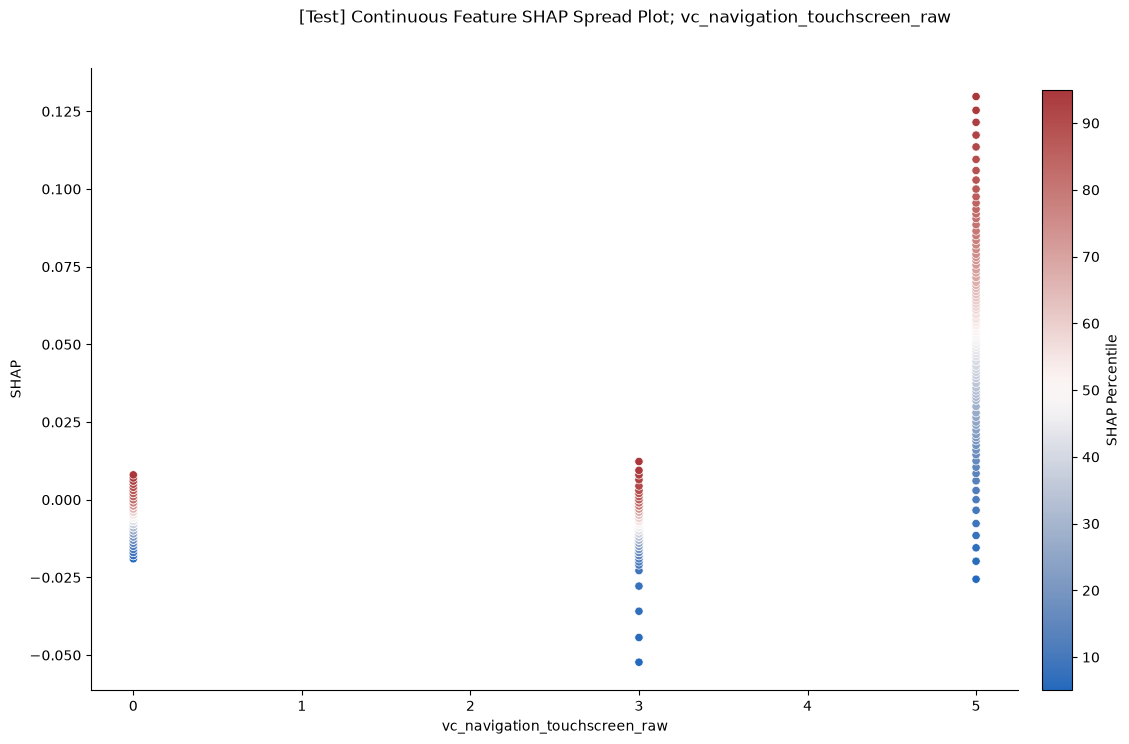


FEATURE: vc_remote_engine_start_raw


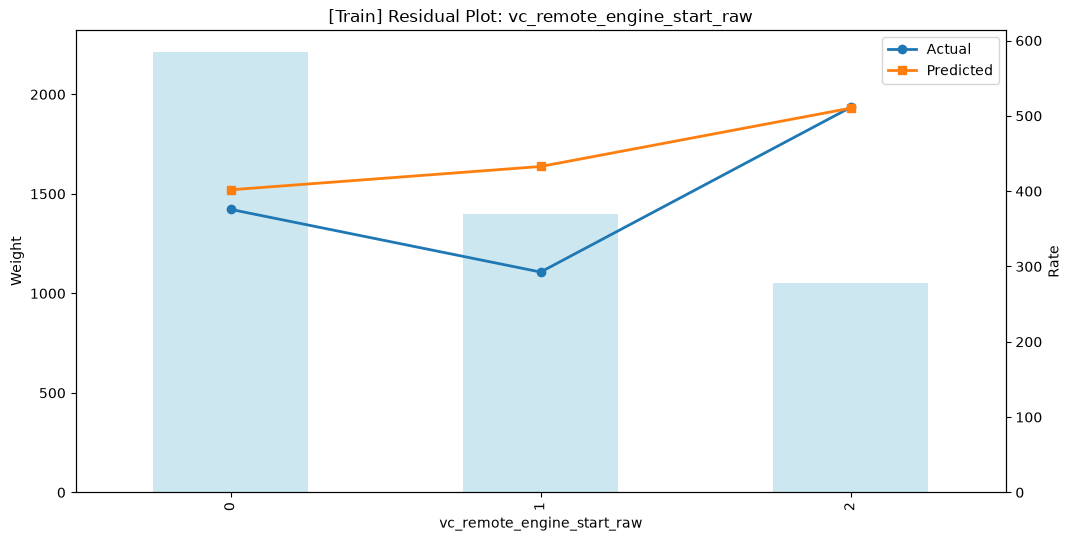

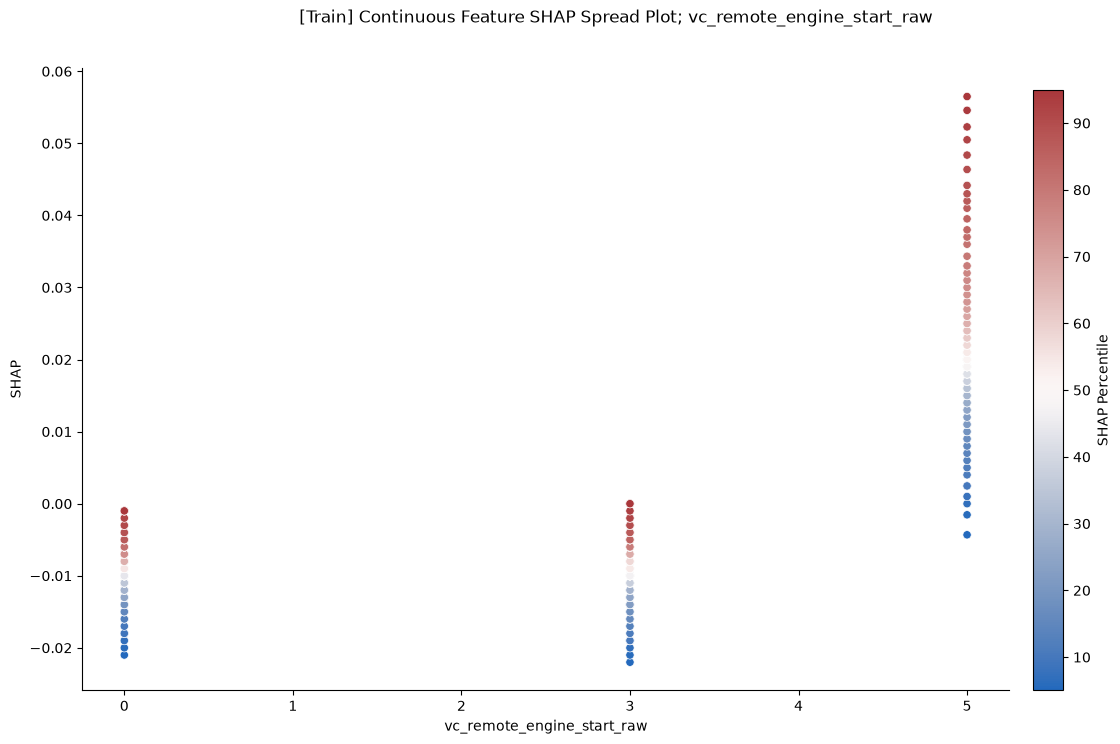

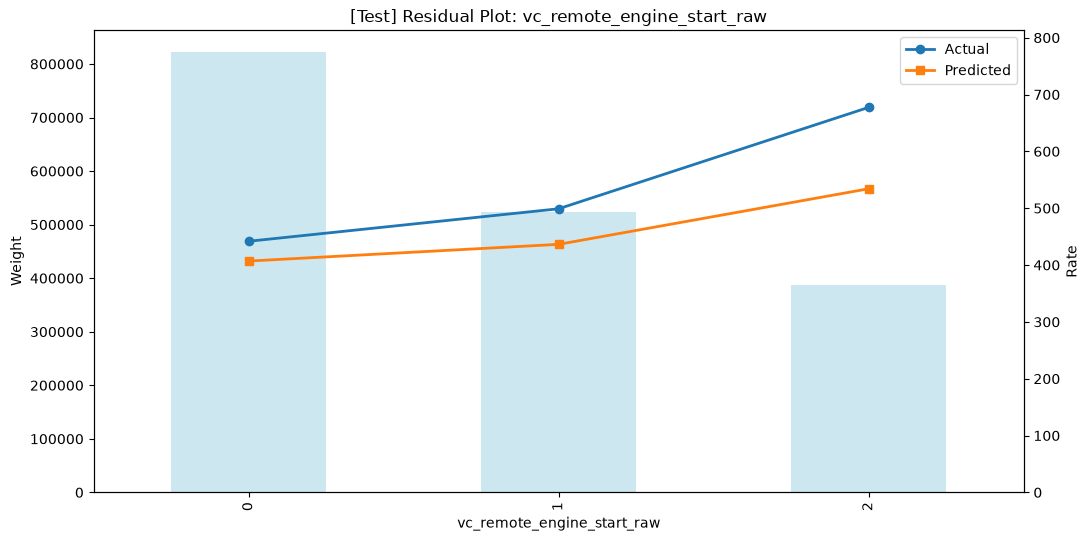

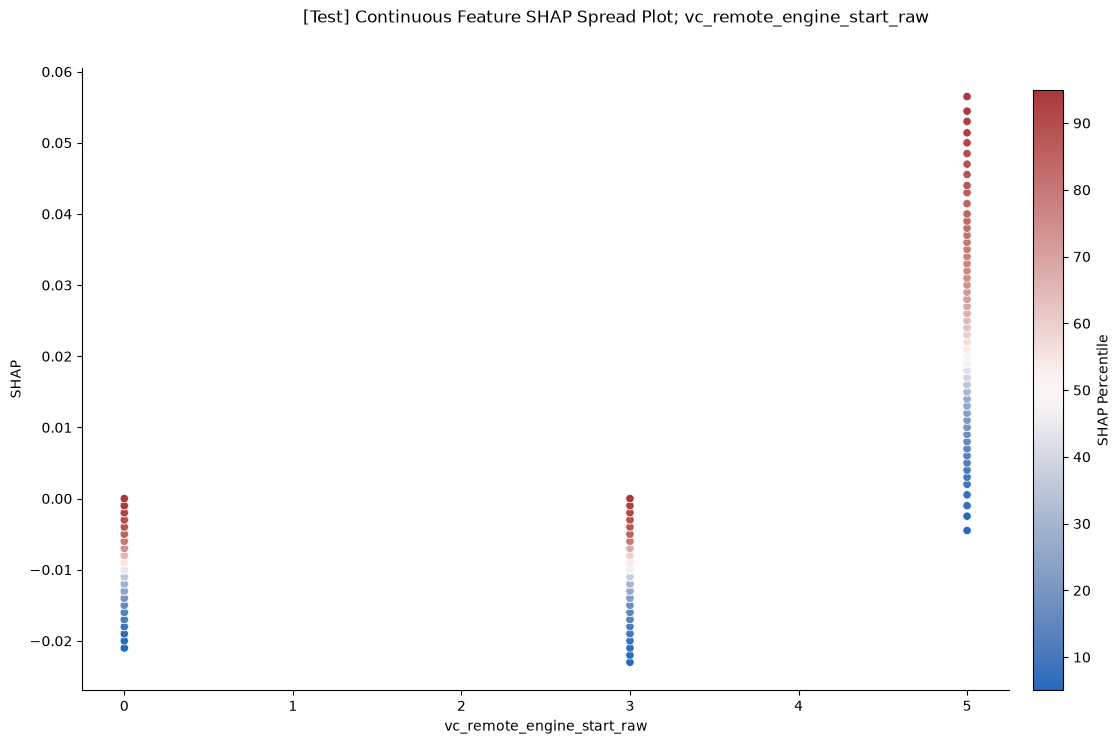


FEATURE: vc_sunroof_raw


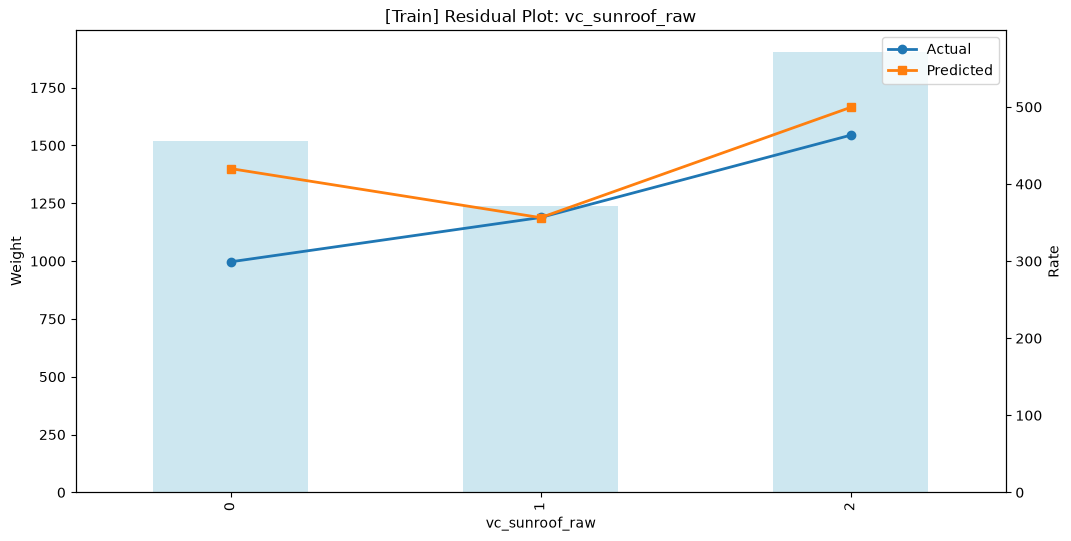

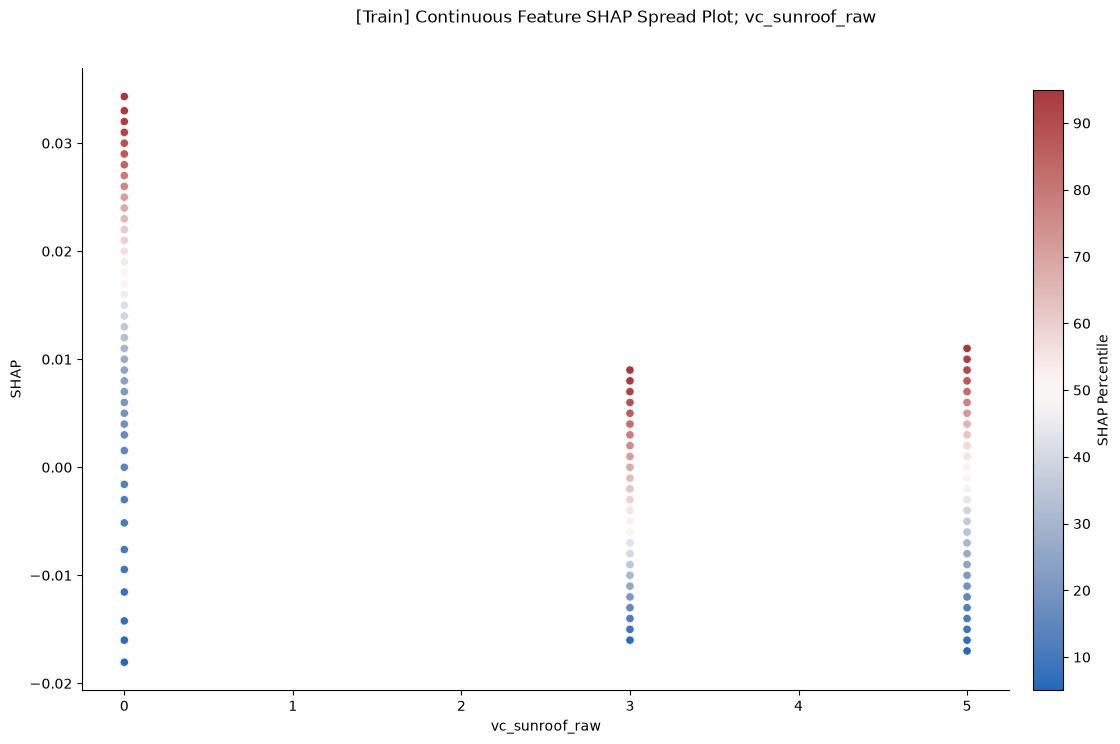

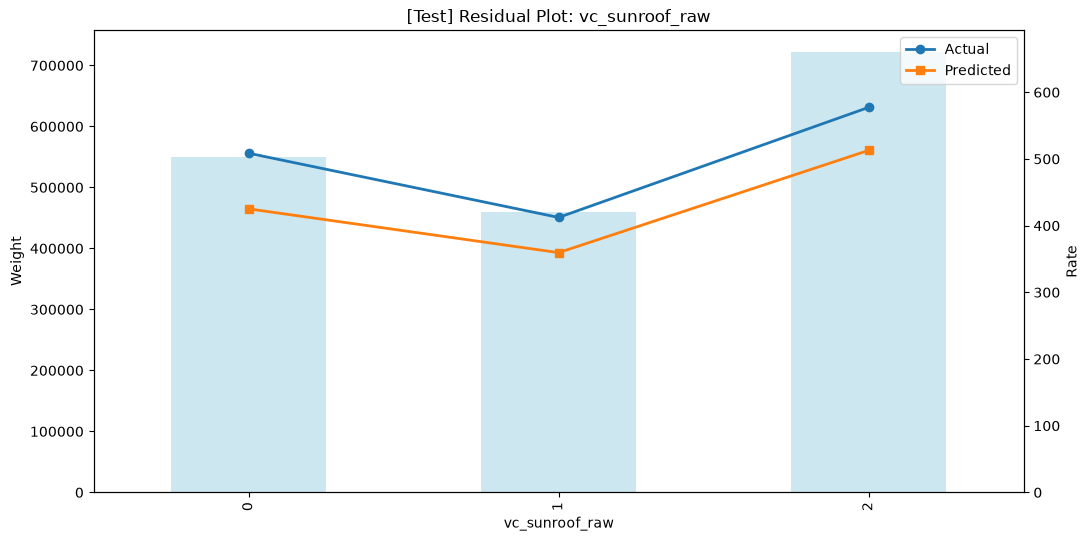

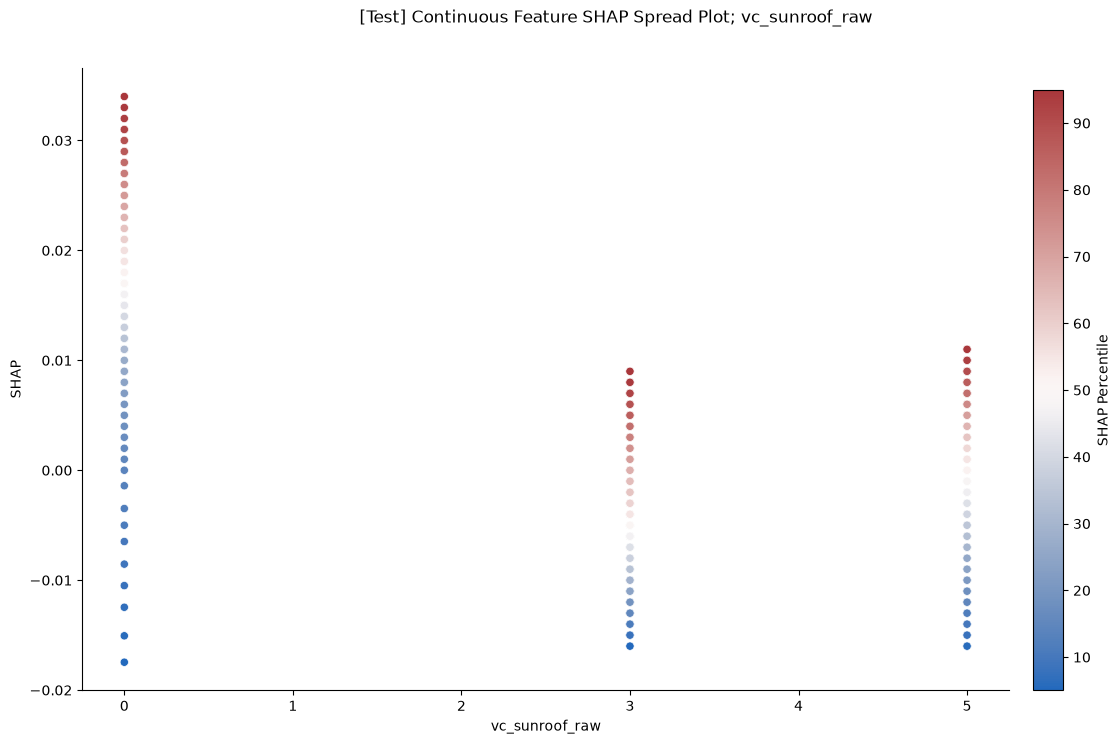


FEATURE: vc_doors_raw


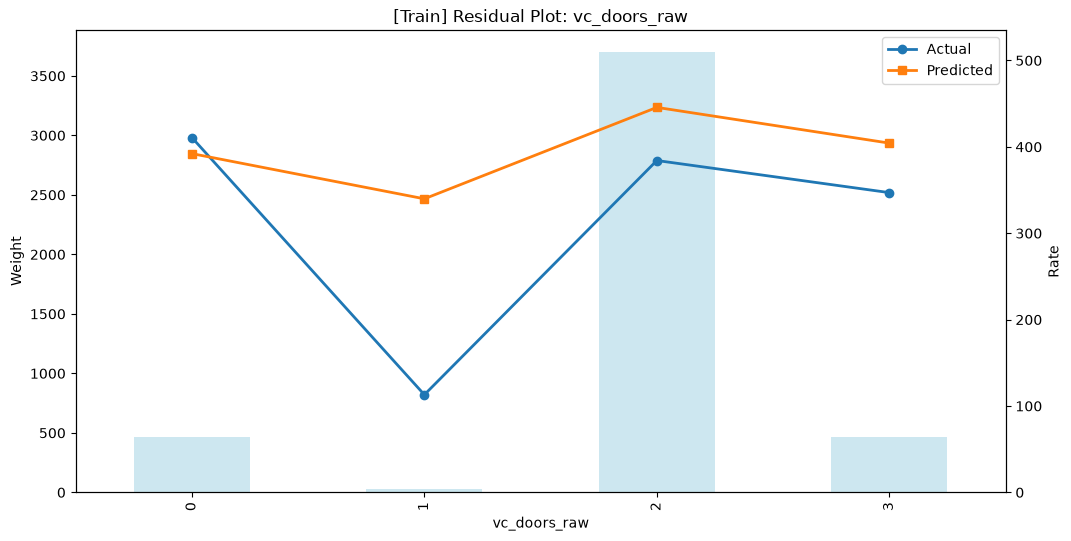

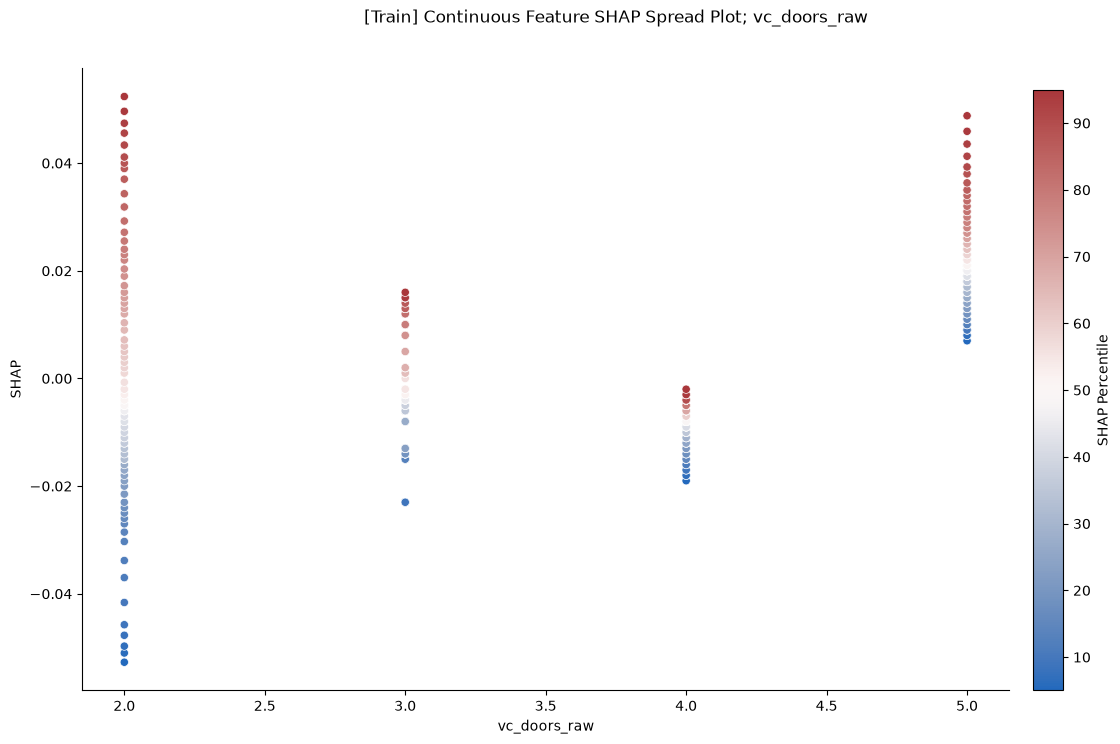

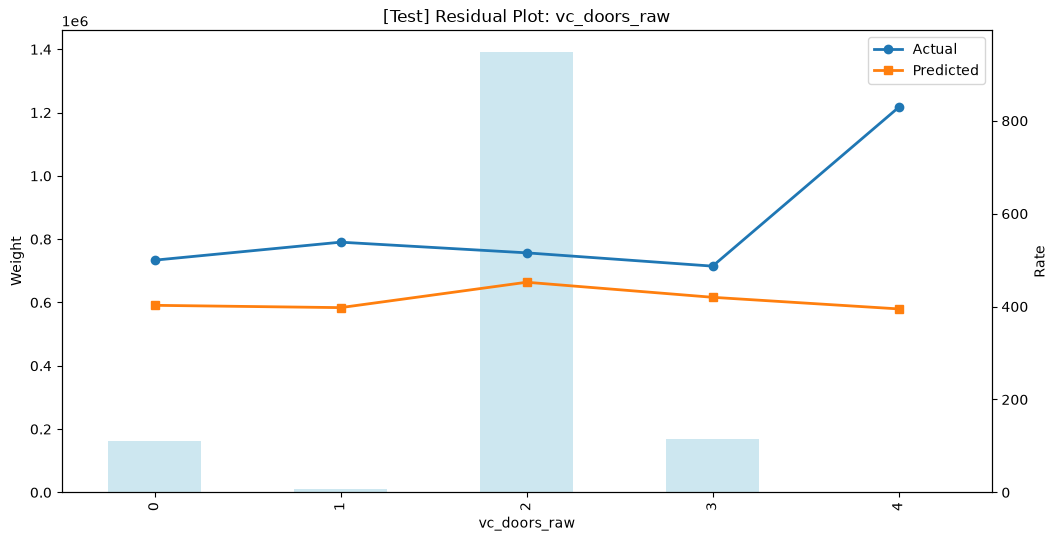

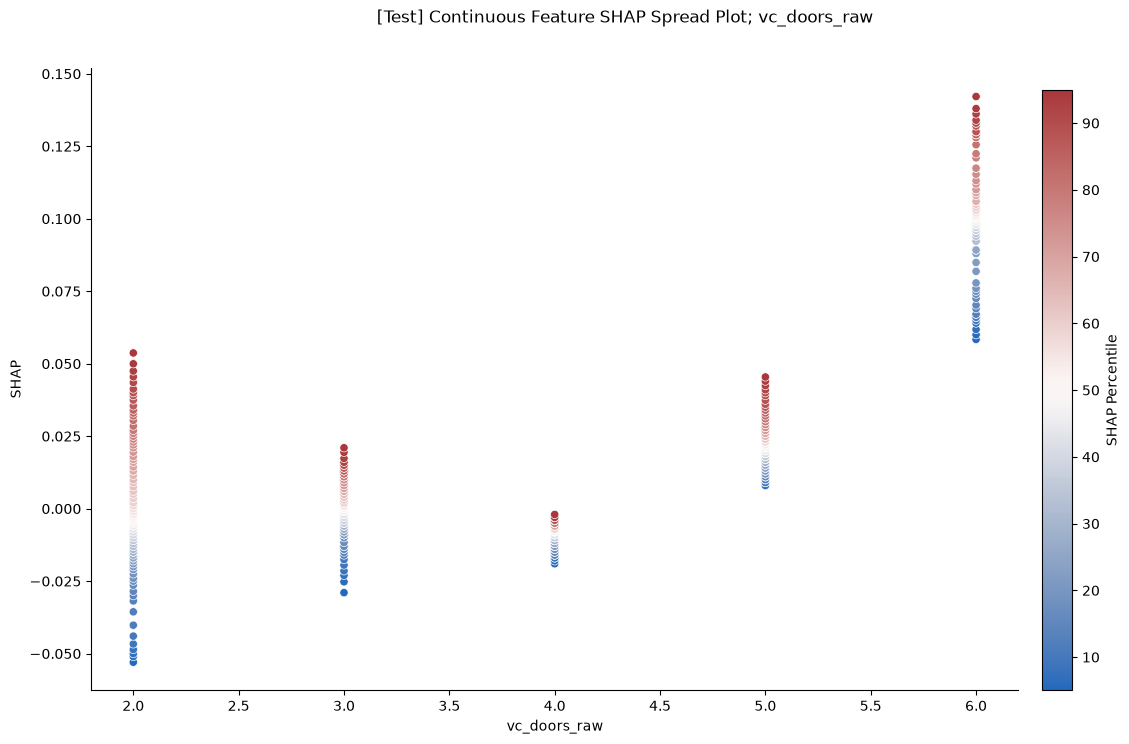


[OK] Displayed 158 plots


In [13]:
from IPython.display import Image, display
print("\n" + "="*60)
print("DISPLAYING ALL PLOTS")
print("="*60)
for f in features:
    if f not in plots_by_feature or not plots_by_feature[f]:
        continue
    print("\n" + "="*60)
    print(f"FEATURE: {f}")
    print("="*60)
    for plot_path in plots_by_feature[f]:
        if Path(plot_path).exists():
            display(Image(filename=plot_path))
        else:
            print(f"WARNING: {plot_path} not found")
print(f"\n[OK] Displayed {sum(len(v) for v in plots_by_feature.values())} plots")

In [14]:
summary["features"] = features
summary["top_n"] = top_n
summary_file = f"{output_base}/results/07_analysis_summary.yaml"
with open(summary_file, "w") as f:
    yaml.dump(summary, f)
print(f"\nSummary: {summary_file}")


Summary: output/car_coll/v1/results/07_analysis_summary.yaml


In [15]:
print("\n" + "#"*40)
print("# STAGE 07: COMPLETE")
print("#"*40)
print(f"Plots: {summary['plots']}")


########################################
# STAGE 07: COMPLETE
########################################
Plots: 158
